資料分布

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) 讀取資料
# =========================
file_path = r"C:/Users/User/Desktop/LC analysis/LC analysis.csv"
# df = pd.read_csv(file_path, encoding="utf-8-sig")

# 如果讀取失敗，可以改用：
# df = pd.read_csv(file_path, encoding="big5")
df = pd.read_csv(file_path, encoding="cp950")

# =========================
# 2) 確認欄位
# =========================
print(df.columns.tolist())

# =========================
# 3) 取出「死亡」變數
# =========================
y = pd.to_numeric(df["死亡"], errors="coerce")

print("死亡缺失值數量：", y.isna().sum())
print("死亡有效樣本數：", y.notna().sum())

# 基本統計量
print(y.describe())

# 額外看分位數
print(
    y.quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1])
)

['年份', '鄉鎮', '該鄉鎮總人口數 (人數)', '小於18歲人口數 (人數)', 'Lead_water', 'Lead_soil', 'PM2.5 (ug/m3)', 'Income_regular (百萬元)', '每百萬人病床數 (床/萬人)', '平均年齡（歲）', '性別(男)', '平均BMI  (kg/m2)', '平均日常體能狀態（分）', '加權 CCI ', '死亡', '癌症期別_1', '癌症期別_2', '仍吸菸', '仍喝酒', '癌症組織類型_1', '癌症組織類型_2', '癌症組織類型_3', '癌症組織類型_4', 'OP指標日期前', 'RT指標日期後', '併用藥物1', '併用藥物2', '併用藥物3', '併用藥物4', '併用藥物5', '併用藥物6', '併用藥物7', '併用藥物8', '併用藥物9', '併用藥物10', '併用藥物11', '平均診斷到index date時間(日)', '平均健保投保金額', '醫學中心']
死亡缺失值數量： 99
死亡有效樣本數： 1297
count    1297.000000
mean        0.122469
std         0.146497
min         0.000000
25%         0.000000
50%         0.090910
75%         0.176470
max         1.000000
Name: 死亡, dtype: float64
0.00    0.000000
0.01    0.000000
0.05    0.000000
0.25    0.000000
0.50    0.090910
0.75    0.176470
0.95    0.376744
0.99    0.666670
1.00    1.000000
Name: 死亡, dtype: float64


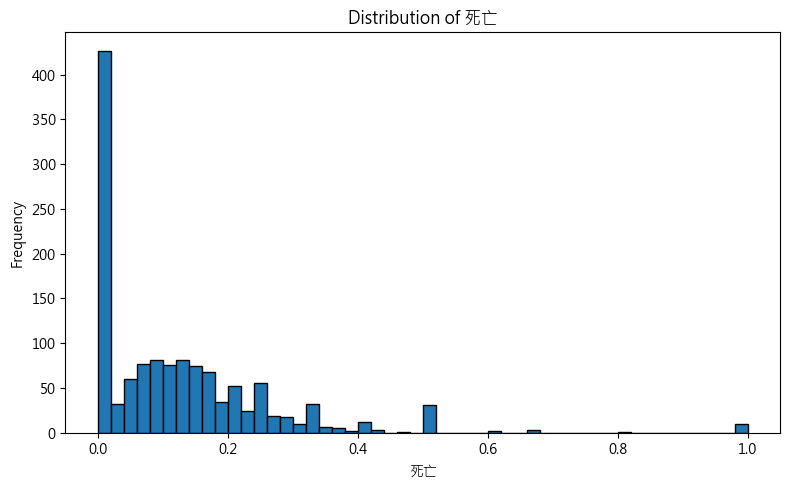

In [7]:
import matplotlib.pyplot as plt
import matplotlib

# =========================
# 設定中文字體
# =========================
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]  # 微軟正黑體
plt.rcParams["axes.unicode_minus"] = False               # 避免負號顯示錯誤
# =========================
# 4) 死亡變數直方圖
# =========================
plt.figure(figsize=(8, 5))
plt.hist(y.dropna(), bins=50, edgecolor="black")
plt.xlabel("死亡")
plt.ylabel("Frequency")
plt.title("Distribution of 死亡")
plt.tight_layout()
plt.show()

2015 年資料筆數：336
count    336.000000
mean       0.084429
std        0.093545
min        0.000000
25%        0.000000
50%        0.066670
75%        0.125000
max        0.500000
Name: 死亡, dtype: float64
----------------------------------------


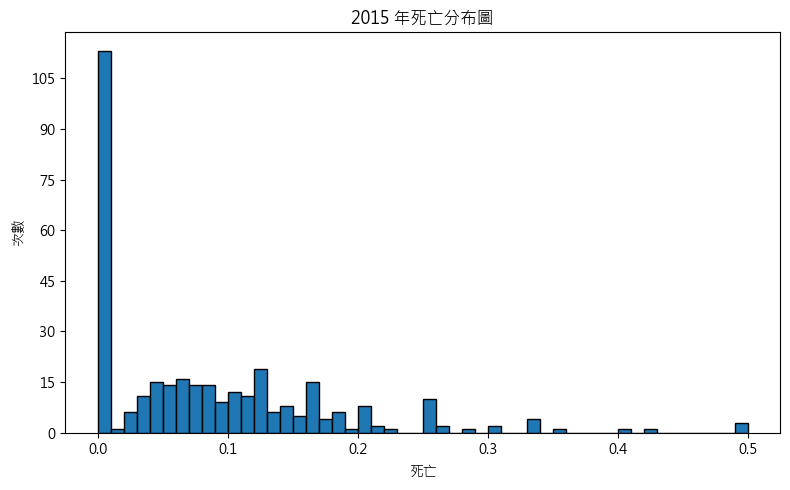

2016 年資料筆數：330
count    330.000000
mean       0.102079
std        0.130080
min        0.000000
25%        0.000000
50%        0.073700
75%        0.151140
max        1.000000
Name: 死亡, dtype: float64
----------------------------------------


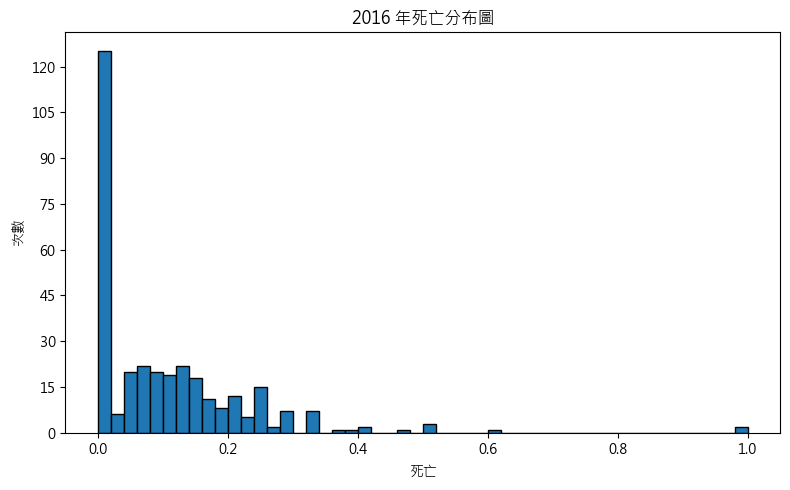

2017 年資料筆數：318
count    318.00000
mean       0.12553
std        0.14374
min        0.00000
25%        0.00000
50%        0.10000
75%        0.16667
max        1.00000
Name: 死亡, dtype: float64
----------------------------------------


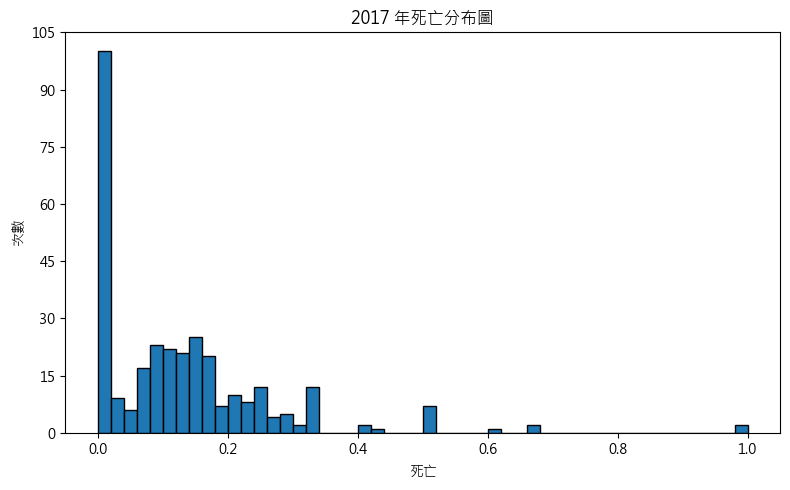

2018 年資料筆數：313
count    313.000000
mean       0.181693
std        0.188122
min        0.000000
25%        0.000000
50%        0.153850
75%        0.250000
max        1.000000
Name: 死亡, dtype: float64
----------------------------------------


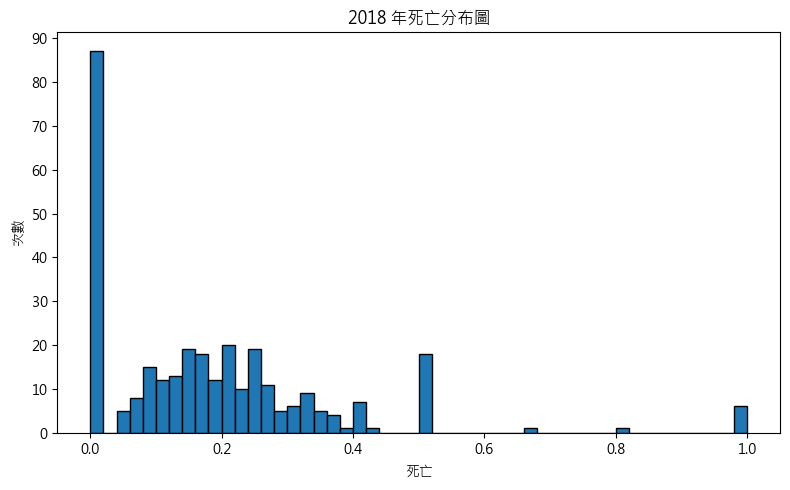

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os

# =========================
# 0) 中文字體設定
# =========================
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 1) 讀取資料
# =========================
file_path = r"C:/Users/User/Desktop/LC analysis/LC analysis.csv"
df = pd.read_csv(file_path, encoding="cp950")

# 如果你用 Excel 檔，改成下面這行：
# file_path = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料變換可數型.xlsx"
# df = pd.read_excel(file_path)

# =========================
# 2) 整理年份
# =========================
year_try = pd.to_datetime(df["年份"], errors="coerce")

# if year_try.notna().sum() > 0:
#     df["年度"] = year_try.dt.year
# else:
#     df["年度"] = pd.to_numeric(df["年份"], errors="coerce")

# =========================
# 3) 整理死亡變數
# =========================
df["死亡"] = pd.to_numeric(df["死亡"], errors="coerce")

# # =========================
# # 4) 建立輸出資料夾
# # =========================
# output_dir = r"C:/Users/User/Desktop/LC analysis/死亡分布圖"
# os.makedirs(output_dir, exist_ok=True)

# =========================
# 5) 分別輸出 2015、2016、2017、2018 四張圖
# =========================
years = [2015, 2016, 2017, 2018]

for year in years:
    y_data = df.loc[df["年份"] == year, "死亡"].dropna()

    print(f"{year} 年資料筆數：{len(y_data)}")
    print(y_data.describe())
    print("-" * 40)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        y_data,
        bins=50,
        density=False,        # 重要：y 軸顯示次數
        edgecolor="black"
    )

    ax.set_xlabel("死亡")
    ax.set_ylabel("次數")
    ax.set_title(f"{year} 年死亡分布圖")

    # 重要：次數從 0 開始，不允許負值
    ax.set_ylim(bottom=0)

    # 重要：y 軸刻度顯示整數
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()

    # save_path = os.path.join(output_dir, f"{year}死亡分布圖.png")
    # plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os

# =========================
# 0) 中文字體設定
# =========================
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]  # 可改 DFKai-SB
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 1) 讀取資料
# =========================
file_path = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料變換可數型.xlsx"
df = pd.read_excel(file_path)

# 如果你是用 CSV，改成：
# file_path = r"C:/Users/User/Desktop/LC analysis/LC analysis.csv"
# df = pd.read_csv(file_path, encoding="cp950")

# =========================
# 2) 整理年份欄位
# =========================
year_try = pd.to_datetime(df["年份"], errors="coerce")

if year_try.notna().sum() > 0:
    df["年度"] = year_try.dt.year
else:
    df["年度"] = pd.to_numeric(df["年份"], errors="coerce")

# =========================
# 3) 整理死亡_cll
# =========================
df["死亡_cll"] = pd.to_numeric(df["死亡_cll"], errors="coerce")

plot_df = df[["年度", "死亡_cll"]].dropna().copy()

# # =========================
# # 4) 設定輸出資料夾
# # =========================
# output_dir = r"C:/Users/User/Desktop/LC analysis/死亡_cll分布圖"
# os.makedirs(output_dir, exist_ok=True)

# =========================
# 5) 統一 bins，讓全分布與逐年圖可比較
# =========================
x_min = plot_df["死亡_cll"].min()
x_max = plot_df["死亡_cll"].max()

bins = np.linspace(x_min, x_max, 31)

print("死亡_cll 全資料基本統計：")
print(plot_df["死亡_cll"].describe())
print("-" * 50)

print("各年度死亡_cll 基本統計：")
print(
    plot_df.groupby("年度")["死亡_cll"]
    .agg(["count", "mean", "std", "min", "median", "max"])
)

死亡_cll 全資料基本統計：
count    1297.000000
mean       -3.492707
std         2.474201
min        -6.907255
25%        -6.907255
50%        -2.350608
75%        -1.639097
max         1.527180
Name: 死亡_cll, dtype: float64
--------------------------------------------------
各年度死亡_cll 基本統計：
      count      mean       std       min    median       max
年度                                                           
2015    336 -3.788232  2.299573 -6.907255 -2.673700 -0.366513
2016    330 -3.807847  2.486852 -6.907255 -2.569731  1.527180
2017    318 -3.407052  2.457657 -6.907255 -2.250367  1.527180
2018    313 -2.930232  2.562882 -6.907255 -1.789410  1.527180


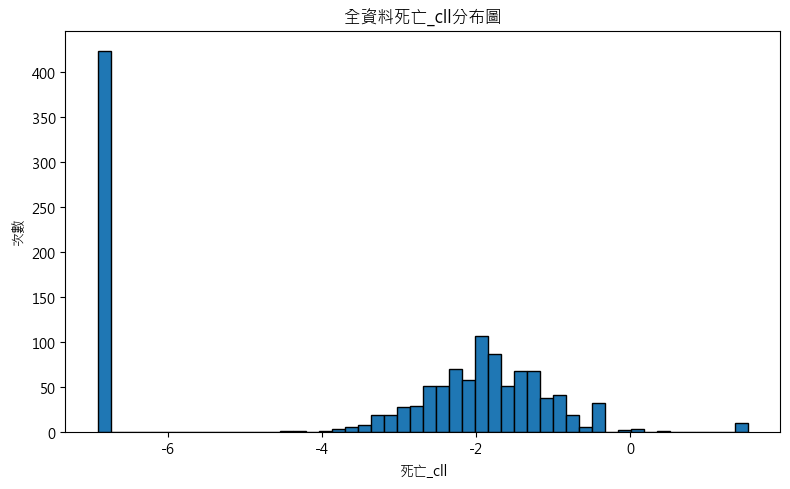

In [ ]:
# =========================
# 6) 全資料死亡_cll 分布圖
# =========================
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    plot_df["死亡_cll"],
    bins=50,
    density=False,
    edgecolor="black"
)

ax.set_xlabel("死亡_cll")
ax.set_ylabel("次數")
ax.set_title("全資料死亡_cll分布圖")

ax.set_ylim(bottom=0)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()

# save_path = os.path.join(output_dir, "全資料死亡_cll分布圖.png")
# plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

2015 年資料筆數：336
count    336.000000
mean      -3.788232
std        2.299573
min       -6.907255
25%       -6.907255
50%       -2.673700
75%       -2.013419
max       -0.366513
Name: 死亡_cll, dtype: float64
----------------------------------------


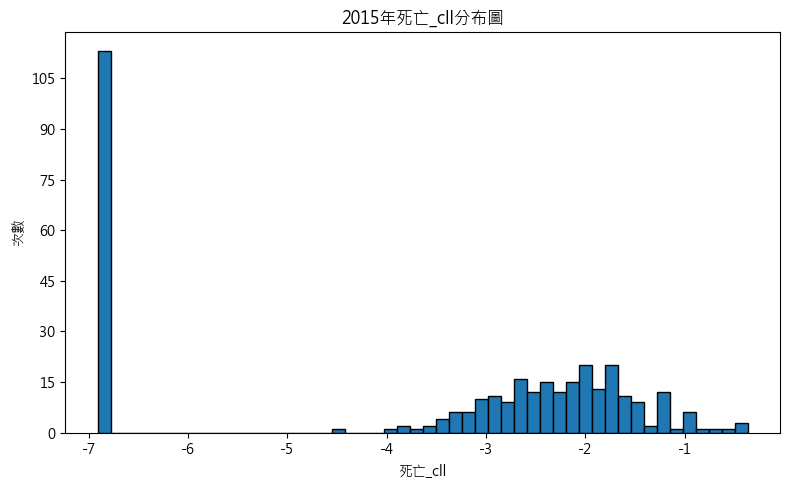

2016 年資料筆數：330
count    330.000000
mean      -3.807847
std        2.486852
min       -6.907255
25%       -6.907255
50%       -2.569731
75%       -1.808746
max        1.527180
Name: 死亡_cll, dtype: float64
----------------------------------------


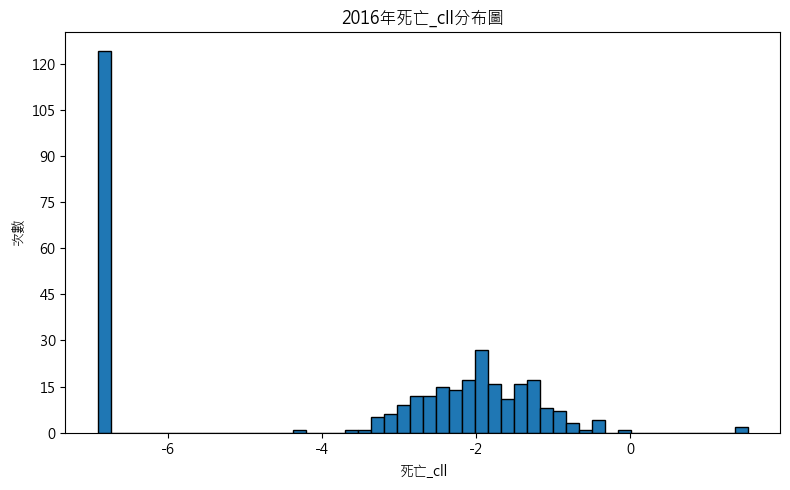

2017 年資料筆數：318
count    318.000000
mean      -3.407052
std        2.457657
min       -6.907255
25%       -6.907255
50%       -2.250367
75%       -1.701961
max        1.527180
Name: 死亡_cll, dtype: float64
----------------------------------------


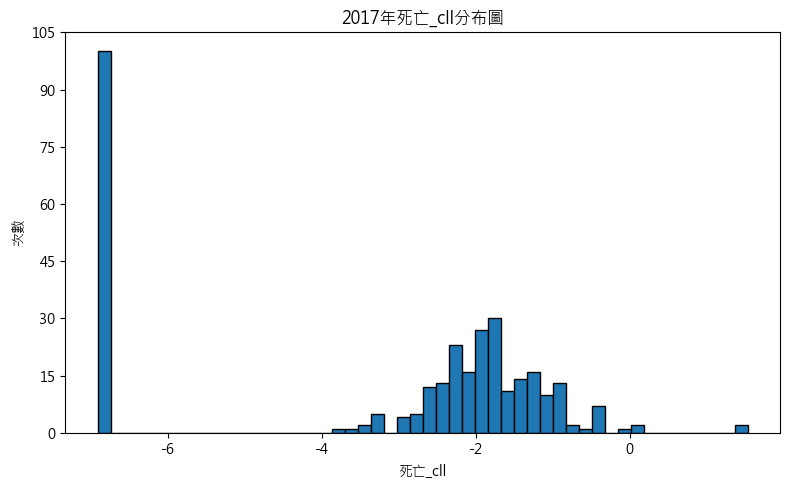

2018 年資料筆數：313
count    313.000000
mean      -2.930232
std        2.562882
min       -6.907255
25%       -6.907255
50%       -1.789410
75%       -1.245899
max        1.527180
Name: 死亡_cll, dtype: float64
----------------------------------------


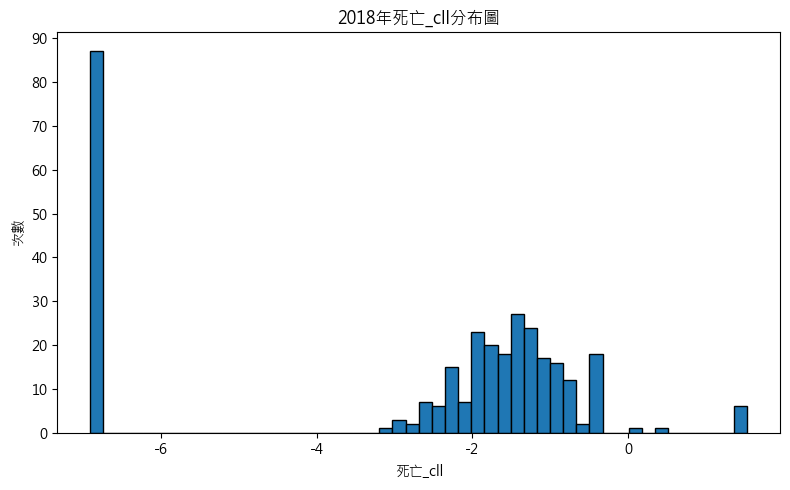

In [36]:
# =========================
# 7) 逐年死亡_cll 分布圖
# =========================
years = [2015, 2016, 2017, 2018]

for year in years:
    yearly_data = plot_df.loc[plot_df["年度"] == year, "死亡_cll"].dropna()

    print(f"{year} 年資料筆數：{len(yearly_data)}")
    print(yearly_data.describe())
    print("-" * 40)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        yearly_data,
        bins=50,
        density=False,
        edgecolor="black"
    )

    ax.set_xlabel("死亡_cll")
    ax.set_ylabel("次數")
    ax.set_title(f"{year}年死亡_cll分布圖")

    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()

    # save_path = os.path.join(output_dir, f"{year}年死亡_cll分布圖.png")
    # plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

normal test

In [30]:
import pandas as pd
import numpy as np
from scipy import stats

# =========================
# 1) 讀取資料
# =========================
file_path = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料變換可數型.xlsx"
df = pd.read_excel(file_path)

# 如果你用 CSV，改成：
# file_path = r"C:/Users/User/Desktop/LC analysis/LC analysis.csv"
# df = pd.read_csv(file_path, encoding="cp950")

# =========================
# 2) 整理年份
# =========================
year_try = pd.to_datetime(df["年份"], errors="coerce")

if year_try.notna().sum() > 0:
    df["年度"] = year_try.dt.year
else:
    df["年度"] = pd.to_numeric(df["年份"], errors="coerce")

# =========================
# 3) 整理死亡_cll
#    如果原本資料已有死亡_cll，直接使用
#    如果沒有，就從死亡重新轉換
# =========================
if "死亡_cll" not in df.columns:
    print("資料中沒有死亡_cll，將由死亡重新進行 cloglog 轉換。")
    
    df["死亡"] = pd.to_numeric(df["死亡"], errors="coerce")
    
    # 依你目前的特殊點：
    # 死亡 = 0 會被截到 0.001，轉換後約為 -6.907255
    # 死亡 = 1 會被截到 0.99，轉換後約為 1.527180
    death_clip = df["死亡"].clip(lower=0.001, upper=0.99)
    df["死亡_cll"] = np.log(-np.log(1 - death_clip))
else:
    df["死亡_cll"] = pd.to_numeric(df["死亡_cll"], errors="coerce")

# =========================
# 4) 排除兩個特殊點
# =========================
exclude_values = [
    1.5271796258079,
    -6.90725507052372
]

tol = 1e-8

mask = df["死亡_cll"].notna()

for value in exclude_values:
    mask = mask & (~np.isclose(df["死亡_cll"], value, atol=tol, rtol=0))

df_normal_part = df.loc[mask, ["年度", "死亡_cll"]].dropna().copy()

print("原始資料筆數：", len(df))
print("排除後資料筆數：", len(df_normal_part))

for value in exclude_values:
    n_excluded = np.isclose(df["死亡_cll"], value, atol=tol, rtol=0).sum()
    print(f"排除 {value} 的筆數：{n_excluded}")

print("\n排除後各年度筆數：")
print(df_normal_part["年度"].value_counts().sort_index())

原始資料筆數： 1297
排除後資料筆數： 863
排除 1.5271796258079 的筆數：10
排除 -6.90725507052372 的筆數：424

排除後各年度筆數：
年度
2015    223
2016    204
2017    216
2018    220
Name: count, dtype: int64


In [31]:
# =========================
# 5) 常態檢定函數
# =========================
def normality_test(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    
    result = {}
    result["n"] = len(x)
    result["mean"] = x.mean()
    result["sd"] = x.std()
    result["skewness"] = stats.skew(x, bias=False)
    result["excess_kurtosis"] = stats.kurtosis(x, fisher=True, bias=False)
    
    # Shapiro-Wilk normality test
    shapiro_stat, shapiro_p = stats.shapiro(x)
    result["Shapiro_W"] = shapiro_stat
    result["Shapiro_p"] = shapiro_p
    
    # D'Agostino-Pearson normality test
    k2_stat, k2_p = stats.normaltest(x)
    result["DAgostino_K2"] = k2_stat
    result["DAgostino_p"] = k2_p
    
    # Anderson-Darling test
    ad = stats.anderson(x, dist="norm")
    result["Anderson_A2"] = ad.statistic
    
    # 取 5% 顯著水準的臨界值
    ad_table = pd.DataFrame({
        "significance_level": ad.significance_level,
        "critical_value": ad.critical_values
    })
    
    cv_5 = ad_table.loc[ad_table["significance_level"] == 5, "critical_value"].iloc[0]
    result["Anderson_cv_5pct"] = cv_5
    result["Anderson_reject_5pct"] = ad.statistic > cv_5
    
    return result

# =========================
# 6) 整體死亡_cll 常態檢定
# =========================
overall_result = normality_test(df_normal_part["死亡_cll"])

overall_table = pd.DataFrame([overall_result], index=["All"])
print("\n整體排除特殊點後的死亡_cll 常態檢定：")
print(overall_table)


整體排除特殊點後的死亡_cll 常態檢定：
       n      mean        sd  skewness  excess_kurtosis  Shapiro_W  Shapiro_p  \
All  863 -1.873275  0.742281 -0.056215         0.026903   0.997062   0.117458   

     DAgostino_K2  DAgostino_p  Anderson_A2  Anderson_cv_5pct  \
All      0.518299     0.771708     0.594277             0.783   

     Anderson_reject_5pct  
All                 False  


In [32]:
# =========================
# 8) 簡單判斷
# =========================
alpha = 0.05

print("\n常態檢定判讀：")

print("\n整體：")
if overall_result["Shapiro_p"] < alpha:
    print("Shapiro-Wilk：p < 0.05，拒絕常態假設。")
else:
    print("Shapiro-Wilk：p >= 0.05，未拒絕常態假設。")

if overall_result["DAgostino_p"] < alpha:
    print("D'Agostino-Pearson：p < 0.05，拒絕常態假設。")
else:
    print("D'Agostino-Pearson：p >= 0.05，未拒絕常態假設。")

if overall_result["Anderson_reject_5pct"]:
    print("Anderson-Darling：A2 大於 5% 臨界值，拒絕常態假設。")
else:
    print("Anderson-Darling：A2 未大於 5% 臨界值，未拒絕常態假設。")


常態檢定判讀：

整體：
Shapiro-Wilk：p >= 0.05，未拒絕常態假設。
D'Agostino-Pearson：p >= 0.05，未拒絕常態假設。
Anderson-Darling：A2 未大於 5% 臨界值，未拒絕常態假設。


In [33]:
# =========================
# 7) 分年度常態檢定
# =========================
year_results = []

for year in [2015, 2016, 2017, 2018]:
    yearly_data = df_normal_part.loc[df_normal_part["年度"] == year, "死亡_cll"]
    
    if len(yearly_data) >= 8:
        res = normality_test(yearly_data)
        res["年度"] = year
        year_results.append(res)
    else:
        print(f"{year} 年資料筆數太少，不建議做常態檢定。")

year_table = pd.DataFrame(year_results)
year_table = year_table[
    [
        "年度", "n", "mean", "sd", "skewness", "excess_kurtosis",
        "Shapiro_W", "Shapiro_p",
        "DAgostino_K2", "DAgostino_p",
        "Anderson_A2", "Anderson_cv_5pct", "Anderson_reject_5pct"
    ]
]

print("\n逐年排除特殊點後的死亡_cll 常態檢定：")
print(year_table)


逐年排除特殊點後的死亡_cll 常態檢定：
     年度    n      mean        sd  skewness  excess_kurtosis  Shapiro_W  \
0  2015  223 -2.207741  0.720205 -0.037265        -0.003899   0.996379   
1  2016  204 -1.976198  0.709405 -0.062760         0.001550   0.995864   
2  2017  216 -1.832275  0.699523  0.091956         0.300088   0.991148   
3  2018  220 -1.479065  0.643797  0.051142        -0.199249   0.990641   

   Shapiro_p  DAgostino_K2  DAgostino_p  Anderson_A2  Anderson_cv_5pct  \
0   0.885892      0.071163     0.965044     0.236806             0.774   
1   0.858270      0.164082     0.921234     0.226779             0.772   
2   0.212603      1.269022     0.530195     0.549193             0.773   
3   0.167528      0.401884     0.817960     0.455192             0.773   

   Anderson_reject_5pct  
0                 False  
1                 False  
2                 False  
3                 False  


時空間驗證

In [1]:
# =========================================================
# LC 資料：連續型變數的四階段空間 / 時空相依性分析
#
# 論文四階段流程：
# 第一階段：年度別 Global Moran's I
# 第二階段：年度別 Local Moran / LISA，使用 FDR 校正
# 第三階段：跨年度時空延續性
#           3-1 年際差分 Differential Moran's I
#           3-2 跨年 Bivariate Moran's I
# 第四階段：年度別 OLS 殘差 Moran's I
#
# 若尚未安裝：
# pip install pandas geopandas numpy matplotlib openpyxl statsmodels libpysal esda
# =========================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.weights import Queen, KNN, attach_islands
from esda import Moran, Moran_Local, Moran_BV
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font
from openpyxl.utils import get_column_letter


# =========================================================
# 0) 路徑設定
# =========================================================
XLSX_PATH = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料變換可數型.xlsx"
SHP_PATH  = r"C:/Users/User/Desktop/TOWN_MOI/TOWN_MOI_1140318.shp"

OUT_DIR = Path(r"C:/Users/User/Desktop/LC analysis/spatial_autocorr_results_死亡_cll")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# 1) 欄位設定
# =========================================================
YEAR_COL   = "年份"
TOWN_COL   = "鄉鎮"
TARGET_COL = "死亡_cll"

# 殘差 Moran 要使用的協變數
X_COLS_FOR_RESID = [
    "總人口數"
    "Lead_water",
    "Lead_soil",
    "PM2.5 (ug/m3)",
    "Income_regular (百萬元)",
    "每百萬人病床數 (床/萬人)",
    "平均年齡（歲）",
    "性別(男)",
    "平均BMI  (kg/m2)",
    "平均日常體能狀態（分）",
    "加權 CCI",
]


# =========================================================
# 2) 輔助函數
# =========================================================
def normalize_town_name(s):
    """
    行政區名稱標準化：
    1. 去除空白
    2. 臺轉台
    """
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = s.replace("臺", "台")
    s = s.replace(" ", "")
    return s


def detect_shp_join_cols(gdf_shp):
    """
    自動偵測 shapefile 中的縣市與鄉鎮欄位名稱
    """
    county_candidates = ["COUNTYNAME", "COUNTY", "縣市", "縣市名稱"]
    town_candidates   = ["TOWNNAME", "TOWN", "鄉鎮市區", "鄉鎮市區名稱", "鄉鎮"]

    county_col = next((c for c in county_candidates if c in gdf_shp.columns), None)
    town_col   = next((c for c in town_candidates if c in gdf_shp.columns), None)

    if county_col is None and town_col is None:
        raise ValueError(
            f"shapefile 找不到可用的行政區欄位，現有欄位為：{list(gdf_shp.columns)}"
        )

    return county_col, town_col


def build_spatial_weights(gdf):
    """
    建立 Queen contiguity spatial weights。
    若存在 islands，使用 KNN k=1 連接孤立區域。
    """
    ids = gdf["town_key"].tolist()

    w = Queen.from_dataframe(gdf, ids=ids)

    if len(w.islands) > 0:
        w_knn1 = KNN.from_dataframe(gdf, k=1, ids=ids)
        w = attach_islands(w, w_knn1)

    w.transform = "r"
    return w


def lisa_cluster_from_q_and_sig(q, sig):
    """
    geoda_quads=False 時：
    q = 1: HH
    q = 2: LH
    q = 3: LL
    q = 4: HL

    這裡的 sig 建議使用 FDR 校正後的顯著性。
    """
    quad_map = {
        1: "HH",
        2: "LH",
        3: "LL",
        4: "HL"
    }

    out = []
    for qi, si in zip(q, sig):
        if si:
            out.append(quad_map.get(int(qi), "Unknown"))
        else:
            out.append("Not significant")

    return out


def plot_lisa_map(gdf, year, target_col, out_png):
    """
    輸出 LISA cluster map。
    注意：此圖使用 lisa_cluster 欄位，因此若 lisa_cluster 是根據 FDR 顯著性建立，
    圖上 HH / LL / HL / LH 即代表 FDR 校正後仍顯著的群聚。
    """
    color_map = {
        "HH": "#d73027",
        "LL": "#4575b4",
        "HL": "#fdae61",
        "LH": "#91bfdb",
        "Not significant": "#d9d9d9",
        "Unknown": "#cccccc",
    }

    fig, ax = plt.subplots(figsize=(8, 10))

    gdf.plot(
        color=gdf["lisa_cluster"].map(color_map).fillna("#cccccc"),
        linewidth=0.25,
        edgecolor="black",
        ax=ax
    )

    ax.set_title(f"LISA Cluster Map (death, {year})", fontsize=14)
    ax.axis("off")

    import matplotlib.patches as mpatches
    handles = [
        mpatches.Patch(color=color_map[k], label=k)
        for k in ["HH", "LL", "HL", "LH", "Not significant"]
    ]

    ax.legend(handles=handles, loc="lower left", frameon=True)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()


def sig_star(p):
    """
    p-value 顯著性標記。
    """
    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "."
    else:
        return ""


def judge_moran(I, p, alpha=0.05):
    """
    根據 Moran's I 與 p-value 判斷空間自相關結果。
    """
    if pd.isna(I) or pd.isna(p):
        return "無法判定"

    if p >= alpha:
        return "未達顯著空間自相關"

    if I > 0:
        return "顯著正向空間自相關"
    elif I < 0:
        return "顯著負向空間自相關"
    else:
        return "無明顯方向"


def interpretation_global(I, p):
    """
    第一階段 Global Moran's I 的論文解釋建議。
    """
    if pd.isna(I) or pd.isna(p):
        return "該年度資料不足或無法完成全域 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示該年度目標變數在整體空間上呈現相似值聚集現象，高值或低值地區並非隨機分布。"
    elif p < 0.05 and I < 0:
        return "表示該年度目標變數呈現空間離散或相鄰地區差異較大的分布型態。"
    else:
        return "表示該年度未觀察到顯著的全域空間自相關，整體空間聚集證據較弱。"


def interpretation_diff(I, p):
    """
    第三階段 Differential Moran's I 的論文解釋建議。
    """
    if pd.isna(I) or pd.isna(p):
        return "該年際資料不足或無法完成差分 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示年度變化量在空間上具有聚集性，相鄰地區的變動方向或幅度具有相似性。"
    elif p < 0.05 and I < 0:
        return "表示年度變化量在相鄰地區間呈現反向或不一致變動。"
    else:
        return "表示年度變化量未呈現顯著空間聚集，年際變動較接近隨機分布。"


def interpretation_bv(I, p):
    """
    第三階段 Bivariate Moran's I 的論文解釋建議。
    """
    if pd.isna(I) or pd.isna(p):
        return "該年際資料不足或無法完成雙變量 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示今年本地值與鄰近地區前一年值存在正向關聯，支持跨年度空間延續性。"
    elif p < 0.05 and I < 0:
        return "表示今年本地值與鄰近地區前一年值呈現反向關聯。"
    else:
        return "表示今年本地值與鄰近地區前一年值之間未呈現顯著跨年空間關聯。"


def interpretation_resid(I, p):
    """
    第四階段 OLS residual Moran's I 的論文解釋建議。
    """
    if pd.isna(I) or pd.isna(p):
        return "該年度資料不足或無法完成殘差 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示在納入協變數後，殘差仍存在顯著正向空間自相關，代表尚有未被模型解釋的空間結構。"
    elif p < 0.05 and I < 0:
        return "表示殘差呈現顯著負向空間自相關，鄰近地區殘差方向具有差異。"
    else:
        return "表示加入協變數後，殘差未呈現顯著空間自相關，協變數已解釋多數空間結構。"


def round_numeric_cols(df, digits=4):
    """
    將數值欄位四捨五入，讓輸出表格更適合放進論文。
    """
    if df.empty:
        return df

    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)

    return out


def auto_format_excel(xlsx_path):
    """
    簡單整理 Excel 格式：
    1. 凍結第一列
    2. 表頭加粗
    3. 自動欄寬
    4. 自動換行
    """
    wb = load_workbook(xlsx_path)

    for ws in wb.worksheets:
        ws.freeze_panes = "A2"

        for cell in ws[1]:
            cell.font = Font(bold=True)
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for row in ws.iter_rows():
            for cell in row:
                cell.alignment = Alignment(vertical="top", wrap_text=True)

        for col_idx, col_cells in enumerate(ws.columns, start=1):
            max_length = 0
            col_letter = get_column_letter(col_idx)

            for cell in col_cells:
                value = cell.value
                if value is None:
                    continue

                value_len = len(str(value))
                if value_len > max_length:
                    max_length = value_len

            adjusted_width = min(max(max_length + 2, 10), 45)
            ws.column_dimensions[col_letter].width = adjusted_width

    wb.save(xlsx_path)


# =========================================================
# 3) 讀取 Excel
# =========================================================
df = pd.read_excel(XLSX_PATH).copy()

df[YEAR_COL] = pd.to_datetime(df[YEAR_COL], errors="coerce").dt.year
df[TOWN_COL] = df[TOWN_COL].map(normalize_town_name)

numeric_cols = [TARGET_COL] + [c for c in X_COLS_FOR_RESID if c in df.columns]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=[YEAR_COL, TOWN_COL, TARGET_COL]).copy()

df[YEAR_COL] = df[YEAR_COL].astype(int)
df["town_key"] = df[TOWN_COL]
df["analysis_value"] = df[TARGET_COL]


# =========================================================
# 4) 讀取 shapefile 並建立 town_key
# =========================================================
gdf_shp = gpd.read_file(SHP_PATH).copy()

county_col, town_col = detect_shp_join_cols(gdf_shp)

if county_col is not None and town_col is not None:
    gdf_shp["town_key"] = (
        gdf_shp[county_col].astype(str).map(normalize_town_name) +
        gdf_shp[town_col].astype(str).map(normalize_town_name)
    )
elif town_col is not None:
    gdf_shp["town_key"] = gdf_shp[town_col].astype(str).map(normalize_town_name)
else:
    raise ValueError("無法建立 shapefile 的 town_key")

gdf_shp = gdf_shp[["town_key", "geometry"]].drop_duplicates("town_key").copy()


# =========================================================
# 5) 建立每年 GeoDataFrame
# =========================================================
def make_year_gdf(year):
    sub = df[df[YEAR_COL] == year].copy()

    g = gdf_shp.merge(sub, on="town_key", how="inner")
    g = g.sort_values("town_key").reset_index(drop=True)

    g = gpd.GeoDataFrame(g, geometry="geometry", crs=gdf_shp.crs)

    return g


YEARS = sorted(df[YEAR_COL].dropna().unique())


# =========================================================
# 6) 第一階段與第二階段：
#    年度別 Global Moran + Local Moran / LISA
# =========================================================
global_rows = []
lisa_all = []

for yr in YEARS:

    g = make_year_gdf(yr).copy()

    if len(g) == 0:
        continue

    w = build_spatial_weights(g)
    y = g["analysis_value"].to_numpy(dtype=float)

    # -----------------------------------------------------
    # 第一階段：年度別 Global Moran's I
    # -----------------------------------------------------
    moran_g = Moran(
        y=y,
        w=w,
        transformation="r",
        permutations=999,
        two_tailed=True
    )

    global_rows.append({
        "year": yr,
        "target_col": TARGET_COL,
        "n_area": len(g),
        "Moran_I": moran_g.I,
        "E_I": moran_g.EI,
        "p_norm": moran_g.p_norm,
        "p_rand": moran_g.p_rand,
        "p_sim": moran_g.p_sim,
        "z_sim": moran_g.z_sim,
        "value_mean": np.mean(y),
        "value_sd": np.std(y, ddof=1),
        "n_islands_after_fix": len(w.islands),
    })

    # -----------------------------------------------------
    # 第二階段：年度別 Local Moran / LISA
    # -----------------------------------------------------
    moran_l = Moran_Local(
        y,
        w,
        transformation="r",
        permutations=999,
        geoda_quads=False,
        seed=2026
    )

    reject_fdr, p_fdr, _, _ = multipletests(
        moran_l.p_sim,
        alpha=0.05,
        method="fdr_bh"
    )

    g["local_I"] = moran_l.Is
    g["q"] = moran_l.q.astype(int)
    g["p_sim"] = moran_l.p_sim
    g["p_fdr"] = p_fdr

    # 原始 p < 0.05
    g["sig_raw_05"] = g["p_sim"] < 0.05

    # FDR 校正後顯著
    g["sig_fdr_05"] = reject_fdr

    # 重要：LISA 圖與群聚判斷使用 FDR 校正後顯著性
    g["lisa_cluster"] = lisa_cluster_from_q_and_sig(
        g["q"],
        g["sig_fdr_05"]
    )

    lisa_all.append(pd.DataFrame(g.drop(columns="geometry")))

    plot_lisa_map(
        gdf=g,
        year=yr,
        target_col=TARGET_COL,
        out_png=OUT_DIR / f"lisa_map_{TARGET_COL}_{yr}.png"
    )


global_moran_df = pd.DataFrame(global_rows)

if len(lisa_all) > 0:
    lisa_detail_df = pd.concat(lisa_all, ignore_index=True)
else:
    lisa_detail_df = pd.DataFrame()


# =========================================================
# 7) 第三階段之一：
#    年際差分 Differential Moran's I
#    diff = value(t) - value(t-1)
# =========================================================
diff_rows = []

wide = (
    df.pivot_table(
        index="town_key",
        columns=YEAR_COL,
        values="analysis_value",
        aggfunc="first"
    )
    .reset_index()
)

for y_prev, y_curr in zip(YEARS[:-1], YEARS[1:]):

    tmp = wide[["town_key", y_prev, y_curr]].copy()
    tmp = tmp.dropna().copy()

    tmp["diff_value"] = tmp[y_curr] - tmp[y_prev]

    g = gdf_shp.merge(tmp, on="town_key", how="inner")
    g = g.sort_values("town_key").reset_index(drop=True)

    if len(g) == 0:
        continue

    g = gpd.GeoDataFrame(g, geometry="geometry", crs=gdf_shp.crs)

    w = build_spatial_weights(g)

    moran_diff = Moran(
        y=g["diff_value"].to_numpy(dtype=float),
        w=w,
        transformation="r",
        permutations=999,
        two_tailed=True
    )

    diff_rows.append({
        "target_col": TARGET_COL,
        "year_prev": y_prev,
        "year_curr": y_curr,
        "n_area": len(g),
        "Moran_I_diff": moran_diff.I,
        "E_I": moran_diff.EI,
        "p_norm": moran_diff.p_norm,
        "p_rand": moran_diff.p_rand,
        "p_sim": moran_diff.p_sim,
        "z_sim": moran_diff.z_sim,
        "diff_mean": g["diff_value"].mean(),
        "diff_sd": g["diff_value"].std(ddof=1),
    })


diff_moran_df = pd.DataFrame(diff_rows)


# =========================================================
# 8) 第三階段之二：
#    跨年 Bivariate Moran
#    看今年本地 value 與鄰近地區前一年 value 的關聯
# =========================================================
bv_rows = []

for y_prev, y_curr in zip(YEARS[:-1], YEARS[1:]):

    tmp = wide[["town_key", y_prev, y_curr]].copy()
    tmp = tmp.dropna().copy()

    tmp = tmp.rename(
        columns={
            y_prev: "value_prev",
            y_curr: "value_curr"
        }
    )

    g = gdf_shp.merge(tmp, on="town_key", how="inner")
    g = g.sort_values("town_key").reset_index(drop=True)

    if len(g) == 0:
        continue

    g = gpd.GeoDataFrame(g, geometry="geometry", crs=gdf_shp.crs)

    w = build_spatial_weights(g)

    moran_bv = Moran_BV(
        x=g["value_curr"].to_numpy(dtype=float),
        y=g["value_prev"].to_numpy(dtype=float),
        w=w,
        transformation="r",
        permutations=999
    )

    bv_rows.append({
        "target_col": TARGET_COL,
        "year_prev": y_prev,
        "year_curr": y_curr,
        "n_area": len(g),
        "Moran_BV_I": moran_bv.I,
        "p_sim": moran_bv.p_sim,
        "EI_sim": getattr(moran_bv, "EI_sim", np.nan),
    })


bivariate_moran_df = pd.DataFrame(bv_rows)


# =========================================================
# 9) 第四階段：
#    年度別 OLS 殘差 Moran's I
# =========================================================
resid_rows = []
resid_detail_list = []

available_xcols = [c for c in X_COLS_FOR_RESID if c in df.columns]

for yr in YEARS:

    g = make_year_gdf(yr).copy()

    keep_cols = ["analysis_value"] + available_xcols

    for c in keep_cols:
        g[c] = pd.to_numeric(g[c], errors="coerce")

    g = g.dropna(subset=keep_cols).copy()

    # 避免樣本數太少導致 OLS 不穩定
    if len(g) < max(20, len(available_xcols) + 5):
        continue

    X = sm.add_constant(g[available_xcols], has_constant="add")
    y = g["analysis_value"]

    model = sm.OLS(y, X).fit()

    g["resid"] = model.resid

    w = build_spatial_weights(g)

    moran_resid = Moran(
        y=g["resid"].to_numpy(dtype=float),
        w=w,
        transformation="r",
        permutations=999,
        two_tailed=True
    )

    resid_rows.append({
        "year": yr,
        "target_col": TARGET_COL,
        "n_area": len(g),
        "R2": model.rsquared,
        "adj_R2": model.rsquared_adj,
        "AIC": model.aic,
        "BIC": model.bic,
        "Moran_I_resid": moran_resid.I,
        "E_I": moran_resid.EI,
        "p_norm": moran_resid.p_norm,
        "p_rand": moran_resid.p_rand,
        "p_sim": moran_resid.p_sim,
        "z_sim": moran_resid.z_sim,
    })

    tmp = g[[TOWN_COL, "town_key", "analysis_value", "resid"] + available_xcols].copy()
    tmp["year"] = yr

    resid_detail_list.append(tmp)


resid_moran_df = pd.DataFrame(resid_rows)

if len(resid_detail_list) > 0:
    resid_detail_df = pd.concat(resid_detail_list, ignore_index=True)
else:
    resid_detail_df = pd.DataFrame()


# =========================================================
# 10) 論文用四階段結果整理
# =========================================================

# ---------------------------------------------------------
# 第一階段：年度別 Global Moran's I
# ---------------------------------------------------------
stage1_global = pd.DataFrame()

if not global_moran_df.empty:

    stage1_global = global_moran_df.copy()

    stage1_global["階段"] = "第一階段"
    stage1_global["分析主題"] = "年度別全域空間相依性"
    stage1_global["分析方法"] = "Global Moran's I"
    stage1_global["年份或年際"] = stage1_global["year"].astype(str)

    stage1_global["I值"] = stage1_global["Moran_I"]
    stage1_global["p值"] = stage1_global["p_sim"]
    stage1_global["顯著性"] = stage1_global["p值"].apply(sig_star)

    stage1_global["結果判斷"] = stage1_global.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage1_global["論文解釋建議"] = stage1_global.apply(
        lambda r: interpretation_global(r["I值"], r["p值"]),
        axis=1
    )

    stage1_global = stage1_global[
        [
            "階段", "分析主題", "分析方法", "target_col",
            "年份或年際", "n_area",
            "I值", "E_I", "z_sim", "p值", "顯著性",
            "value_mean", "value_sd",
            "結果判斷", "論文解釋建議"
        ]
    ]


# ---------------------------------------------------------
# 第二階段：年度別 Local Moran / LISA 摘要
# ---------------------------------------------------------
def make_lisa_summary(lisa_detail_df):

    if lisa_detail_df.empty:
        return pd.DataFrame()

    tmp = lisa_detail_df.copy()

    if YEAR_COL in tmp.columns:
        ycol = YEAR_COL
    elif "year" in tmp.columns:
        ycol = "year"
    else:
        raise ValueError("lisa_detail_df 找不到年份欄位，請確認是否包含 年份 或 year。")

    tmp["lisa_cluster"] = tmp["lisa_cluster"].fillna("Unknown")

    clusters = [
        "HH",
        "LL",
        "HL",
        "LH",
        "Not significant",
        "Unknown"
    ]

    count_tab = pd.crosstab(
        tmp[ycol],
        tmp["lisa_cluster"]
    )

    for c in clusters:
        if c not in count_tab.columns:
            count_tab[c] = 0

    count_tab = count_tab[clusters].reset_index()

    base = (
        tmp.groupby(ycol)
        .agg(
            n_area=("town_key", "count"),
            raw_sig_n=("sig_raw_05", "sum"),
            fdr_sig_n=("sig_fdr_05", "sum"),
            mean_local_I=("local_I", "mean"),
            min_p_sim=("p_sim", "min"),
            min_p_fdr=("p_fdr", "min"),
        )
        .reset_index()
    )

    out = base.merge(count_tab, on=ycol, how="left")

    out["階段"] = "第二階段"
    out["分析主題"] = "年度別局部空間異質性"
    out["分析方法"] = "Local Moran's I / LISA with FDR correction"
    out["target_col"] = TARGET_COL
    out["年份或年際"] = out[ycol].astype(str)

    out["FDR顯著比例"] = out["fdr_sig_n"] / out["n_area"]

    local_cluster_cols = ["HH", "LL", "HL", "LH"]

    def main_cluster(row):
        total_sig = row[local_cluster_cols].sum()

        if total_sig == 0:
            return "無顯著局部群聚"

        return row[local_cluster_cols].idxmax()

    out["主要局部型態"] = out.apply(main_cluster, axis=1)

    def lisa_judge(row):
        if row["fdr_sig_n"] == 0:
            return "FDR 校正後未見顯著局部群聚"
        else:
            return f"FDR 校正後仍有 {int(row['fdr_sig_n'])} 個顯著局部群聚"

    out["結果判斷"] = out.apply(lisa_judge, axis=1)

    def lisa_interp(row):
        if row["fdr_sig_n"] == 0:
            return "表示在控制多重比較後，該年度未呈現穩健的局部空間群聚。"
        else:
            return (
                f"表示在控制多重比較後，該年度仍有局部空間異質性；"
                f"其中主要型態為 {row['主要局部型態']}，"
                f"可進一步對應 LISA 群聚圖解釋高風險或低風險區域。"
            )

    out["論文解釋建議"] = out.apply(lisa_interp, axis=1)

    out = out[
        [
            "階段", "分析主題", "分析方法", "target_col",
            "年份或年際", "n_area",
            "raw_sig_n", "fdr_sig_n", "FDR顯著比例",
            "HH", "LL", "HL", "LH", "Not significant",
            "mean_local_I", "min_p_sim", "min_p_fdr",
            "主要局部型態", "結果判斷", "論文解釋建議"
        ]
    ]

    return out


stage2_lisa = make_lisa_summary(lisa_detail_df)


# ---------------------------------------------------------
# 第三階段之一：年際差分 Differential Moran's I
# ---------------------------------------------------------
stage3_diff = pd.DataFrame()

if not diff_moran_df.empty:

    stage3_diff = diff_moran_df.copy()

    stage3_diff["階段"] = "第三階段"
    stage3_diff["分析主題"] = "跨年度時空延續性"
    stage3_diff["分析方法"] = "Differential Moran's I"

    stage3_diff["年份或年際"] = (
        stage3_diff["year_prev"].astype(str) +
        " → " +
        stage3_diff["year_curr"].astype(str)
    )

    stage3_diff["I值"] = stage3_diff["Moran_I_diff"]
    stage3_diff["p值"] = stage3_diff["p_sim"]
    stage3_diff["顯著性"] = stage3_diff["p值"].apply(sig_star)

    stage3_diff["結果判斷"] = stage3_diff.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage3_diff["論文解釋建議"] = stage3_diff.apply(
        lambda r: interpretation_diff(r["I值"], r["p值"]),
        axis=1
    )

    stage3_diff = stage3_diff[
        [
            "階段", "分析主題", "分析方法", "target_col",
            "年份或年際", "n_area",
            "I值", "E_I", "z_sim", "p值", "顯著性",
            "diff_mean", "diff_sd",
            "結果判斷", "論文解釋建議"
        ]
    ]


# ---------------------------------------------------------
# 第三階段之二：跨年 Bivariate Moran's I
# ---------------------------------------------------------
stage3_bv = pd.DataFrame()

if not bivariate_moran_df.empty:

    stage3_bv = bivariate_moran_df.copy()

    stage3_bv["階段"] = "第三階段"
    stage3_bv["分析主題"] = "跨年度時空延續性"
    stage3_bv["分析方法"] = "Bivariate Moran's I"

    stage3_bv["年份或年際"] = (
        stage3_bv["year_prev"].astype(str) +
        " → " +
        stage3_bv["year_curr"].astype(str)
    )

    stage3_bv["關聯結構"] = "今年本地值 vs 鄰近地區前一年值"

    stage3_bv["I值"] = stage3_bv["Moran_BV_I"]
    stage3_bv["p值"] = stage3_bv["p_sim"]
    stage3_bv["顯著性"] = stage3_bv["p值"].apply(sig_star)

    stage3_bv["結果判斷"] = stage3_bv.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage3_bv["論文解釋建議"] = stage3_bv.apply(
        lambda r: interpretation_bv(r["I值"], r["p值"]),
        axis=1
    )

    stage3_bv = stage3_bv[
        [
            "階段", "分析主題", "分析方法", "target_col",
            "年份或年際", "關聯結構", "n_area",
            "I值", "EI_sim", "p值", "顯著性",
            "結果判斷", "論文解釋建議"
        ]
    ]


# ---------------------------------------------------------
# 第四階段：年度別 OLS residual Moran's I
# ---------------------------------------------------------
stage4_resid = pd.DataFrame()

if not resid_moran_df.empty:

    stage4_resid = resid_moran_df.copy()

    stage4_resid["階段"] = "第四階段"
    stage4_resid["分析主題"] = "協變數調整後殘差空間相依性"
    stage4_resid["分析方法"] = "OLS residual Moran's I"
    stage4_resid["年份或年際"] = stage4_resid["year"].astype(str)

    stage4_resid["I值"] = stage4_resid["Moran_I_resid"]
    stage4_resid["p值"] = stage4_resid["p_sim"]
    stage4_resid["顯著性"] = stage4_resid["p值"].apply(sig_star)

    stage4_resid["結果判斷"] = stage4_resid.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage4_resid["論文解釋建議"] = stage4_resid.apply(
        lambda r: interpretation_resid(r["I值"], r["p值"]),
        axis=1
    )

    stage4_resid = stage4_resid[
        [
            "階段", "分析主題", "分析方法", "target_col",
            "年份或年際", "n_area",
            "R2", "adj_R2", "AIC", "BIC",
            "I值", "E_I", "z_sim", "p值", "顯著性",
            "結果判斷", "論文解釋建議"
        ]
    ]


# =========================================================
# 11) 論文用四階段總表
# =========================================================
paper_rows = []

# ---------------------------------------------------------
# 第一階段放入總表
# ---------------------------------------------------------
if not stage1_global.empty:

    for _, r in stage1_global.iterrows():

        paper_rows.append({
            "階段順序": 1,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "論文解釋建議": r["論文解釋建議"]
        })


# ---------------------------------------------------------
# 第二階段放入總表
# ---------------------------------------------------------
if not stage2_lisa.empty:

    for _, r in stage2_lisa.iterrows():

        paper_rows.append({
            "階段順序": 2,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "FDR 顯著 LISA 群聚數",
            "I值": np.nan,
            "p值": np.nan,
            "顯著性": "",
            "核心結果": (
                f"FDR 顯著數={int(r['fdr_sig_n'])}/{int(r['n_area'])}；"
                f"HH={int(r['HH'])}, "
                f"LL={int(r['LL'])}, "
                f"HL={int(r['HL'])}, "
                f"LH={int(r['LH'])}"
            ),
            "論文解釋建議": r["論文解釋建議"]
        })


# ---------------------------------------------------------
# 第三階段 Differential Moran 放入總表
# ---------------------------------------------------------
if not stage3_diff.empty:

    for _, r in stage3_diff.iterrows():

        paper_rows.append({
            "階段順序": 3,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Differential Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "論文解釋建議": r["論文解釋建議"]
        })


# ---------------------------------------------------------
# 第三階段 Bivariate Moran 放入總表
# ---------------------------------------------------------
if not stage3_bv.empty:

    for _, r in stage3_bv.iterrows():

        paper_rows.append({
            "階段順序": 3,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Bivariate Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "論文解釋建議": r["論文解釋建議"]
        })


# ---------------------------------------------------------
# 第四階段放入總表
# ---------------------------------------------------------
if not stage4_resid.empty:

    for _, r in stage4_resid.iterrows():

        paper_rows.append({
            "階段順序": 4,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Residual Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "論文解釋建議": r["論文解釋建議"]
        })


paper_four_stage_summary = pd.DataFrame(paper_rows)

if not paper_four_stage_summary.empty:

    paper_four_stage_summary = (
        paper_four_stage_summary
        .sort_values(["階段順序", "年份或年際", "分析方法"])
        .reset_index(drop=True)
    )


# =========================================================
# 12) 數值整理
# =========================================================
global_moran_df_out      = round_numeric_cols(global_moran_df)
lisa_detail_df_out       = round_numeric_cols(lisa_detail_df)
diff_moran_df_out        = round_numeric_cols(diff_moran_df)
bivariate_moran_df_out   = round_numeric_cols(bivariate_moran_df)
resid_moran_df_out       = round_numeric_cols(resid_moran_df)
resid_detail_df_out      = round_numeric_cols(resid_detail_df)

stage1_global_out        = round_numeric_cols(stage1_global)
stage2_lisa_out          = round_numeric_cols(stage2_lisa)
stage3_diff_out          = round_numeric_cols(stage3_diff)
stage3_bv_out            = round_numeric_cols(stage3_bv)
stage4_resid_out         = round_numeric_cols(stage4_resid)

paper_four_stage_summary_out = round_numeric_cols(paper_four_stage_summary)


# =========================================================
# 13) 輸出 Excel：強制更新版
# =========================================================

from datetime import datetime
import os

# 建立執行時間標籤，方便確認這次真的有輸出新檔
RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")

# 固定輸出檔案名稱
out_xlsx = OUT_DIR / f"LC_four_stage_spatiotemporal_thesis_{TARGET_COL}.xlsx"

# 額外輸出一份帶時間戳的備份檔，避免你誤看舊檔
out_xlsx_backup = OUT_DIR / f"LC_four_stage_spatiotemporal_thesis_{TARGET_COL}_{RUN_TAG}.xlsx"


# ---------------------------------------------------------
# A) 先確認輸出資料夾存在
# ---------------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("目前輸出資料夾：")
print(OUT_DIR)

print("\n本次固定輸出檔案：")
print(out_xlsx)

print("\n本次備份輸出檔案：")
print(out_xlsx_backup)


# ---------------------------------------------------------
# B) 若固定輸出檔已存在，先嘗試刪除
#    若 Excel 正在開啟，這裡會提醒你
# ---------------------------------------------------------
if out_xlsx.exists():
    try:
        out_xlsx.unlink()
        print("\n已刪除舊的固定輸出檔，準備重新輸出。")
    except PermissionError:
        print("\n警告：固定輸出檔案目前可能正在 Excel 中開啟，無法覆寫。")
        print("請先關閉該 Excel 檔案。")
        print("本次將只輸出時間戳備份檔。")
        out_xlsx = out_xlsx_backup


# ---------------------------------------------------------
# C) 輸出 Excel 的函數
# ---------------------------------------------------------
def export_all_results(xlsx_path):

    with pd.ExcelWriter(xlsx_path, engine="openpyxl", mode="w") as writer:

        # -------------------------------------------------
        # 原始完整結果
        # -------------------------------------------------
        global_moran_df_out.to_excel(
            writer,
            sheet_name="raw_global_moran",
            index=False
        )

        lisa_detail_df_out.to_excel(
            writer,
            sheet_name="raw_lisa_detail",
            index=False
        )

        diff_moran_df_out.to_excel(
            writer,
            sheet_name="raw_diff_moran",
            index=False
        )

        bivariate_moran_df_out.to_excel(
            writer,
            sheet_name="raw_bivariate_moran",
            index=False
        )

        resid_moran_df_out.to_excel(
            writer,
            sheet_name="raw_resid_moran",
            index=False
        )

        resid_detail_df_out.to_excel(
            writer,
            sheet_name="raw_resid_detail",
            index=False
        )

        # -------------------------------------------------
        # 論文用四階段結果表
        # -------------------------------------------------
        paper_four_stage_summary_out.to_excel(
            writer,
            sheet_name="paper_four_stage_summary",
            index=False
        )

        stage1_global_out.to_excel(
            writer,
            sheet_name="stage1_global",
            index=False
        )

        stage2_lisa_out.to_excel(
            writer,
            sheet_name="stage2_lisa_summary",
            index=False
        )

        stage3_diff_out.to_excel(
            writer,
            sheet_name="stage3_diff_moran",
            index=False
        )

        stage3_bv_out.to_excel(
            writer,
            sheet_name="stage3_bivariate_moran",
            index=False
        )

        stage4_resid_out.to_excel(
            writer,
            sheet_name="stage4_resid_moran",
            index=False
        )


# ---------------------------------------------------------
# D) 實際輸出固定檔案
# ---------------------------------------------------------
export_all_results(out_xlsx)


# ---------------------------------------------------------
# E) 另外輸出一份備份檔
#    如果固定檔案已經改成備份檔，則避免重複輸出
# ---------------------------------------------------------
if out_xlsx != out_xlsx_backup:
    export_all_results(out_xlsx_backup)


# ---------------------------------------------------------
# F) 嘗試美化 Excel
#    若美化失敗，不影響主要輸出
# ---------------------------------------------------------
try:
    auto_format_excel(out_xlsx)

    if out_xlsx != out_xlsx_backup:
        auto_format_excel(out_xlsx_backup)

    print("\nExcel 格式美化完成。")

except Exception as e:
    print("\nExcel 已成功輸出，但格式美化時發生問題。")
    print("錯誤訊息：", repr(e))


# ---------------------------------------------------------
# G) 確認檔案是否真的存在，並印出檔案大小與更新時間
# ---------------------------------------------------------
def check_output_file(xlsx_path):

    if not xlsx_path.exists():
        print(f"\n檔案不存在：{xlsx_path}")
        return

    stat = xlsx_path.stat()

    print("\n輸出檔案確認：")
    print("路徑：", xlsx_path)
    print("檔案大小 bytes：", stat.st_size)
    print("最後修改時間：", datetime.fromtimestamp(stat.st_mtime).strftime("%Y-%m-%d %H:%M:%S"))

    try:
        wb = load_workbook(xlsx_path, read_only=True)
        print("工作表清單：")
        print(wb.sheetnames)
        wb.close()
    except Exception as e:
        print("讀取工作表清單時發生問題：", repr(e))


check_output_file(out_xlsx)

if out_xlsx != out_xlsx_backup:
    check_output_file(out_xlsx_backup)


# =========================================================
# 14) 印出結果摘要
# =========================================================

print("\n完成。")
print("論文用四階段時空分析結果已輸出。")

print("\n==============================")
print("[輸出檔案]")
print("==============================")
print("固定檔：", out_xlsx)

if out_xlsx != out_xlsx_backup:
    print("備份檔：", out_xlsx_backup)

print("\n==============================")
print("[資料筆數檢查]")
print("==============================")
print("global_moran_df_out rows:", len(global_moran_df_out))
print("lisa_detail_df_out rows:", len(lisa_detail_df_out))
print("diff_moran_df_out rows:", len(diff_moran_df_out))
print("bivariate_moran_df_out rows:", len(bivariate_moran_df_out))
print("resid_moran_df_out rows:", len(resid_moran_df_out))
print("paper_four_stage_summary_out rows:", len(paper_four_stage_summary_out))

print("\n==============================")
print("[論文用四階段總表]")
print("==============================")
print(paper_four_stage_summary_out)



目前輸出資料夾：
C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_死亡_cll

本次固定輸出檔案：
C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_死亡_cll\LC_four_stage_spatiotemporal_thesis_死亡_cll.xlsx

本次備份輸出檔案：
C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_死亡_cll\LC_four_stage_spatiotemporal_thesis_死亡_cll_20260510_153202.xlsx

Excel 格式美化完成。

輸出檔案確認：
路徑： C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_死亡_cll\LC_four_stage_spatiotemporal_thesis_死亡_cll.xlsx
檔案大小 bytes： 498642
最後修改時間： 2026-05-10 15:32:13
工作表清單：
['raw_global_moran', 'raw_lisa_detail', 'raw_diff_moran', 'raw_bivariate_moran', 'raw_resid_moran', 'raw_resid_detail', 'paper_four_stage_summary', 'stage1_global', 'stage2_lisa_summary', 'stage3_diff_moran', 'stage3_bivariate_moran', 'stage4_resid_moran']

輸出檔案確認：
路徑： C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_死亡_cll\LC_four_stage_spatiotemporal_thesis_死亡_cll_20260510_153202.xlsx
檔案大小 bytes： 498643
最後修改時間： 2026-05-10 15:32:20
工作表清單：
['raw_glo

本島聚焦LISA圖

In [2]:
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches

# =========================================================
# 中文字體設定 (自動搜尋系統中的字體)
# =========================================================
# 針對 Windows 常見字體路徑
font_path = "C:/Windows/Fonts/msjh.ttc"  # 微軟正黑體
if not Path(font_path).exists():
    # 如果找不到，嘗試搜尋其他路徑 (或改用系統預設)
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
else:
    # 建立字體物件
    my_font = fm.FontProperties(fname=font_path)
    # 全域設定，這樣標題與標籤都會生效
    plt.rcParams['font.sans-serif'] = [my_font.get_name()]

plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

def plot_lisa_map_taiwan_focus(gdf, year, target_col, out_png):
    """
    修正中文顯示並聚焦台灣本島
    """
    color_map = {
        "HH": "#d73027",
        "LL": "#4575b4",
        "HL": "#fdae61",
        "LH": "#91bfdb",
        "Not significant": "#d9d9d9",
        "Unknown": "#cccccc",
    }

    fig, ax = plt.subplots(figsize=(8, 10))

    # 繪製地圖
    gdf.plot(
        color=gdf["lisa_cluster"].map(color_map).fillna("#cccccc"),
        linewidth=0.3,
        edgecolor="white",
        ax=ax
    )

    # 聚焦本島視窗
    ax.set_xlim(119.8, 122.4)
    ax.set_ylim(21.7, 25.4)

    # 標題 (target_col 現在應該能正確顯示中文)
    ax.set_title(f"{year} {target_col} LISA 空間群聚圖\n（台灣本島範圍）", fontsize=18, pad=15)
    ax.axis("off")

    # 圖例設定
    handles = [
        mpatches.Patch(facecolor=color_map[k], edgecolor='black', label=k)
        for k in ["HH", "LL", "HL", "LH", "Not significant"]
    ]
    
    ax.legend(
        handles=handles, 
        loc="lower left", 
        bbox_to_anchor=(1.02, 0.05), 
        frameon=True,
        title="LISA 分類",
        fontsize=11
    )

    plt.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.close()
    print(f"成功輸出中文圖檔：{out_png.name}")

# =========================================================
# 執行繪圖
# =========================================================
for yr in YEARS:
    year_data = lisa_detail_df[lisa_detail_df[YEAR_COL] == yr].copy()
    if year_data.empty: continue
        
    g_plot = gdf_shp.merge(year_data, on="town_key", how="inner")
    g_plot = gpd.GeoDataFrame(g_plot, geometry="geometry", crs=gdf_shp.crs)

    # 如果 shp 座標不是 4326，強制轉換以符合 set_xlim 的經緯度
    if g_plot.crs != "EPSG:4326":
        g_plot = g_plot.to_crs(epsg=4326)

    out_name = OUT_DIR / f"lisa_map_{TARGET_COL}_{yr}_main_island.png"
    
    plot_lisa_map_taiwan_focus(g_plot, yr, TARGET_COL, out_name)

成功輸出中文圖檔：lisa_map_死亡_cll_2015_main_island.png
成功輸出中文圖檔：lisa_map_死亡_cll_2016_main_island.png
成功輸出中文圖檔：lisa_map_死亡_cll_2017_main_island.png
成功輸出中文圖檔：lisa_map_死亡_cll_2018_main_island.png


補值0

In [ ]:
# =========================================================
# LC 資料：連續型變數的四階段空間 / 時空相依性分析
# 敏感度分析版：缺值全填 0
#
# 論文四階段流程：
# 第一階段：年度別 Global Moran's I
# 第二階段：年度別 Local Moran / LISA，使用 FDR 校正
# 第三階段：跨年度時空延續性
#           3-1 年際差分 Differential Moran's I
#           3-2 跨年 Bivariate Moran's I
# 第四階段：年度別 OLS 殘差 Moran's I
#
# 若尚未安裝：
# pip install pandas geopandas numpy matplotlib openpyxl statsmodels libpysal esda
# =========================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.weights import Queen, KNN, attach_islands
from esda import Moran, Moran_Local, Moran_BV
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font
from openpyxl.utils import get_column_letter


# =========================================================
# 0) 路徑設定
# =========================================================
XLSX_PATH = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料變換可數型.xlsx"
SHP_PATH  = r"C:/Users/User/Desktop/TOWN_MOI/TOWN_MOI_1140318.shp"

OUT_DIR = Path(r"C:/Users/User/Desktop/LC analysis/spatial_autocorr_results_zero_fill")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# 1) 欄位與模式設定
# =========================================================
YEAR_COL   = "年份"
TOWN_COL   = "鄉鎮"

# zero-fill 敏感度分析通常建議用原始死亡欄位
# 若你要改分析 cloglog 轉換值，改成 TARGET_COL = "死亡_cll"
TARGET_COL = "死亡_cll"

# 缺值處理模式
# "zero_fill"      -> 將缺值視為 0
# "observed_only"  -> 只分析原始有值者
FILL_MODE = "zero_fill"

# OLS 殘差分析的 target
# "observed_only" -> 只用原始有值資料做 OLS
# "filled"        -> 用補值後 analysis_value 做 OLS
OLS_TARGET_MODE = "observed_only"

# # 殘差 Moran 要使用的協變數
# X_COLS_FOR_RESID = [
#     "Lead_water",
#     "Lead_soil",
#     "PM2.5 (ug/m3)",
#     "Income_regular (百萬元)",
#     "每百萬人病床數 (床/萬人)",
#     "平均年齡（歲）",
#     "性別(男)",
#     "平均BMI  (kg/m2)",
#     "平均日常體能狀態（分）",
#     "加權 CCI",
# ]


# =========================================================
# 2) 輔助函數
# =========================================================
def normalize_town_name(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = s.replace("臺", "台")
    s = s.replace(" ", "")
    return s


def detect_shp_join_cols(gdf_shp):
    county_candidates = ["COUNTYNAME", "COUNTY", "縣市", "縣市名稱"]
    town_candidates   = ["TOWNNAME", "TOWN", "鄉鎮市區", "鄉鎮市區名稱", "鄉鎮"]

    county_col = next((c for c in county_candidates if c in gdf_shp.columns), None)
    town_col   = next((c for c in town_candidates if c in gdf_shp.columns), None)

    if county_col is None and town_col is None:
        raise ValueError(
            f"shapefile 找不到可用的行政區欄位，現有欄位為：{list(gdf_shp.columns)}"
        )

    return county_col, town_col


def can_run_moran(values):
    """
    Moran's I 至少需要：
    1. 有足夠樣本
    2. 數值不能全為常數
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 3:
        return False

    if np.nanstd(values, ddof=1) <= 0:
        return False

    return True


def can_run_bivariate_moran(x, y):
    """
    Bivariate Moran 需要 x 與 y 都不是常數。
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    if len(x) < 3:
        return False

    if np.nanstd(x, ddof=1) <= 0:
        return False

    if np.nanstd(y, ddof=1) <= 0:
        return False

    return True


def build_spatial_weights(gdf):
    """
    建立 Queen contiguity spatial weights。
    若存在 islands，使用 KNN k=1 連接孤立區域。
    """
    if len(gdf) < 3:
        raise ValueError("空間單元數太少，無法建立穩定的空間權重。")

    ids = gdf["town_key"].tolist()

    w = Queen.from_dataframe(gdf, ids=ids)

    if len(w.islands) > 0:
        w_knn1 = KNN.from_dataframe(gdf, k=1, ids=ids)
        w = attach_islands(w, w_knn1)

    w.transform = "r"
    return w


def lisa_cluster_from_q_and_sig(q, sig):
    """
    geoda_quads=False 時：
    q = 1: HH
    q = 2: LH
    q = 3: LL
    q = 4: HL
    """
    quad_map = {
        1: "HH",
        2: "LH",
        3: "LL",
        4: "HL"
    }

    out = []

    for qi, si in zip(q, sig):
        if si:
            out.append(quad_map.get(int(qi), "Unknown"))
        else:
            out.append("Not significant")

    return out


def fill_analysis_values(g, fill_mode="zero_fill"):
    """
    根據 fill_mode 建立 analysis_value。
    """
    g = g.copy()

    g["was_filled"] = g["analysis_observed"].isna()

    if fill_mode == "zero_fill":
        g["analysis_value"] = g["analysis_observed"].fillna(0.0)
        return g

    elif fill_mode == "observed_only":
        g["analysis_value"] = g["analysis_observed"]
        g = g.dropna(subset=["analysis_value"]).copy()
        g["was_filled"] = False
        return g

    else:
        raise ValueError("fill_mode must be 'zero_fill' or 'observed_only'")


def plot_lisa_map(gdf, year, target_col, out_png, fill_mode):
    """
    輸出 LISA cluster map。
    注意：此圖使用 lisa_cluster 欄位。
    本程式中的 lisa_cluster 是依據 FDR 校正後顯著性建立。
    """
    color_map = {
        "HH": "#d73027",
        "LL": "#4575b4",
        "HL": "#fdae61",
        "LH": "#91bfdb",
        "Not significant": "#d9d9d9",
        "Unknown": "#cccccc",
    }

    fig, ax = plt.subplots(figsize=(8, 10))

    gdf.plot(
        color=gdf["lisa_cluster"].map(color_map).fillna("#cccccc"),
        linewidth=0.25,
        edgecolor="black",
        ax=ax
    )

    # 黑框標示補值 polygon
    if "was_filled" in gdf.columns and gdf["was_filled"].any():
        gdf.loc[gdf["was_filled"]].boundary.plot(
            ax=ax,
            linewidth=0.6,
            color="black"
        )

    ax.set_title(f"LISA Cluster Map (Death, {year}, {fill_mode})", fontsize=14)
    ax.axis("off")

    import matplotlib.patches as mpatches

    handles = [
        mpatches.Patch(color=color_map[k], label=k)
        for k in ["HH", "LL", "HL", "LH", "Not significant"]
    ]

    handles.append(
        mpatches.Patch(
            facecolor="white",
            edgecolor="black",
            label="Filled polygon"
        )
    )

    ax.legend(handles=handles, loc="lower left", frameon=True)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()


def sig_star(p):
    """
    p-value 顯著性標記。
    """
    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "."
    else:
        return ""


def judge_moran(I, p, alpha=0.05):
    """
    根據 Moran's I 與 p-value 判斷結果。
    """
    if pd.isna(I) or pd.isna(p):
        return "無法判定"

    if p >= alpha:
        return "未達顯著空間自相關"

    if I > 0:
        return "顯著正向空間自相關"
    elif I < 0:
        return "顯著負向空間自相關"
    else:
        return "無明顯方向"


def interpretation_global(I, p):
    if pd.isna(I) or pd.isna(p):
        return "該年度資料不足、數值變異不足，或無法完成全域 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示該年度目標變數在整體空間上呈現相似值聚集現象，高值或低值地區並非隨機分布。"
    elif p < 0.05 and I < 0:
        return "表示該年度目標變數呈現空間離散或相鄰地區差異較大的分布型態。"
    else:
        return "表示該年度未觀察到顯著的全域空間自相關，整體空間聚集證據較弱。"


def interpretation_diff(I, p):
    if pd.isna(I) or pd.isna(p):
        return "該年際資料不足、差分值變異不足，或無法完成差分 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示年度變化量在空間上具有聚集性，相鄰地區的變動方向或幅度具有相似性。"
    elif p < 0.05 and I < 0:
        return "表示年度變化量在相鄰地區間呈現反向或不一致變動。"
    else:
        return "表示年度變化量未呈現顯著空間聚集，年際變動較接近隨機分布。"


def interpretation_bv(I, p):
    if pd.isna(I) or pd.isna(p):
        return "該年際資料不足、跨年變數變異不足，或無法完成雙變量 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示今年本地值與鄰近地區前一年值存在正向關聯，支持跨年度空間延續性。"
    elif p < 0.05 and I < 0:
        return "表示今年本地值與鄰近地區前一年值呈現反向關聯。"
    else:
        return "表示今年本地值與鄰近地區前一年值之間未呈現顯著跨年空間關聯。"


def interpretation_resid(I, p):
    if pd.isna(I) or pd.isna(p):
        return "該年度資料不足、殘差變異不足，或無法完成殘差 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示在納入協變數後，殘差仍存在顯著正向空間自相關，代表尚有未被模型解釋的空間結構。"
    elif p < 0.05 and I < 0:
        return "表示殘差呈現顯著負向空間自相關，鄰近地區殘差方向具有差異。"
    else:
        return "表示加入協變數後，殘差未呈現顯著空間自相關，協變數已解釋多數空間結構。"


def round_numeric_cols(df, digits=4):
    """
    將數值欄位四捨五入，讓輸出表格更適合放進論文。
    """
    if df.empty:
        return df

    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)

    return out


def auto_format_excel(xlsx_path):
    """
    簡單整理 Excel 格式。
    """
    wb = load_workbook(xlsx_path)

    for ws in wb.worksheets:
        ws.freeze_panes = "A2"

        for cell in ws[1]:
            cell.font = Font(bold=True)
            cell.alignment = Alignment(
                horizontal="center",
                vertical="center",
                wrap_text=True
            )

        for row in ws.iter_rows():
            for cell in row:
                cell.alignment = Alignment(
                    vertical="top",
                    wrap_text=True
                )

        for col_idx, col_cells in enumerate(ws.columns, start=1):
            max_length = 0
            col_letter = get_column_letter(col_idx)

            for cell in col_cells:
                value = cell.value
                if value is None:
                    continue

                value_len = len(str(value))
                if value_len > max_length:
                    max_length = value_len

            adjusted_width = min(max(max_length + 2, 10), 45)
            ws.column_dimensions[col_letter].width = adjusted_width

    wb.save(xlsx_path)


def check_output_file(xlsx_path):
    """
    確認輸出檔案是否真的存在，並印出工作表清單。
    """
    if not xlsx_path.exists():
        print(f"\n檔案不存在：{xlsx_path}")
        return

    stat = xlsx_path.stat()

    print("\n輸出檔案確認：")
    print("路徑：", xlsx_path)
    print("檔案大小 bytes：", stat.st_size)
    print(
        "最後修改時間：",
        datetime.fromtimestamp(stat.st_mtime).strftime("%Y-%m-%d %H:%M:%S")
    )

    try:
        wb = load_workbook(xlsx_path, read_only=True)
        print("工作表清單：")
        print(wb.sheetnames)
        wb.close()
    except Exception as e:
        print("讀取工作表清單時發生問題：", repr(e))


# =========================================================
# 3) 讀取 Excel
# =========================================================
df = pd.read_excel(XLSX_PATH).copy()

df[YEAR_COL] = pd.to_datetime(df[YEAR_COL], errors="coerce").dt.year
df[TOWN_COL] = df[TOWN_COL].map(normalize_town_name)

numeric_cols = [TARGET_COL] + [c for c in X_COLS_FOR_RESID if c in df.columns]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 注意：這裡不要先把 TARGET_COL 缺值 drop 掉
# 否則 zero_fill 就失去敏感度分析意義
df = df.dropna(subset=[YEAR_COL, TOWN_COL]).copy()
df[YEAR_COL] = df[YEAR_COL].astype(int)

# 若同一 town-year 有重複列，先彙整
agg_cols = [TARGET_COL] + [c for c in X_COLS_FOR_RESID if c in df.columns]

df = (
    df.groupby([YEAR_COL, TOWN_COL], as_index=False)[agg_cols]
      .mean(numeric_only=True)
      .copy()
)

df["town_key"] = df[TOWN_COL]
df["analysis_observed"] = df[TARGET_COL]

YEARS = sorted(df[YEAR_COL].dropna().unique())


# =========================================================
# 4) 讀取 shapefile 並建立 town_key
# =========================================================
gdf_shp = gpd.read_file(SHP_PATH).copy()

county_col, town_col = detect_shp_join_cols(gdf_shp)

if county_col is not None and town_col is not None:
    gdf_shp["town_key"] = (
        gdf_shp[county_col].astype(str).map(normalize_town_name) +
        gdf_shp[town_col].astype(str).map(normalize_town_name)
    )
elif town_col is not None:
    gdf_shp["town_key"] = (
        gdf_shp[town_col].astype(str).map(normalize_town_name)
    )
else:
    raise ValueError("無法建立 shapefile 的 town_key")

gdf_shp = (
    gdf_shp[["town_key", "geometry"]]
    .drop_duplicates("town_key")
    .sort_values("town_key")
    .reset_index(drop=True)
    .copy()
)

gdf_shp = gpd.GeoDataFrame(
    gdf_shp,
    geometry="geometry",
    crs=gdf_shp.crs
)


# =========================================================
# 5) 建立每年 GeoDataFrame
# =========================================================
def make_year_gdf(year, fill_mode="zero_fill"):
    sub = df[df[YEAR_COL] == year].copy()

    # left join：保留所有 polygon
    g = gdf_shp.merge(sub, on="town_key", how="left")
    g = g.sort_values("town_key").reset_index(drop=True)

    g = gpd.GeoDataFrame(
        g,
        geometry="geometry",
        crs=gdf_shp.crs
    )

    if YEAR_COL not in g.columns:
        g[YEAR_COL] = year
    else:
        g[YEAR_COL] = g[YEAR_COL].fillna(year)

    if TOWN_COL not in g.columns:
        g[TOWN_COL] = g["town_key"]
    else:
        g[TOWN_COL] = g[TOWN_COL].fillna(g["town_key"])

    g = fill_analysis_values(g, fill_mode=fill_mode)

    return g


# =========================================================
# 6) 第一階段與第二階段：
#    年度別 Global Moran + Local Moran / LISA
# =========================================================
global_rows = []
lisa_all = []
yearly_completed = {}

for yr in YEARS:

    g = make_year_gdf(yr, fill_mode=FILL_MODE).copy()

    if len(g) == 0:
        continue

    y = g["analysis_value"].to_numpy(dtype=float)

    # 先記錄該年度完成補值後的資料，供差分與雙變量 Moran 使用
    yearly_completed[yr] = g[
        ["town_key", "analysis_value", "analysis_observed", "was_filled"]
    ].copy()

    # 若該年度數值全為常數，Moran 無法正常估計
    if not can_run_moran(y):

        global_rows.append({
            "year": yr,
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "n_area": len(g),
            "n_filled": int(g["was_filled"].sum()),
            "Moran_I": np.nan,
            "E_I": np.nan,
            "p_norm": np.nan,
            "p_rand": np.nan,
            "p_sim": np.nan,
            "z_sim": np.nan,
            "value_mean": np.mean(y),
            "value_sd": np.std(y, ddof=1) if len(y) > 1 else np.nan,
            "n_islands_after_fix": np.nan,
            "note": "該年度 analysis_value 變異不足，無法計算 Moran's I"
        })

        g["local_I"] = np.nan
        g["q"] = np.nan
        g["p_sim"] = np.nan
        g["p_fdr"] = np.nan
        g["sig_raw_05"] = False
        g["sig_fdr_05"] = False
        g["lisa_cluster"] = "Not significant"
        g["note"] = "該年度 analysis_value 變異不足，無法計算 LISA"

        lisa_all.append(pd.DataFrame(g.drop(columns="geometry")))

        plot_lisa_map(
            gdf=g,
            year=yr,
            target_col=TARGET_COL,
            out_png=OUT_DIR / f"lisa_map_{TARGET_COL}_{FILL_MODE}_{yr}.png",
            fill_mode=FILL_MODE,
        )

        continue

    w = build_spatial_weights(g)

    # -----------------------------------------------------
    # 第一階段：年度別 Global Moran's I
    # -----------------------------------------------------
    moran_g = Moran(
        y=y,
        w=w,
        transformation="r",
        permutations=999,
        two_tailed=True
    )

    global_rows.append({
        "year": yr,
        "target_col": TARGET_COL,
        "fill_mode": FILL_MODE,
        "n_area": len(g),
        "n_filled": int(g["was_filled"].sum()),
        "Moran_I": moran_g.I,
        "E_I": moran_g.EI,
        "p_norm": moran_g.p_norm,
        "p_rand": moran_g.p_rand,
        "p_sim": moran_g.p_sim,
        "z_sim": moran_g.z_sim,
        "value_mean": np.mean(y),
        "value_sd": np.std(y, ddof=1),
        "n_islands_after_fix": len(w.islands),
        "note": ""
    })

    # -----------------------------------------------------
    # 第二階段：年度別 Local Moran / LISA
    # -----------------------------------------------------
    moran_l = Moran_Local(
        y,
        w,
        transformation="r",
        permutations=999,
        geoda_quads=False,
        seed=2026
    )

    reject_fdr, p_fdr, _, _ = multipletests(
        moran_l.p_sim,
        alpha=0.05,
        method="fdr_bh"
    )

    g["local_I"] = moran_l.Is
    g["q"] = moran_l.q.astype(int)
    g["p_sim"] = moran_l.p_sim
    g["p_fdr"] = p_fdr

    # 原始 p < 0.05
    g["sig_raw_05"] = g["p_sim"] < 0.05

    # FDR 校正後顯著
    g["sig_fdr_05"] = reject_fdr

    # 重要：LISA 圖與群聚判斷使用 FDR 校正後顯著性
    g["lisa_cluster"] = lisa_cluster_from_q_and_sig(
        g["q"],
        g["sig_fdr_05"]
    )

    g["note"] = ""

    lisa_all.append(pd.DataFrame(g.drop(columns="geometry")))

    plot_lisa_map(
        gdf=g,
        year=yr,
        target_col=TARGET_COL,
        out_png=OUT_DIR / f"lisa_map_{TARGET_COL}_{FILL_MODE}_{yr}.png",
        fill_mode=FILL_MODE,
    )


global_moran_df = pd.DataFrame(global_rows)

if len(lisa_all) > 0:
    lisa_detail_df = pd.concat(lisa_all, ignore_index=True)
else:
    lisa_detail_df = pd.DataFrame()


# =========================================================
# 7) 第三階段之一：
#    年際差分 Differential Moran's I
# =========================================================
diff_rows = []

wide = gdf_shp[["town_key"]].copy()

for yr in YEARS:
    if yr not in yearly_completed:
        continue

    tmp = yearly_completed[yr][["town_key", "analysis_value"]].rename(
        columns={"analysis_value": yr}
    )

    wide = wide.merge(tmp, on="town_key", how="left")


for y_prev, y_curr in zip(YEARS[:-1], YEARS[1:]):

    if y_prev not in wide.columns or y_curr not in wide.columns:
        continue

    tmp = wide[["town_key", y_prev, y_curr]].copy()
    tmp = tmp.dropna().copy()

    if len(tmp) == 0:
        continue

    tmp["diff_value"] = tmp[y_curr] - tmp[y_prev]

    g = gdf_shp.merge(tmp, on="town_key", how="inner")
    g = g.sort_values("town_key").reset_index(drop=True)

    g = gpd.GeoDataFrame(
        g,
        geometry="geometry",
        crs=gdf_shp.crs
    )

    diff_y = g["diff_value"].to_numpy(dtype=float)

    if not can_run_moran(diff_y):

        diff_rows.append({
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "year_prev": y_prev,
            "year_curr": y_curr,
            "n_area": len(g),
            "Moran_I_diff": np.nan,
            "E_I": np.nan,
            "p_norm": np.nan,
            "p_rand": np.nan,
            "p_sim": np.nan,
            "z_sim": np.nan,
            "diff_mean": g["diff_value"].mean(),
            "diff_sd": g["diff_value"].std(ddof=1),
            "note": "差分值變異不足，無法計算 Differential Moran's I"
        })

        continue

    w = build_spatial_weights(g)

    moran_diff = Moran(
        y=diff_y,
        w=w,
        transformation="r",
        permutations=999,
        two_tailed=True
    )

    diff_rows.append({
        "target_col": TARGET_COL,
        "fill_mode": FILL_MODE,
        "year_prev": y_prev,
        "year_curr": y_curr,
        "n_area": len(g),
        "Moran_I_diff": moran_diff.I,
        "E_I": moran_diff.EI,
        "p_norm": moran_diff.p_norm,
        "p_rand": moran_diff.p_rand,
        "p_sim": moran_diff.p_sim,
        "z_sim": moran_diff.z_sim,
        "diff_mean": g["diff_value"].mean(),
        "diff_sd": g["diff_value"].std(ddof=1),
        "note": ""
    })


diff_moran_df = pd.DataFrame(diff_rows)


# =========================================================
# 8) 第三階段之二：
#    跨年 Bivariate Moran
# =========================================================
bv_rows = []

for y_prev, y_curr in zip(YEARS[:-1], YEARS[1:]):

    if y_prev not in wide.columns or y_curr not in wide.columns:
        continue

    tmp = wide[["town_key", y_prev, y_curr]].copy()
    tmp = tmp.dropna().copy()

    if len(tmp) == 0:
        continue

    tmp = tmp.rename(
        columns={
            y_prev: "value_prev",
            y_curr: "value_curr"
        }
    )

    g = gdf_shp.merge(tmp, on="town_key", how="inner")
    g = g.sort_values("town_key").reset_index(drop=True)

    g = gpd.GeoDataFrame(
        g,
        geometry="geometry",
        crs=gdf_shp.crs
    )

    x_curr = g["value_curr"].to_numpy(dtype=float)
    y_prev_arr = g["value_prev"].to_numpy(dtype=float)

    if not can_run_bivariate_moran(x_curr, y_prev_arr):

        bv_rows.append({
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "year_prev": y_prev,
            "year_curr": y_curr,
            "n_area": len(g),
            "Moran_BV_I": np.nan,
            "p_sim": np.nan,
            "EI_sim": np.nan,
            "note": "跨年變數變異不足，無法計算 Bivariate Moran's I"
        })

        continue

    w = build_spatial_weights(g)

    moran_bv = Moran_BV(
        x=x_curr,
        y=y_prev_arr,
        w=w,
        transformation="r",
        permutations=999
    )

    bv_rows.append({
        "target_col": TARGET_COL,
        "fill_mode": FILL_MODE,
        "year_prev": y_prev,
        "year_curr": y_curr,
        "n_area": len(g),
        "Moran_BV_I": moran_bv.I,
        "p_sim": moran_bv.p_sim,
        "EI_sim": getattr(moran_bv, "EI_sim", np.nan),
        "note": ""
    })


bivariate_moran_df = pd.DataFrame(bv_rows)


# =========================================================
# 9) 第四階段：
#    年度別 OLS 殘差 Moran's I
# =========================================================
resid_rows = []
resid_detail_list = []

available_xcols = [c for c in X_COLS_FOR_RESID if c in df.columns]

for yr in YEARS:

    g = make_year_gdf(yr, fill_mode=FILL_MODE).copy()

    for c in available_xcols:
        g[c] = pd.to_numeric(g[c], errors="coerce")

    if OLS_TARGET_MODE == "filled":
        g["ols_target"] = g["analysis_value"]
    elif OLS_TARGET_MODE == "observed_only":
        g["ols_target"] = g["analysis_observed"]
    else:
        raise ValueError("OLS_TARGET_MODE must be 'observed_only' or 'filled'")

    keep_cols = ["ols_target"] + available_xcols
    g = g.dropna(subset=keep_cols).copy()

    if len(g) < max(20, len(available_xcols) + 5):

        resid_rows.append({
            "year": yr,
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "ols_target_mode": OLS_TARGET_MODE,
            "n_area": len(g),
            "n_filled_included": int(g["was_filled"].sum()) if "was_filled" in g.columns else np.nan,
            "R2": np.nan,
            "adj_R2": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "Moran_I_resid": np.nan,
            "E_I": np.nan,
            "p_norm": np.nan,
            "p_rand": np.nan,
            "p_sim": np.nan,
            "z_sim": np.nan,
            "note": "OLS 可用樣本數不足，未計算殘差 Moran"
        })

        continue

    X = sm.add_constant(g[available_xcols], has_constant="add")
    y = g["ols_target"]

    try:
        model = sm.OLS(y, X).fit()
    except Exception as e:

        resid_rows.append({
            "year": yr,
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "ols_target_mode": OLS_TARGET_MODE,
            "n_area": len(g),
            "n_filled_included": int(g["was_filled"].sum()) if "was_filled" in g.columns else np.nan,
            "R2": np.nan,
            "adj_R2": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "Moran_I_resid": np.nan,
            "E_I": np.nan,
            "p_norm": np.nan,
            "p_rand": np.nan,
            "p_sim": np.nan,
            "z_sim": np.nan,
            "note": f"OLS 估計失敗：{repr(e)}"
        })

        continue

    g["resid"] = model.resid

    resid_y = g["resid"].to_numpy(dtype=float)

    if not can_run_moran(resid_y):

        resid_rows.append({
            "year": yr,
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "ols_target_mode": OLS_TARGET_MODE,
            "n_area": len(g),
            "n_filled_included": int(g["was_filled"].sum()),
            "R2": model.rsquared,
            "adj_R2": model.rsquared_adj,
            "AIC": model.aic,
            "BIC": model.bic,
            "Moran_I_resid": np.nan,
            "E_I": np.nan,
            "p_norm": np.nan,
            "p_rand": np.nan,
            "p_sim": np.nan,
            "z_sim": np.nan,
            "note": "OLS 殘差變異不足，無法計算殘差 Moran"
        })

        tmp = g[
            [TOWN_COL, "town_key", "analysis_observed", "analysis_value",
             "ols_target", "resid", "was_filled"] + available_xcols
        ].copy()

        tmp["year"] = yr
        resid_detail_list.append(tmp)

        continue

    w = build_spatial_weights(g)

    moran_resid = Moran(
        y=resid_y,
        w=w,
        transformation="r",
        permutations=999,
        two_tailed=True
    )

    resid_rows.append({
        "year": yr,
        "target_col": TARGET_COL,
        "fill_mode": FILL_MODE,
        "ols_target_mode": OLS_TARGET_MODE,
        "n_area": len(g),
        "n_filled_included": int(g["was_filled"].sum()),
        "R2": model.rsquared,
        "adj_R2": model.rsquared_adj,
        "AIC": model.aic,
        "BIC": model.bic,
        "Moran_I_resid": moran_resid.I,
        "E_I": moran_resid.EI,
        "p_norm": moran_resid.p_norm,
        "p_rand": moran_resid.p_rand,
        "p_sim": moran_resid.p_sim,
        "z_sim": moran_resid.z_sim,
        "note": ""
    })

    tmp = g[
        [TOWN_COL, "town_key", "analysis_observed", "analysis_value",
         "ols_target", "resid", "was_filled"] + available_xcols
    ].copy()

    tmp["year"] = yr
    resid_detail_list.append(tmp)


resid_moran_df = pd.DataFrame(resid_rows)

if len(resid_detail_list) > 0:
    resid_detail_df = pd.concat(resid_detail_list, ignore_index=True)
else:
    resid_detail_df = pd.DataFrame()


# =========================================================
# 10) 論文用四階段結果整理
# =========================================================

# ---------------------------------------------------------
# 第一階段：年度別 Global Moran's I
# ---------------------------------------------------------
stage1_global = pd.DataFrame()

if not global_moran_df.empty:

    stage1_global = global_moran_df.copy()

    stage1_global["階段"] = "第一階段"
    stage1_global["分析主題"] = "年度別全域空間相依性"
    stage1_global["分析方法"] = "Global Moran's I"
    stage1_global["年份或年際"] = stage1_global["year"].astype(str)

    stage1_global["I值"] = stage1_global["Moran_I"]
    stage1_global["p值"] = stage1_global["p_sim"]
    stage1_global["顯著性"] = stage1_global["p值"].apply(sig_star)

    stage1_global["結果判斷"] = stage1_global.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage1_global["論文解釋建議"] = stage1_global.apply(
        lambda r: interpretation_global(r["I值"], r["p值"]),
        axis=1
    )

    stage1_global = stage1_global[
        [
            "階段", "分析主題", "分析方法", "target_col", "fill_mode",
            "年份或年際", "n_area", "n_filled",
            "I值", "E_I", "z_sim", "p值", "顯著性",
            "value_mean", "value_sd",
            "結果判斷", "論文解釋建議", "note"
        ]
    ]


# ---------------------------------------------------------
# 第二階段：年度別 Local Moran / LISA 摘要
# ---------------------------------------------------------
def make_lisa_summary(lisa_detail_df):

    if lisa_detail_df.empty:
        return pd.DataFrame()

    tmp = lisa_detail_df.copy()

    if YEAR_COL in tmp.columns:
        ycol = YEAR_COL
    elif "year" in tmp.columns:
        ycol = "year"
    else:
        raise ValueError("lisa_detail_df 找不到年份欄位，請確認是否包含 年份 或 year。")

    tmp["lisa_cluster"] = tmp["lisa_cluster"].fillna("Unknown")

    clusters = [
        "HH",
        "LL",
        "HL",
        "LH",
        "Not significant",
        "Unknown"
    ]

    count_tab = pd.crosstab(
        tmp[ycol],
        tmp["lisa_cluster"]
    )

    for c in clusters:
        if c not in count_tab.columns:
            count_tab[c] = 0

    count_tab = count_tab[clusters].reset_index()

    base = (
        tmp.groupby(ycol)
        .agg(
            n_area=("town_key", "count"),
            n_filled=("was_filled", "sum"),
            raw_sig_n=("sig_raw_05", "sum"),
            fdr_sig_n=("sig_fdr_05", "sum"),
            mean_local_I=("local_I", "mean"),
            min_p_sim=("p_sim", "min"),
            min_p_fdr=("p_fdr", "min"),
        )
        .reset_index()
    )

    out = base.merge(count_tab, on=ycol, how="left")

    out["階段"] = "第二階段"
    out["分析主題"] = "年度別局部空間異質性"
    out["分析方法"] = "Local Moran's I / LISA with FDR correction"
    out["target_col"] = TARGET_COL
    out["fill_mode"] = FILL_MODE
    out["年份或年際"] = out[ycol].astype(str)

    out["FDR顯著比例"] = out["fdr_sig_n"] / out["n_area"]
    out["補值比例"] = out["n_filled"] / out["n_area"]

    local_cluster_cols = ["HH", "LL", "HL", "LH"]

    def main_cluster(row):
        total_sig = row[local_cluster_cols].sum()

        if total_sig == 0:
            return "無顯著局部群聚"

        return row[local_cluster_cols].idxmax()

    out["主要局部型態"] = out.apply(main_cluster, axis=1)

    def lisa_judge(row):
        if row["fdr_sig_n"] == 0:
            return "FDR 校正後未見顯著局部群聚"
        else:
            return f"FDR 校正後仍有 {int(row['fdr_sig_n'])} 個顯著局部群聚"

    out["結果判斷"] = out.apply(lisa_judge, axis=1)

    def lisa_interp(row):
        if row["fdr_sig_n"] == 0:
            return "表示在控制多重比較後，該年度未呈現穩健的局部空間群聚。"
        else:
            return (
                f"表示在控制多重比較後，該年度仍有局部空間異質性；"
                f"其中主要型態為 {row['主要局部型態']}，"
                f"可進一步對應 LISA 群聚圖解釋高風險或低風險區域。"
            )

    out["論文解釋建議"] = out.apply(lisa_interp, axis=1)

    out = out[
        [
            "階段", "分析主題", "分析方法", "target_col", "fill_mode",
            "年份或年際", "n_area", "n_filled", "補值比例",
            "raw_sig_n", "fdr_sig_n", "FDR顯著比例",
            "HH", "LL", "HL", "LH", "Not significant",
            "mean_local_I", "min_p_sim", "min_p_fdr",
            "主要局部型態", "結果判斷", "論文解釋建議"
        ]
    ]

    return out


stage2_lisa = make_lisa_summary(lisa_detail_df)


# ---------------------------------------------------------
# 第三階段之一：年際差分 Differential Moran's I
# ---------------------------------------------------------
stage3_diff = pd.DataFrame()

if not diff_moran_df.empty:

    stage3_diff = diff_moran_df.copy()

    stage3_diff["階段"] = "第三階段"
    stage3_diff["分析主題"] = "跨年度時空延續性"
    stage3_diff["分析方法"] = "Differential Moran's I"

    stage3_diff["年份或年際"] = (
        stage3_diff["year_prev"].astype(str) +
        " → " +
        stage3_diff["year_curr"].astype(str)
    )

    stage3_diff["I值"] = stage3_diff["Moran_I_diff"]
    stage3_diff["p值"] = stage3_diff["p_sim"]
    stage3_diff["顯著性"] = stage3_diff["p值"].apply(sig_star)

    stage3_diff["結果判斷"] = stage3_diff.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage3_diff["論文解釋建議"] = stage3_diff.apply(
        lambda r: interpretation_diff(r["I值"], r["p值"]),
        axis=1
    )

    stage3_diff = stage3_diff[
        [
            "階段", "分析主題", "分析方法", "target_col", "fill_mode",
            "年份或年際", "n_area",
            "I值", "E_I", "z_sim", "p值", "顯著性",
            "diff_mean", "diff_sd",
            "結果判斷", "論文解釋建議", "note"
        ]
    ]


# ---------------------------------------------------------
# 第三階段之二：跨年 Bivariate Moran's I
# ---------------------------------------------------------
stage3_bv = pd.DataFrame()

if not bivariate_moran_df.empty:

    stage3_bv = bivariate_moran_df.copy()

    stage3_bv["階段"] = "第三階段"
    stage3_bv["分析主題"] = "跨年度時空延續性"
    stage3_bv["分析方法"] = "Bivariate Moran's I"

    stage3_bv["年份或年際"] = (
        stage3_bv["year_prev"].astype(str) +
        " → " +
        stage3_bv["year_curr"].astype(str)
    )

    stage3_bv["關聯結構"] = "今年本地值 vs 鄰近地區前一年值"

    stage3_bv["I值"] = stage3_bv["Moran_BV_I"]
    stage3_bv["p值"] = stage3_bv["p_sim"]
    stage3_bv["顯著性"] = stage3_bv["p值"].apply(sig_star)

    stage3_bv["結果判斷"] = stage3_bv.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage3_bv["論文解釋建議"] = stage3_bv.apply(
        lambda r: interpretation_bv(r["I值"], r["p值"]),
        axis=1
    )

    stage3_bv = stage3_bv[
        [
            "階段", "分析主題", "分析方法", "target_col", "fill_mode",
            "年份或年際", "關聯結構", "n_area",
            "I值", "EI_sim", "p值", "顯著性",
            "結果判斷", "論文解釋建議", "note"
        ]
    ]


# ---------------------------------------------------------
# 第四階段：年度別 OLS residual Moran's I
# ---------------------------------------------------------
stage4_resid = pd.DataFrame()

if not resid_moran_df.empty:

    stage4_resid = resid_moran_df.copy()

    stage4_resid["階段"] = "第四階段"
    stage4_resid["分析主題"] = "協變數調整後殘差空間相依性"
    stage4_resid["分析方法"] = "OLS residual Moran's I"
    stage4_resid["年份或年際"] = stage4_resid["year"].astype(str)

    stage4_resid["I值"] = stage4_resid["Moran_I_resid"]
    stage4_resid["p值"] = stage4_resid["p_sim"]
    stage4_resid["顯著性"] = stage4_resid["p值"].apply(sig_star)

    stage4_resid["結果判斷"] = stage4_resid.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage4_resid["論文解釋建議"] = stage4_resid.apply(
        lambda r: interpretation_resid(r["I值"], r["p值"]),
        axis=1
    )

    stage4_resid = stage4_resid[
        [
            "階段", "分析主題", "分析方法", "target_col", "fill_mode",
            "ols_target_mode", "年份或年際", "n_area", "n_filled_included",
            "R2", "adj_R2", "AIC", "BIC",
            "I值", "E_I", "z_sim", "p值", "顯著性",
            "結果判斷", "論文解釋建議", "note"
        ]
    ]


# =========================================================
# 11) 論文用四階段總表
# =========================================================
paper_rows = []

if not stage1_global.empty:

    for _, r in stage1_global.iterrows():

        paper_rows.append({
            "階段順序": 1,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "補值模式": r["fill_mode"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "補值資訊": f"補值數={int(r['n_filled'])}/{int(r['n_area'])}",
            "論文解釋建議": r["論文解釋建議"],
            "備註": r["note"]
        })


if not stage2_lisa.empty:

    for _, r in stage2_lisa.iterrows():

        paper_rows.append({
            "階段順序": 2,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "補值模式": r["fill_mode"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "FDR 顯著 LISA 群聚數",
            "I值": np.nan,
            "p值": np.nan,
            "顯著性": "",
            "核心結果": (
                f"FDR 顯著數={int(r['fdr_sig_n'])}/{int(r['n_area'])}；"
                f"HH={int(r['HH'])}, "
                f"LL={int(r['LL'])}, "
                f"HL={int(r['HL'])}, "
                f"LH={int(r['LH'])}"
            ),
            "補值資訊": f"補值數={int(r['n_filled'])}/{int(r['n_area'])}",
            "論文解釋建議": r["論文解釋建議"],
            "備註": ""
        })


if not stage3_diff.empty:

    for _, r in stage3_diff.iterrows():

        paper_rows.append({
            "階段順序": 3,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "補值模式": r["fill_mode"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Differential Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "補值資訊": "",
            "論文解釋建議": r["論文解釋建議"],
            "備註": r["note"]
        })


if not stage3_bv.empty:

    for _, r in stage3_bv.iterrows():

        paper_rows.append({
            "階段順序": 3,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "補值模式": r["fill_mode"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Bivariate Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "補值資訊": "",
            "論文解釋建議": r["論文解釋建議"],
            "備註": r["note"]
        })


if not stage4_resid.empty:

    for _, r in stage4_resid.iterrows():

        paper_rows.append({
            "階段順序": 4,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "補值模式": r["fill_mode"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Residual Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "補值資訊": f"OLS target={r['ols_target_mode']}；補值納入數={int(r['n_filled_included']) if pd.notna(r['n_filled_included']) else 'NA'}",
            "論文解釋建議": r["論文解釋建議"],
            "備註": r["note"]
        })


paper_four_stage_summary = pd.DataFrame(paper_rows)

if not paper_four_stage_summary.empty:

    paper_four_stage_summary = (
        paper_four_stage_summary
        .sort_values(["階段順序", "年份或年際", "分析方法"])
        .reset_index(drop=True)
    )


# =========================================================
# 12) 數值整理
# =========================================================
global_moran_df_out      = round_numeric_cols(global_moran_df)
lisa_detail_df_out       = round_numeric_cols(lisa_detail_df)
diff_moran_df_out        = round_numeric_cols(diff_moran_df)
bivariate_moran_df_out   = round_numeric_cols(bivariate_moran_df)
resid_moran_df_out       = round_numeric_cols(resid_moran_df)
resid_detail_df_out      = round_numeric_cols(resid_detail_df)

stage1_global_out        = round_numeric_cols(stage1_global)
stage2_lisa_out          = round_numeric_cols(stage2_lisa)
stage3_diff_out          = round_numeric_cols(stage3_diff)
stage3_bv_out            = round_numeric_cols(stage3_bv)
stage4_resid_out         = round_numeric_cols(stage4_resid)

paper_four_stage_summary_out = round_numeric_cols(paper_four_stage_summary)


# =========================================================
# 13) 輸出 Excel：強制更新與時間戳備份版
# =========================================================
RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")

# 固定輸出檔案
out_xlsx = OUT_DIR / f"LC_four_stage_spatiotemporal_thesis_{TARGET_COL}_{FILL_MODE}.xlsx"

# 時間戳備份檔案，避免誤看舊檔
out_xlsx_backup = OUT_DIR / f"LC_four_stage_spatiotemporal_thesis_{TARGET_COL}_{FILL_MODE}_{RUN_TAG}.xlsx"


def export_all_results(xlsx_path):

    with pd.ExcelWriter(xlsx_path, engine="openpyxl", mode="w") as writer:

        # -------------------------------------------------
        # 原始完整結果
        # -------------------------------------------------
        global_moran_df_out.to_excel(
            writer,
            sheet_name="raw_global_moran",
            index=False
        )

        lisa_detail_df_out.to_excel(
            writer,
            sheet_name="raw_lisa_detail",
            index=False
        )

        diff_moran_df_out.to_excel(
            writer,
            sheet_name="raw_diff_moran",
            index=False
        )

        bivariate_moran_df_out.to_excel(
            writer,
            sheet_name="raw_bivariate_moran",
            index=False
        )

        resid_moran_df_out.to_excel(
            writer,
            sheet_name="raw_resid_moran",
            index=False
        )

        resid_detail_df_out.to_excel(
            writer,
            sheet_name="raw_resid_detail",
            index=False
        )

        # -------------------------------------------------
        # 論文用四階段結果表
        # -------------------------------------------------
        paper_four_stage_summary_out.to_excel(
            writer,
            sheet_name="paper_four_stage_summary",
            index=False
        )

        stage1_global_out.to_excel(
            writer,
            sheet_name="stage1_global",
            index=False
        )

        stage2_lisa_out.to_excel(
            writer,
            sheet_name="stage2_lisa_summary",
            index=False
        )

        stage3_diff_out.to_excel(
            writer,
            sheet_name="stage3_diff_moran",
            index=False
        )

        stage3_bv_out.to_excel(
            writer,
            sheet_name="stage3_bivariate_moran",
            index=False
        )

        stage4_resid_out.to_excel(
            writer,
            sheet_name="stage4_resid_moran",
            index=False
        )


print("目前輸出資料夾：")
print(OUT_DIR)

print("\n固定輸出檔案：")
print(out_xlsx)

print("\n時間戳備份檔案：")
print(out_xlsx_backup)


# 若固定輸出檔存在，先刪除，避免誤以為沒更新
if out_xlsx.exists():

    try:
        out_xlsx.unlink()
        print("\n已刪除舊的固定輸出檔，準備重新輸出。")

    except PermissionError:
        print("\n警告：固定輸出檔案可能正在 Excel 中開啟，無法覆寫。")
        print("本次將固定輸出檔改為時間戳備份檔。")
        out_xlsx = out_xlsx_backup


# 輸出固定檔
export_all_results(out_xlsx)

# 另外輸出備份檔
if out_xlsx != out_xlsx_backup:
    export_all_results(out_xlsx_backup)


# 嘗試美化 Excel
try:
    auto_format_excel(out_xlsx)

    if out_xlsx != out_xlsx_backup:
        auto_format_excel(out_xlsx_backup)

    print("\nExcel 格式美化完成。")

except Exception as e:
    print("\nExcel 已成功輸出，但格式美化時發生問題。")
    print("錯誤訊息：", repr(e))


# =========================================================
# 14) 印出結果確認
# =========================================================
print("\n完成。")
print("論文用四階段 zero-fill 敏感度分析結果已輸出。")

check_output_file(out_xlsx)

if out_xlsx != out_xlsx_backup:
    check_output_file(out_xlsx_backup)


print("\n==============================")
print("[資料筆數檢查]")
print("==============================")
print("global_moran_df_out rows:", len(global_moran_df_out))
print("lisa_detail_df_out rows:", len(lisa_detail_df_out))
print("diff_moran_df_out rows:", len(diff_moran_df_out))
print("bivariate_moran_df_out rows:", len(bivariate_moran_df_out))
print("resid_moran_df_out rows:", len(resid_moran_df_out))
print("paper_four_stage_summary_out rows:", len(paper_four_stage_summary_out))


print("\n==============================")
print("[第一階段：Global Moran]")
print("==============================")
print(stage1_global_out)


print("\n==============================")
print("[第二階段：LISA Summary]")
print("==============================")
print(stage2_lisa_out)


print("\n==============================")
print("[第三階段之一：Differential Moran]")
print("==============================")
print(stage3_diff_out)


print("\n==============================")
print("[第三階段之二：Bivariate Moran]")
print("==============================")
print(stage3_bv_out)


print("\n==============================")
print("[第四階段：Residual Moran]")
print("==============================")
print(stage4_resid_out)


print("\n==============================")
print("[論文用四階段總表]")
print("==============================")
print(paper_four_stage_summary_out)

目前輸出資料夾：
C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_zero_fill

固定輸出檔案：
C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_zero_fill\LC_four_stage_spatiotemporal_thesis_死亡_zero_fill.xlsx

時間戳備份檔案：
C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_zero_fill\LC_four_stage_spatiotemporal_thesis_死亡_zero_fill_20260428_093311.xlsx

Excel 格式美化完成。

完成。
論文用四階段 zero-fill 敏感度分析結果已輸出。

輸出檔案確認：
路徑： C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_zero_fill\LC_four_stage_spatiotemporal_thesis_死亡_zero_fill.xlsx
檔案大小 bytes： 325976
最後修改時間： 2026-04-28 09:33:19
工作表清單：
['raw_global_moran', 'raw_lisa_detail', 'raw_diff_moran', 'raw_bivariate_moran', 'raw_resid_moran', 'raw_resid_detail', 'paper_four_stage_summary', 'stage1_global', 'stage2_lisa_summary', 'stage3_diff_moran', 'stage3_bivariate_moran', 'stage4_resid_moran']

輸出檔案確認：
路徑： C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_zero_fill\LC_four_stage_spatiotemporal_thesis_死亡_zero_fill_20260428_09331

死亡_cll

In [11]:
# =========================================================
# LC 資料：BayesNF 模型前之 inflated-point 補值後
#          死亡_cll 四階段空間 / 時空相依性分析
#
# 研究定位：
# 這不是使用 BayesNF 訓練後的 F_mean / p_mean 補值。
# 這是「模型建立前」參照 BayesNF inflated-point 架構，
# 將死亡缺失值補至 cloglog 尺度下的固定膨脹點 c，
# 再檢查補完資料是否具有空間與時空群聚。
#
# 四階段流程：
# 第一階段：年度別 Global Moran's I
# 第二階段：年度別 Local Moran / LISA，使用 FDR 校正
# 第三階段：跨年度時空延續性
#           3-1 Differential Moran's I
#           3-2 Bivariate Moran's I
# 第四階段：年度別 OLS 殘差 Moran's I
#
# 若尚未安裝：
# pip install pandas geopandas numpy matplotlib openpyxl statsmodels libpysal esda
# =========================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.weights import Queen, KNN, attach_islands
from esda import Moran, Moran_Local, Moran_BV
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font
from openpyxl.utils import get_column_letter


# =========================================================
# 0) 圖中文字型設定
# =========================================================
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 1) 路徑設定
# =========================================================
XLSX_PATH = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料變換可數型.xlsx"
SHP_PATH  = r"C:/Users/User/Desktop/TOWN_MOI/TOWN_MOI_1140318.shp"

OUT_DIR = Path(
    r"C:/Users/User/Desktop/LC analysis/spatial_autocorr_results_pre_bayesnf_inflated_cll"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# 2) 欄位與分析設定
# =========================================================
YEAR_COL = "年份"
TOWN_COL = "鄉鎮"

# 原始死亡率欄位
# 注意：這裡假設「死亡」是死亡率或比例，數值應在 [0, 1]
# 若「死亡」是死亡人數，請先換成死亡率欄位再做 cloglog。
RAW_DEATH_COL = "死亡"

# BayesNF inflated point
INFLATED_C = -6.907255070523717

# 補值後建立的新分析欄位
TARGET_COL = "死亡_cll_inflated_fill"

# 補值模式名稱，方便輸出表辨識
FILL_MODE = "pre_bayesnf_inflated_point_fill"

# OLS 殘差分析使用補完後的 cloglog 目標
OLS_TARGET_MODE = "filled"

# 殘差 Moran 使用的協變數
X_COLS_FOR_RESID = [
    "Lead_water",
    "Lead_soil",
    "PM2.5 (ug/m3)",
    "Income_regular (百萬元)",
    "每百萬人病床數 (床/萬人)",
    "平均年齡（歲）",
    "性別(男)",
    "平均BMI  (kg/m2)",
    "平均日常體能狀態（分）",
    "加權 CCI",
]


# =========================================================
# 3) 輔助函數
# =========================================================
def normalize_town_name(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = s.replace("臺", "台")
    s = s.replace(" ", "")
    return s


def inv_cloglog(eta):
    """
    cloglog scale -> rate
    r = 1 - exp[-exp(eta)]
    """
    eta = np.asarray(eta, dtype=float)
    return 1 - np.exp(-np.exp(eta))


def cloglog_transform(rate, eps=None):
    """
    rate -> cloglog scale
    cloglog(r) = log[-log(1-r)]
    """
    x = np.asarray(rate, dtype=float)

    if eps is None:
        eps = float(inv_cloglog(INFLATED_C))

    x = np.clip(x, eps, 1 - eps)

    return np.log(-np.log1p(-x))


def detect_shp_join_cols(gdf_shp):
    county_candidates = ["COUNTYNAME", "COUNTY", "縣市", "縣市名稱"]
    town_candidates   = ["TOWNNAME", "TOWN", "鄉鎮市區", "鄉鎮市區名稱", "鄉鎮"]

    county_col = next((c for c in county_candidates if c in gdf_shp.columns), None)
    town_col   = next((c for c in town_candidates if c in gdf_shp.columns), None)

    if county_col is None and town_col is None:
        raise ValueError(
            f"shapefile 找不到可用的行政區欄位，現有欄位為：{list(gdf_shp.columns)}"
        )

    return county_col, town_col


def can_run_moran(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 3:
        return False

    if np.nanstd(values, ddof=1) <= 0:
        return False

    return True


def can_run_bivariate_moran(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    if len(x) < 3:
        return False

    if np.nanstd(x, ddof=1) <= 0:
        return False

    if np.nanstd(y, ddof=1) <= 0:
        return False

    return True


def build_spatial_weights(gdf):
    if len(gdf) < 3:
        raise ValueError("空間單元數太少，無法建立空間權重。")

    ids = gdf["town_key"].tolist()

    w = Queen.from_dataframe(gdf, ids=ids)

    if len(w.islands) > 0:
        w_knn1 = KNN.from_dataframe(gdf, k=1, ids=ids)
        w = attach_islands(w, w_knn1)

    w.transform = "r"

    return w


def lisa_cluster_from_q_and_sig(q, sig):
    """
    geoda_quads=False 時：
    q = 1: HH
    q = 2: LH
    q = 3: LL
    q = 4: HL
    """
    quad_map = {
        1: "HH",
        2: "LH",
        3: "LL",
        4: "HL",
    }

    out = []

    for qi, si in zip(q, sig):
        if si:
            out.append(quad_map.get(int(qi), "Unknown"))
        else:
            out.append("Not significant")

    return out


def sig_star(p):
    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "."
    else:
        return ""


def judge_moran(I, p, alpha=0.05):
    if pd.isna(I) or pd.isna(p):
        return "無法判定"

    if p >= alpha:
        return "未達顯著空間自相關"

    if I > 0:
        return "顯著正向空間自相關"
    elif I < 0:
        return "顯著負向空間自相關"
    else:
        return "無明顯方向"


def interpretation_global(I, p):
    if pd.isna(I) or pd.isna(p):
        return "該年度資料不足、變異不足，或無法完成全域 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示該年度補完後死亡 cll 指標在整體空間上呈現相似值聚集現象。"
    elif p < 0.05 and I < 0:
        return "表示該年度補完後死亡 cll 指標呈現相鄰地區差異較大的空間離散型態。"
    else:
        return "表示該年度補完後死亡 cll 指標未呈現顯著全域空間自相關。"


def interpretation_diff(I, p):
    if pd.isna(I) or pd.isna(p):
        return "該年際資料不足、差分值變異不足，或無法完成差分 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示補完後死亡 cll 指標之年度變化量在空間上具有聚集性。"
    elif p < 0.05 and I < 0:
        return "表示補完後死亡 cll 指標之年度變化量在相鄰地區間呈現反向變動。"
    else:
        return "表示補完後死亡 cll 指標之年度變化量未呈現顯著空間聚集。"


def interpretation_bv(I, p):
    if pd.isna(I) or pd.isna(p):
        return "該年際資料不足、跨年變數變異不足，或無法完成雙變量 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示今年本地補完後死亡 cll 指標與鄰近地區前一年值存在顯著正向關聯。"
    elif p < 0.05 and I < 0:
        return "表示今年本地補完後死亡 cll 指標與鄰近地區前一年值呈現反向關聯。"
    else:
        return "表示今年本地補完後死亡 cll 指標與鄰近地區前一年值未呈現顯著跨年空間關聯。"


def interpretation_resid(I, p):
    if pd.isna(I) or pd.isna(p):
        return "該年度資料不足、殘差變異不足，或無法完成殘差 Moran 檢定。"

    if p < 0.05 and I > 0:
        return "表示納入協變數後，殘差仍存在顯著正向空間自相關，代表仍有未解釋之空間結構。"
    elif p < 0.05 and I < 0:
        return "表示殘差呈現顯著負向空間自相關。"
    else:
        return "表示協變數調整後，殘差未呈現顯著空間自相關。"


def round_numeric_cols(df, digits=4):
    if df.empty:
        return df

    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)

    return out


def auto_format_excel(xlsx_path):
    wb = load_workbook(xlsx_path)

    for ws in wb.worksheets:
        ws.freeze_panes = "A2"

        for cell in ws[1]:
            cell.font = Font(bold=True)
            cell.alignment = Alignment(
                horizontal="center",
                vertical="center",
                wrap_text=True
            )

        for row in ws.iter_rows():
            for cell in row:
                cell.alignment = Alignment(
                    vertical="top",
                    wrap_text=True
                )

        for col_idx, col_cells in enumerate(ws.columns, start=1):
            max_length = 0
            col_letter = get_column_letter(col_idx)

            for cell in col_cells:
                if cell.value is None:
                    continue
                max_length = max(max_length, len(str(cell.value)))

            ws.column_dimensions[col_letter].width = min(max(max_length + 2, 10), 45)

    wb.save(xlsx_path)


def check_output_file(xlsx_path):
    if not xlsx_path.exists():
        print(f"\n檔案不存在：{xlsx_path}")
        return

    stat = xlsx_path.stat()

    print("\n輸出檔案確認：")
    print("路徑：", xlsx_path)
    print("檔案大小 bytes：", stat.st_size)
    print(
        "最後修改時間：",
        datetime.fromtimestamp(stat.st_mtime).strftime("%Y-%m-%d %H:%M:%S")
    )

    try:
        wb = load_workbook(xlsx_path, read_only=True)
        print("工作表清單：")
        print(wb.sheetnames)
        wb.close()
    except Exception as e:
        print("讀取工作表清單時發生問題：", repr(e))


def plot_lisa_map(gdf, year, target_col, out_png):
    color_map = {
        "HH": "#d73027",
        "LL": "#4575b4",
        "HL": "#fdae61",
        "LH": "#91bfdb",
        "Not significant": "#d9d9d9",
        "Unknown": "#cccccc",
    }

    fig, ax = plt.subplots(figsize=(8, 10))

    gdf.plot(
        color=gdf["lisa_cluster"].map(color_map).fillna("#cccccc"),
        linewidth=0.25,
        edgecolor="black",
        ax=ax
    )

    # 黑框標示 inflated-point 補值 polygon
    if "was_filled" in gdf.columns and gdf["was_filled"].any():
        gdf.loc[gdf["was_filled"]].boundary.plot(
            ax=ax,
            linewidth=0.6,
            color="black"
        )

    ax.set_title(
        f"LISA Cluster Map ({target_col}, {year}, pre-BayesNF inflated fill)",
        fontsize=13
    )
    ax.axis("off")

    import matplotlib.patches as mpatches

    handles = [
        mpatches.Patch(color=color_map[k], label=k)
        for k in ["HH", "LL", "HL", "LH", "Not significant"]
    ]

    handles.append(
        mpatches.Patch(
            facecolor="white",
            edgecolor="black",
            label="Inflated-point filled"
        )
    )

    ax.legend(handles=handles, loc="lower left", frameon=True)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()


# =========================================================
# 4) 讀取原始 Excel，建立 pre-BayesNF inflated-point 補值後 target
# =========================================================
df_raw = pd.read_excel(XLSX_PATH).copy()

df_raw[YEAR_COL] = pd.to_datetime(df_raw[YEAR_COL], errors="coerce").dt.year
df_raw[TOWN_COL] = df_raw[TOWN_COL].map(normalize_town_name)

numeric_cols = [RAW_DEATH_COL] + [c for c in X_COLS_FOR_RESID if c in df_raw.columns]

for c in numeric_cols:
    df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")

df_raw = df_raw.dropna(subset=[YEAR_COL, TOWN_COL]).copy()
df_raw[YEAR_COL] = df_raw[YEAR_COL].astype(int)

# 檢查死亡欄位是否像比例
if df_raw[RAW_DEATH_COL].dropna().max() > 1:
    print("\n警告：RAW_DEATH_COL 的最大值大於 1。")
    print("目前程式假設死亡欄位是比例或死亡率。")
    print("若這是死亡人數，請先換成死亡率欄位再做 cloglog。")

agg_cols = [RAW_DEATH_COL] + [c for c in X_COLS_FOR_RESID if c in df_raw.columns]

df = (
    df_raw.groupby([YEAR_COL, TOWN_COL], as_index=False)[agg_cols]
          .mean(numeric_only=True)
          .copy()
)

df["town_key"] = df[TOWN_COL]

df["death_observed"] = df[RAW_DEATH_COL]
df["was_filled"] = df["death_observed"].isna()

# 原始觀測死亡率的 cloglog
df["death_observed_cll"] = np.where(
    df["death_observed"].isna(),
    np.nan,
    cloglog_transform(df["death_observed"])
)

# 核心：有觀測值者做 cloglog，缺失者補 inflated point c
df[TARGET_COL] = np.where(
    df["death_observed"].isna(),
    INFLATED_C,
    cloglog_transform(df["death_observed"])
)

df["analysis_value"] = df[TARGET_COL]

YEARS = sorted(df[YEAR_COL].dropna().unique())

INFLATED_RATE = float(inv_cloglog(INFLATED_C))

print("\n==============================")
print("[Pre-BayesNF inflated-point 補值設定]")
print("==============================")
print("RAW_DEATH_COL =", RAW_DEATH_COL)
print("TARGET_COL =", TARGET_COL)
print("INFLATED_C =", INFLATED_C)
print("INFLATED_C 對應死亡率 =", INFLATED_RATE)
print("資料年度 =", YEARS)
print("原始 town-year 筆數 =", len(df))
print("原始死亡缺失數 =", int(df["was_filled"].sum()))


# =========================================================
# 5) 讀取 shapefile 並建立 town_key
# =========================================================
gdf_shp = gpd.read_file(SHP_PATH).copy()

county_col, town_col = detect_shp_join_cols(gdf_shp)

if county_col is not None and town_col is not None:
    gdf_shp["town_key"] = (
        gdf_shp[county_col].astype(str).map(normalize_town_name)
        + gdf_shp[town_col].astype(str).map(normalize_town_name)
    )
elif town_col is not None:
    gdf_shp["town_key"] = (
        gdf_shp[town_col].astype(str).map(normalize_town_name)
    )
else:
    raise ValueError("無法建立 shapefile 的 town_key")

gdf_shp = (
    gdf_shp[["town_key", "geometry"]]
    .drop_duplicates("town_key")
    .sort_values("town_key")
    .reset_index(drop=True)
    .copy()
)

gdf_shp = gpd.GeoDataFrame(
    gdf_shp,
    geometry="geometry",
    crs=gdf_shp.crs
)


# =========================================================
# 6) 建立每年 GeoDataFrame
# =========================================================
def make_year_gdf(year):
    sub = df[df[YEAR_COL] == year].copy()

    # left join：保留所有 shapefile polygon
    g = gdf_shp.merge(sub, on="town_key", how="left")
    g = g.sort_values("town_key").reset_index(drop=True)

    g = gpd.GeoDataFrame(
        g,
        geometry="geometry",
        crs=gdf_shp.crs
    )

    # 年份補回
    if YEAR_COL not in g.columns:
        g[YEAR_COL] = year
    else:
        g[YEAR_COL] = g[YEAR_COL].fillna(year)

    # 鄉鎮名稱補回
    if TOWN_COL not in g.columns:
        g[TOWN_COL] = g["town_key"]
    else:
        g[TOWN_COL] = g[TOWN_COL].fillna(g["town_key"])

    # 對 shapefile 中有 polygon 但原始資料沒有該 town-year 的地區，
    # 一律視為缺失並補 inflated point
    g["was_filled"] = g["was_filled"].fillna(True).astype(bool)
    g["death_observed"] = g["death_observed"]
    g["death_observed_cll"] = g["death_observed_cll"]

    g[TARGET_COL] = g[TARGET_COL].fillna(INFLATED_C)
    g["analysis_value"] = g[TARGET_COL]

    return g


# =========================================================
# 7) 第一階段與第二階段：
#    年度別 Global Moran + Local Moran / LISA
# =========================================================
global_rows = []
lisa_all = []
yearly_completed = {}

for yr in YEARS:

    g = make_year_gdf(yr).copy()

    if len(g) == 0:
        continue

    y = g["analysis_value"].to_numpy(dtype=float)

    yearly_completed[yr] = g[
        ["town_key", "analysis_value", TARGET_COL, "was_filled"]
    ].copy()

    if not can_run_moran(y):

        global_rows.append({
            "year": yr,
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "n_area": len(g),
            "n_filled": int(g["was_filled"].sum()),
            "Moran_I": np.nan,
            "E_I": np.nan,
            "p_norm": np.nan,
            "p_rand": np.nan,
            "p_sim": np.nan,
            "z_sim": np.nan,
            "value_mean": np.mean(y),
            "value_sd": np.std(y, ddof=1) if len(y) > 1 else np.nan,
            "n_islands_after_fix": np.nan,
            "note": "該年度 analysis_value 變異不足，無法計算 Moran's I"
        })

        g["local_I"] = np.nan
        g["q"] = np.nan
        g["p_sim"] = np.nan
        g["p_fdr"] = np.nan
        g["sig_raw_05"] = False
        g["sig_fdr_05"] = False
        g["lisa_cluster"] = "Not significant"
        g["note"] = "該年度 analysis_value 變異不足，無法計算 LISA"

        lisa_all.append(pd.DataFrame(g.drop(columns="geometry")))

        plot_lisa_map(
            gdf=g,
            year=yr,
            target_col=TARGET_COL,
            out_png=OUT_DIR / f"lisa_map_{TARGET_COL}_{yr}.png"
        )

        continue

    w = build_spatial_weights(g)

    # -----------------------------------------------------
    # 第一階段：Global Moran's I
    # -----------------------------------------------------
    moran_g = Moran(
        y=y,
        w=w,
        transformation="r",
        permutations=999,
        two_tailed=True
    )

    global_rows.append({
        "year": yr,
        "target_col": TARGET_COL,
        "fill_mode": FILL_MODE,
        "n_area": len(g),
        "n_filled": int(g["was_filled"].sum()),
        "Moran_I": moran_g.I,
        "E_I": moran_g.EI,
        "p_norm": moran_g.p_norm,
        "p_rand": moran_g.p_rand,
        "p_sim": moran_g.p_sim,
        "z_sim": moran_g.z_sim,
        "value_mean": np.mean(y),
        "value_sd": np.std(y, ddof=1),
        "n_islands_after_fix": len(w.islands),
        "note": ""
    })

    # -----------------------------------------------------
    # 第二階段：Local Moran / LISA
    # -----------------------------------------------------
    moran_l = Moran_Local(
        y,
        w,
        transformation="r",
        permutations=999,
        geoda_quads=False,
        seed=2026
    )

    reject_fdr, p_fdr, _, _ = multipletests(
        moran_l.p_sim,
        alpha=0.05,
        method="fdr_bh"
    )

    g["local_I"] = moran_l.Is
    g["q"] = moran_l.q.astype(int)
    g["p_sim"] = moran_l.p_sim
    g["p_fdr"] = p_fdr
    g["sig_raw_05"] = g["p_sim"] < 0.05
    g["sig_fdr_05"] = reject_fdr

    # 重要：LISA 圖與論文摘要採用 FDR 校正後顯著性
    g["lisa_cluster"] = lisa_cluster_from_q_and_sig(
        g["q"],
        g["sig_fdr_05"]
    )

    g["note"] = ""

    lisa_all.append(pd.DataFrame(g.drop(columns="geometry")))

    plot_lisa_map(
        gdf=g,
        year=yr,
        target_col=TARGET_COL,
        out_png=OUT_DIR / f"lisa_map_{TARGET_COL}_{yr}.png"
    )


global_moran_df = pd.DataFrame(global_rows)
lisa_detail_df = pd.concat(lisa_all, ignore_index=True) if lisa_all else pd.DataFrame()


# =========================================================
# 8) 第三階段之一：
#    年際差分 Differential Moran's I
# =========================================================
diff_rows = []

wide = gdf_shp[["town_key"]].copy()

for yr in YEARS:
    if yr not in yearly_completed:
        continue

    tmp = yearly_completed[yr][["town_key", "analysis_value"]].rename(
        columns={"analysis_value": yr}
    )

    wide = wide.merge(tmp, on="town_key", how="left")


for y_prev, y_curr in zip(YEARS[:-1], YEARS[1:]):

    if y_prev not in wide.columns or y_curr not in wide.columns:
        continue

    tmp = wide[["town_key", y_prev, y_curr]].copy()
    tmp = tmp.dropna().copy()

    if len(tmp) == 0:
        continue

    tmp["diff_value"] = tmp[y_curr] - tmp[y_prev]

    g = gdf_shp.merge(tmp, on="town_key", how="inner")
    g = g.sort_values("town_key").reset_index(drop=True)

    g = gpd.GeoDataFrame(
        g,
        geometry="geometry",
        crs=gdf_shp.crs
    )

    diff_y = g["diff_value"].to_numpy(dtype=float)

    if not can_run_moran(diff_y):

        diff_rows.append({
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "year_prev": y_prev,
            "year_curr": y_curr,
            "n_area": len(g),
            "Moran_I_diff": np.nan,
            "E_I": np.nan,
            "p_norm": np.nan,
            "p_rand": np.nan,
            "p_sim": np.nan,
            "z_sim": np.nan,
            "diff_mean": g["diff_value"].mean(),
            "diff_sd": g["diff_value"].std(ddof=1),
            "note": "差分值變異不足，無法計算 Differential Moran's I"
        })

        continue

    w = build_spatial_weights(g)

    moran_diff = Moran(
        y=diff_y,
        w=w,
        transformation="r",
        permutations=999,
        two_tailed=True
    )

    diff_rows.append({
        "target_col": TARGET_COL,
        "fill_mode": FILL_MODE,
        "year_prev": y_prev,
        "year_curr": y_curr,
        "n_area": len(g),
        "Moran_I_diff": moran_diff.I,
        "E_I": moran_diff.EI,
        "p_norm": moran_diff.p_norm,
        "p_rand": moran_diff.p_rand,
        "p_sim": moran_diff.p_sim,
        "z_sim": moran_diff.z_sim,
        "diff_mean": g["diff_value"].mean(),
        "diff_sd": g["diff_value"].std(ddof=1),
        "note": ""
    })


diff_moran_df = pd.DataFrame(diff_rows)


# =========================================================
# 9) 第三階段之二：
#    跨年 Bivariate Moran's I
# =========================================================
bv_rows = []

for y_prev, y_curr in zip(YEARS[:-1], YEARS[1:]):

    if y_prev not in wide.columns or y_curr not in wide.columns:
        continue

    tmp = wide[["town_key", y_prev, y_curr]].copy()
    tmp = tmp.dropna().copy()

    if len(tmp) == 0:
        continue

    tmp = tmp.rename(
        columns={
            y_prev: "value_prev",
            y_curr: "value_curr"
        }
    )

    g = gdf_shp.merge(tmp, on="town_key", how="inner")
    g = g.sort_values("town_key").reset_index(drop=True)

    g = gpd.GeoDataFrame(
        g,
        geometry="geometry",
        crs=gdf_shp.crs
    )

    x_curr = g["value_curr"].to_numpy(dtype=float)
    y_prev_arr = g["value_prev"].to_numpy(dtype=float)

    if not can_run_bivariate_moran(x_curr, y_prev_arr):

        bv_rows.append({
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "year_prev": y_prev,
            "year_curr": y_curr,
            "n_area": len(g),
            "Moran_BV_I": np.nan,
            "p_sim": np.nan,
            "EI_sim": np.nan,
            "note": "跨年變數變異不足，無法計算 Bivariate Moran's I"
        })

        continue

    w = build_spatial_weights(g)

    moran_bv = Moran_BV(
        x=x_curr,
        y=y_prev_arr,
        w=w,
        transformation="r",
        permutations=999
    )

    bv_rows.append({
        "target_col": TARGET_COL,
        "fill_mode": FILL_MODE,
        "year_prev": y_prev,
        "year_curr": y_curr,
        "n_area": len(g),
        "Moran_BV_I": moran_bv.I,
        "p_sim": moran_bv.p_sim,
        "EI_sim": getattr(moran_bv, "EI_sim", np.nan),
        "note": ""
    })


bivariate_moran_df = pd.DataFrame(bv_rows)


# =========================================================
# 10) 第四階段：
#     年度別 OLS 殘差 Moran's I
# =========================================================
resid_rows = []
resid_detail_list = []

available_xcols = [c for c in X_COLS_FOR_RESID if c in df.columns]

for yr in YEARS:

    g = make_year_gdf(yr).copy()

    for c in available_xcols:
        g[c] = pd.to_numeric(g[c], errors="coerce")

    # 協變數年度中位數補值
    # 若某協變數該年度全缺失，則不納入該年度 OLS
    valid_xcols = []

    for c in available_xcols:
        med = g[c].median()

        if pd.notna(med):
            g[c] = g[c].fillna(med)

            if g[c].nunique(dropna=True) > 1:
                valid_xcols.append(c)

    g["ols_target"] = g["analysis_value"]

    keep_cols = ["ols_target"] + valid_xcols
    g = g.dropna(subset=keep_cols).copy()

    if len(g) < max(20, len(valid_xcols) + 5):

        resid_rows.append({
            "year": yr,
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "ols_target_mode": OLS_TARGET_MODE,
            "n_area": len(g),
            "n_filled_included": int(g["was_filled"].sum()) if "was_filled" in g.columns else np.nan,
            "n_covariates_used": len(valid_xcols),
            "R2": np.nan,
            "adj_R2": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "Moran_I_resid": np.nan,
            "E_I": np.nan,
            "p_norm": np.nan,
            "p_rand": np.nan,
            "p_sim": np.nan,
            "z_sim": np.nan,
            "note": "OLS 可用樣本數不足，未計算殘差 Moran"
        })

        continue

    if len(valid_xcols) > 0:
        X = sm.add_constant(g[valid_xcols], has_constant="add")
    else:
        X = sm.add_constant(pd.DataFrame(index=g.index), has_constant="add")

    y = g["ols_target"]

    try:
        model = sm.OLS(y, X).fit()
    except Exception as e:

        resid_rows.append({
            "year": yr,
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "ols_target_mode": OLS_TARGET_MODE,
            "n_area": len(g),
            "n_filled_included": int(g["was_filled"].sum()) if "was_filled" in g.columns else np.nan,
            "n_covariates_used": len(valid_xcols),
            "R2": np.nan,
            "adj_R2": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "Moran_I_resid": np.nan,
            "E_I": np.nan,
            "p_norm": np.nan,
            "p_rand": np.nan,
            "p_sim": np.nan,
            "z_sim": np.nan,
            "note": f"OLS 估計失敗：{repr(e)}"
        })

        continue

    g["resid"] = model.resid

    resid_y = g["resid"].to_numpy(dtype=float)

    if not can_run_moran(resid_y):

        resid_rows.append({
            "year": yr,
            "target_col": TARGET_COL,
            "fill_mode": FILL_MODE,
            "ols_target_mode": OLS_TARGET_MODE,
            "n_area": len(g),
            "n_filled_included": int(g["was_filled"].sum()),
            "n_covariates_used": len(valid_xcols),
            "R2": model.rsquared,
            "adj_R2": model.rsquared_adj,
            "AIC": model.aic,
            "BIC": model.bic,
            "Moran_I_resid": np.nan,
            "E_I": np.nan,
            "p_norm": np.nan,
            "p_rand": np.nan,
            "p_sim": np.nan,
            "z_sim": np.nan,
            "note": "OLS 殘差變異不足，無法計算殘差 Moran"
        })

        tmp_cols = [TOWN_COL, "town_key", "analysis_value", TARGET_COL, "ols_target", "resid", "was_filled"] + valid_xcols
        tmp = g[tmp_cols].copy()
        tmp["year"] = yr
        resid_detail_list.append(tmp)

        continue

    w = build_spatial_weights(g)

    moran_resid = Moran(
        y=resid_y,
        w=w,
        transformation="r",
        permutations=999,
        two_tailed=True
    )

    resid_rows.append({
        "year": yr,
        "target_col": TARGET_COL,
        "fill_mode": FILL_MODE,
        "ols_target_mode": OLS_TARGET_MODE,
        "n_area": len(g),
        "n_filled_included": int(g["was_filled"].sum()),
        "n_covariates_used": len(valid_xcols),
        "R2": model.rsquared,
        "adj_R2": model.rsquared_adj,
        "AIC": model.aic,
        "BIC": model.bic,
        "Moran_I_resid": moran_resid.I,
        "E_I": moran_resid.EI,
        "p_norm": moran_resid.p_norm,
        "p_rand": moran_resid.p_rand,
        "p_sim": moran_resid.p_sim,
        "z_sim": moran_resid.z_sim,
        "note": ""
    })

    tmp_cols = [TOWN_COL, "town_key", "analysis_value", TARGET_COL, "ols_target", "resid", "was_filled"] + valid_xcols
    tmp = g[tmp_cols].copy()
    tmp["year"] = yr
    resid_detail_list.append(tmp)


resid_moran_df = pd.DataFrame(resid_rows)
resid_detail_df = pd.concat(resid_detail_list, ignore_index=True) if resid_detail_list else pd.DataFrame()


# =========================================================
# 11) 論文用四階段結果整理
# =========================================================

# ---------------------------------------------------------
# 第一階段
# ---------------------------------------------------------
stage1_global = pd.DataFrame()

if not global_moran_df.empty:

    stage1_global = global_moran_df.copy()

    stage1_global["階段"] = "第一階段"
    stage1_global["分析主題"] = "年度別全域空間相依性"
    stage1_global["分析方法"] = "Global Moran's I"
    stage1_global["年份或年際"] = stage1_global["year"].astype(str)

    stage1_global["I值"] = stage1_global["Moran_I"]
    stage1_global["p值"] = stage1_global["p_sim"]
    stage1_global["顯著性"] = stage1_global["p值"].apply(sig_star)

    stage1_global["結果判斷"] = stage1_global.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage1_global["論文解釋建議"] = stage1_global.apply(
        lambda r: interpretation_global(r["I值"], r["p值"]),
        axis=1
    )

    stage1_global = stage1_global[
        [
            "階段", "分析主題", "分析方法", "target_col", "fill_mode",
            "年份或年際", "n_area", "n_filled",
            "I值", "E_I", "z_sim", "p值", "顯著性",
            "value_mean", "value_sd",
            "結果判斷", "論文解釋建議", "note"
        ]
    ]


# ---------------------------------------------------------
# 第二階段 LISA 摘要
# ---------------------------------------------------------
def make_lisa_summary(lisa_detail_df):

    if lisa_detail_df.empty:
        return pd.DataFrame()

    tmp = lisa_detail_df.copy()

    if YEAR_COL in tmp.columns:
        ycol = YEAR_COL
    elif "year" in tmp.columns:
        ycol = "year"
    else:
        raise ValueError("lisa_detail_df 找不到年份欄位。")

    tmp["lisa_cluster"] = tmp["lisa_cluster"].fillna("Unknown")

    clusters = ["HH", "LL", "HL", "LH", "Not significant", "Unknown"]

    count_tab = pd.crosstab(
        tmp[ycol],
        tmp["lisa_cluster"]
    )

    for c in clusters:
        if c not in count_tab.columns:
            count_tab[c] = 0

    count_tab = count_tab[clusters].reset_index()

    base = (
        tmp.groupby(ycol)
        .agg(
            n_area=("town_key", "count"),
            n_filled=("was_filled", "sum"),
            raw_sig_n=("sig_raw_05", "sum"),
            fdr_sig_n=("sig_fdr_05", "sum"),
            mean_local_I=("local_I", "mean"),
            min_p_sim=("p_sim", "min"),
            min_p_fdr=("p_fdr", "min"),
        )
        .reset_index()
    )

    out = base.merge(count_tab, on=ycol, how="left")

    out["階段"] = "第二階段"
    out["分析主題"] = "年度別局部空間異質性"
    out["分析方法"] = "Local Moran's I / LISA with FDR correction"
    out["target_col"] = TARGET_COL
    out["fill_mode"] = FILL_MODE
    out["年份或年際"] = out[ycol].astype(str)

    out["FDR顯著比例"] = out["fdr_sig_n"] / out["n_area"]
    out["補值比例"] = out["n_filled"] / out["n_area"]

    local_cluster_cols = ["HH", "LL", "HL", "LH"]

    def main_cluster(row):
        total_sig = row[local_cluster_cols].sum()

        if total_sig == 0:
            return "無顯著局部群聚"

        return row[local_cluster_cols].idxmax()

    out["主要局部型態"] = out.apply(main_cluster, axis=1)

    def lisa_judge(row):
        if row["fdr_sig_n"] == 0:
            return "FDR 校正後未見顯著局部群聚"
        else:
            return f"FDR 校正後仍有 {int(row['fdr_sig_n'])} 個顯著局部群聚"

    out["結果判斷"] = out.apply(lisa_judge, axis=1)

    def lisa_interp(row):
        if row["fdr_sig_n"] == 0:
            return "表示在 FDR 多重比較校正後，該年度未呈現穩健的局部空間群聚。"
        else:
            return (
                f"表示在 FDR 校正後，該年度仍有局部空間異質性；"
                f"主要型態為 {row['主要局部型態']}，"
                f"可搭配 LISA 圖判讀高值或低值群聚區域。"
            )

    out["論文解釋建議"] = out.apply(lisa_interp, axis=1)

    out = out[
        [
            "階段", "分析主題", "分析方法", "target_col", "fill_mode",
            "年份或年際", "n_area", "n_filled", "補值比例",
            "raw_sig_n", "fdr_sig_n", "FDR顯著比例",
            "HH", "LL", "HL", "LH", "Not significant",
            "mean_local_I", "min_p_sim", "min_p_fdr",
            "主要局部型態", "結果判斷", "論文解釋建議"
        ]
    ]

    return out


stage2_lisa = make_lisa_summary(lisa_detail_df)


# ---------------------------------------------------------
# 第三階段之一 Differential Moran
# ---------------------------------------------------------
stage3_diff = pd.DataFrame()

if not diff_moran_df.empty:

    stage3_diff = diff_moran_df.copy()

    stage3_diff["階段"] = "第三階段"
    stage3_diff["分析主題"] = "跨年度時空延續性"
    stage3_diff["分析方法"] = "Differential Moran's I"

    stage3_diff["年份或年際"] = (
        stage3_diff["year_prev"].astype(str)
        + " → "
        + stage3_diff["year_curr"].astype(str)
    )

    stage3_diff["I值"] = stage3_diff["Moran_I_diff"]
    stage3_diff["p值"] = stage3_diff["p_sim"]
    stage3_diff["顯著性"] = stage3_diff["p值"].apply(sig_star)

    stage3_diff["結果判斷"] = stage3_diff.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage3_diff["論文解釋建議"] = stage3_diff.apply(
        lambda r: interpretation_diff(r["I值"], r["p值"]),
        axis=1
    )

    stage3_diff = stage3_diff[
        [
            "階段", "分析主題", "分析方法", "target_col", "fill_mode",
            "年份或年際", "n_area",
            "I值", "E_I", "z_sim", "p值", "顯著性",
            "diff_mean", "diff_sd",
            "結果判斷", "論文解釋建議", "note"
        ]
    ]


# ---------------------------------------------------------
# 第三階段之二 Bivariate Moran
# ---------------------------------------------------------
stage3_bv = pd.DataFrame()

if not bivariate_moran_df.empty:

    stage3_bv = bivariate_moran_df.copy()

    stage3_bv["階段"] = "第三階段"
    stage3_bv["分析主題"] = "跨年度時空延續性"
    stage3_bv["分析方法"] = "Bivariate Moran's I"

    stage3_bv["年份或年際"] = (
        stage3_bv["year_prev"].astype(str)
        + " → "
        + stage3_bv["year_curr"].astype(str)
    )

    stage3_bv["關聯結構"] = "今年本地值 vs 鄰近地區前一年值"

    stage3_bv["I值"] = stage3_bv["Moran_BV_I"]
    stage3_bv["p值"] = stage3_bv["p_sim"]
    stage3_bv["顯著性"] = stage3_bv["p值"].apply(sig_star)

    stage3_bv["結果判斷"] = stage3_bv.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage3_bv["論文解釋建議"] = stage3_bv.apply(
        lambda r: interpretation_bv(r["I值"], r["p值"]),
        axis=1
    )

    stage3_bv = stage3_bv[
        [
            "階段", "分析主題", "分析方法", "target_col", "fill_mode",
            "年份或年際", "關聯結構", "n_area",
            "I值", "EI_sim", "p值", "顯著性",
            "結果判斷", "論文解釋建議", "note"
        ]
    ]


# ---------------------------------------------------------
# 第四階段 Residual Moran
# ---------------------------------------------------------
stage4_resid = pd.DataFrame()

if not resid_moran_df.empty:

    stage4_resid = resid_moran_df.copy()

    stage4_resid["階段"] = "第四階段"
    stage4_resid["分析主題"] = "協變數調整後殘差空間相依性"
    stage4_resid["分析方法"] = "OLS residual Moran's I"
    stage4_resid["年份或年際"] = stage4_resid["year"].astype(str)

    stage4_resid["I值"] = stage4_resid["Moran_I_resid"]
    stage4_resid["p值"] = stage4_resid["p_sim"]
    stage4_resid["顯著性"] = stage4_resid["p值"].apply(sig_star)

    stage4_resid["結果判斷"] = stage4_resid.apply(
        lambda r: judge_moran(r["I值"], r["p值"]),
        axis=1
    )

    stage4_resid["論文解釋建議"] = stage4_resid.apply(
        lambda r: interpretation_resid(r["I值"], r["p值"]),
        axis=1
    )

    stage4_resid = stage4_resid[
        [
            "階段", "分析主題", "分析方法", "target_col", "fill_mode",
            "ols_target_mode", "年份或年際", "n_area", "n_filled_included",
            "n_covariates_used", "R2", "adj_R2", "AIC", "BIC",
            "I值", "E_I", "z_sim", "p值", "顯著性",
            "結果判斷", "論文解釋建議", "note"
        ]
    ]


# =========================================================
# 12) 論文用四階段總表
# =========================================================
paper_rows = []

if not stage1_global.empty:

    for _, r in stage1_global.iterrows():

        paper_rows.append({
            "階段順序": 1,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "補值模式": r["fill_mode"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "補值資訊": f"Inflated-point 補值數={int(r['n_filled'])}/{int(r['n_area'])}",
            "論文解釋建議": r["論文解釋建議"],
            "備註": r["note"]
        })


if not stage2_lisa.empty:

    for _, r in stage2_lisa.iterrows():

        paper_rows.append({
            "階段順序": 2,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "補值模式": r["fill_mode"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "FDR 顯著 LISA 群聚數",
            "I值": np.nan,
            "p值": np.nan,
            "顯著性": "",
            "核心結果": (
                f"FDR 顯著數={int(r['fdr_sig_n'])}/{int(r['n_area'])}；"
                f"HH={int(r['HH'])}, "
                f"LL={int(r['LL'])}, "
                f"HL={int(r['HL'])}, "
                f"LH={int(r['LH'])}"
            ),
            "補值資訊": f"Inflated-point 補值數={int(r['n_filled'])}/{int(r['n_area'])}",
            "論文解釋建議": r["論文解釋建議"],
            "備註": ""
        })


if not stage3_diff.empty:

    for _, r in stage3_diff.iterrows():

        paper_rows.append({
            "階段順序": 3,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "補值模式": r["fill_mode"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Differential Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "補值資訊": "",
            "論文解釋建議": r["論文解釋建議"],
            "備註": r["note"]
        })


if not stage3_bv.empty:

    for _, r in stage3_bv.iterrows():

        paper_rows.append({
            "階段順序": 3,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "補值模式": r["fill_mode"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Bivariate Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "補值資訊": "",
            "論文解釋建議": r["論文解釋建議"],
            "備註": r["note"]
        })


if not stage4_resid.empty:

    for _, r in stage4_resid.iterrows():

        paper_rows.append({
            "階段順序": 4,
            "階段": r["階段"],
            "分析主題": r["分析主題"],
            "分析方法": r["分析方法"],
            "補值模式": r["fill_mode"],
            "年份或年際": r["年份或年際"],
            "核心統計量": "Residual Moran's I",
            "I值": r["I值"],
            "p值": r["p值"],
            "顯著性": r["顯著性"],
            "核心結果": r["結果判斷"],
            "補值資訊": (
                f"OLS target={r['ols_target_mode']}；"
                f"補值納入數={int(r['n_filled_included']) if pd.notna(r['n_filled_included']) else 'NA'}；"
                f"協變數數={int(r['n_covariates_used']) if pd.notna(r['n_covariates_used']) else 'NA'}"
            ),
            "論文解釋建議": r["論文解釋建議"],
            "備註": r["note"]
        })


paper_four_stage_summary = pd.DataFrame(paper_rows)

if not paper_four_stage_summary.empty:

    paper_four_stage_summary = (
        paper_four_stage_summary
        .sort_values(["階段順序", "年份或年際", "分析方法"])
        .reset_index(drop=True)
    )


# =========================================================
# 13) 數值整理
# =========================================================
completed_data_out = round_numeric_cols(df)

global_moran_df_out      = round_numeric_cols(global_moran_df)
lisa_detail_df_out       = round_numeric_cols(lisa_detail_df)
diff_moran_df_out        = round_numeric_cols(diff_moran_df)
bivariate_moran_df_out   = round_numeric_cols(bivariate_moran_df)
resid_moran_df_out       = round_numeric_cols(resid_moran_df)
resid_detail_df_out      = round_numeric_cols(resid_detail_df)

stage1_global_out        = round_numeric_cols(stage1_global)
stage2_lisa_out          = round_numeric_cols(stage2_lisa)
stage3_diff_out          = round_numeric_cols(stage3_diff)
stage3_bv_out            = round_numeric_cols(stage3_bv)
stage4_resid_out         = round_numeric_cols(stage4_resid)

paper_four_stage_summary_out = round_numeric_cols(paper_four_stage_summary)


# =========================================================
# 14) 輸出 Excel
# =========================================================
RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")

out_xlsx = OUT_DIR / f"LC_four_stage_pre_BayesNF_inflated_point_{TARGET_COL}.xlsx"
out_xlsx_backup = OUT_DIR / f"LC_four_stage_pre_BayesNF_inflated_point_{TARGET_COL}_{RUN_TAG}.xlsx"


def export_all_results(xlsx_path):

    with pd.ExcelWriter(xlsx_path, engine="openpyxl", mode="w") as writer:

        # 補值後資料
        completed_data_out.to_excel(
            writer,
            sheet_name="pre_bayesnf_completed_data",
            index=False
        )

        # 原始完整檢定結果
        global_moran_df_out.to_excel(
            writer,
            sheet_name="raw_global_moran",
            index=False
        )

        lisa_detail_df_out.to_excel(
            writer,
            sheet_name="raw_lisa_detail",
            index=False
        )

        diff_moran_df_out.to_excel(
            writer,
            sheet_name="raw_diff_moran",
            index=False
        )

        bivariate_moran_df_out.to_excel(
            writer,
            sheet_name="raw_bivariate_moran",
            index=False
        )

        resid_moran_df_out.to_excel(
            writer,
            sheet_name="raw_resid_moran",
            index=False
        )

        resid_detail_df_out.to_excel(
            writer,
            sheet_name="raw_resid_detail",
            index=False
        )

        # 論文用四階段表
        paper_four_stage_summary_out.to_excel(
            writer,
            sheet_name="paper_four_stage_summary",
            index=False
        )

        stage1_global_out.to_excel(
            writer,
            sheet_name="stage1_global",
            index=False
        )

        stage2_lisa_out.to_excel(
            writer,
            sheet_name="stage2_lisa_summary",
            index=False
        )

        stage3_diff_out.to_excel(
            writer,
            sheet_name="stage3_diff_moran",
            index=False
        )

        stage3_bv_out.to_excel(
            writer,
            sheet_name="stage3_bivariate_moran",
            index=False
        )

        stage4_resid_out.to_excel(
            writer,
            sheet_name="stage4_resid_moran",
            index=False
        )


print("\n目前輸出資料夾：")
print(OUT_DIR)

print("\n固定輸出檔案：")
print(out_xlsx)

print("\n時間戳備份檔案：")
print(out_xlsx_backup)


if out_xlsx.exists():

    try:
        out_xlsx.unlink()
        print("\n已刪除舊的固定輸出檔，準備重新輸出。")

    except PermissionError:
        print("\n警告：固定輸出檔案可能正在 Excel 中開啟，無法覆寫。")
        print("本次將固定輸出檔改為時間戳備份檔。")
        out_xlsx = out_xlsx_backup


export_all_results(out_xlsx)

if out_xlsx != out_xlsx_backup:
    export_all_results(out_xlsx_backup)


try:
    auto_format_excel(out_xlsx)

    if out_xlsx != out_xlsx_backup:
        auto_format_excel(out_xlsx_backup)

    print("\nExcel 格式美化完成。")

except Exception as e:
    print("\nExcel 已成功輸出，但格式美化時發生問題。")
    print("錯誤訊息：", repr(e))


# =========================================================
# 15) 印出結果確認
# =========================================================
print("\n完成。")
print("Pre-BayesNF inflated-point 補值後 cloglog 四階段檢定已輸出。")

check_output_file(out_xlsx)

if out_xlsx != out_xlsx_backup:
    check_output_file(out_xlsx_backup)


print("\n==============================")
print("[資料筆數檢查]")
print("==============================")
print("completed_data_out rows:", len(completed_data_out))
print("global_moran_df_out rows:", len(global_moran_df_out))
print("lisa_detail_df_out rows:", len(lisa_detail_df_out))
print("diff_moran_df_out rows:", len(diff_moran_df_out))
print("bivariate_moran_df_out rows:", len(bivariate_moran_df_out))
print("resid_moran_df_out rows:", len(resid_moran_df_out))
print("paper_four_stage_summary_out rows:", len(paper_four_stage_summary_out))


print("\n==============================")
print("[第一階段：Global Moran]")
print("==============================")
print(stage1_global_out)


print("\n==============================")
print("[第二階段：LISA Summary]")
print("==============================")
print(stage2_lisa_out)


print("\n==============================")
print("[第三階段之一：Differential Moran]")
print("==============================")
print(stage3_diff_out)


print("\n==============================")
print("[第三階段之二：Bivariate Moran]")
print("==============================")
print(stage3_bv_out)


print("\n==============================")
print("[第四階段：Residual Moran]")
print("==============================")
print(stage4_resid_out)


print("\n==============================")
print("[論文用四階段總表]")
print("==============================")
print(paper_four_stage_summary_out)


[Pre-BayesNF inflated-point 補值設定]
RAW_DEATH_COL = 死亡
TARGET_COL = 死亡_cll_inflated_fill
INFLATED_C = -6.907255070523717
INFLATED_C 對應死亡率 = 0.0010000000000000009
資料年度 = [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
原始 town-year 筆數 = 1297
原始死亡缺失數 = 0

目前輸出資料夾：
C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_pre_bayesnf_inflated_cll

固定輸出檔案：
C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_pre_bayesnf_inflated_cll\LC_four_stage_pre_BayesNF_inflated_point_死亡_cll_inflated_fill.xlsx

時間戳備份檔案：
C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_pre_bayesnf_inflated_cll\LC_four_stage_pre_BayesNF_inflated_point_死亡_cll_inflated_fill_20260428_095716.xlsx

Excel 格式美化完成。

完成。
Pre-BayesNF inflated-point 補值後 cloglog 四階段檢定已輸出。

輸出檔案確認：
路徑： C:\Users\User\Desktop\LC analysis\spatial_autocorr_results_pre_bayesnf_inflated_cll\LC_four_stage_pre_BayesNF_inflated_point_死亡_cll_inflated_fill.xlsx
檔案大小 bytes： 485973
最後修改時間： 2026-04-28 09:57:26
工作表清單：
['pre_bayesnf_

LISA

In [22]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Paths
# -----------------------------
DATA_PATH = r'C:/Users/User/Desktop/merged_all_years_with_Fp.xlsx'
SHP_PATH  = r'C:/Users/User/Desktop/TOWN_MOI/TOWN_MOI_1140318.shp'
OUT_DIR   = r'C:/Users/User/Desktop/lisa_output'
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# Read data
# -----------------------------
os.environ['SHAPE_RESTORE_SHX'] = 'YES'
os.chdir(os.path.dirname(SHP_PATH))

df = pd.read_excel(DATA_PATH)
gdf = gpd.read_file(SHP_PATH).copy()
gdf = gdf.set_crs(epsg=4326, allow_override=True)
gdf['poly_id'] = np.arange(len(gdf))

# -----------------------------
# Spatial join points -> polygons
# -----------------------------
pts = gpd.GeoDataFrame(
    df[['年份', '鄉鎮', '經度', '緯度', '死亡']].copy(),
    geometry=gpd.points_from_xy(df['經度'], df['緯度']),
    crs='EPSG:4326'
)
join = gpd.sjoin(pts, gdf[['poly_id', 'geometry']], how='left', predicate='within')

# -----------------------------
# Build Queen neighbors using spatial index
# -----------------------------
sindex = gdf.sindex
neighbors = {i: set() for i in gdf['poly_id']}

for i, geom in zip(gdf['poly_id'], gdf.geometry):
    cand_idx = list(sindex.intersection(geom.bounds))
    for j in cand_idx:
        if j == i:
            continue
        other = gdf.geometry.iloc[j]
        if geom.touches(other):
            neighbors[i].add(j)
            neighbors[j].add(i)

# -----------------------------
# Centroids for KNN fallback
# -----------------------------
cent = gdf.to_crs(3826).geometry.centroid
coords = np.column_stack([cent.x.values, cent.y.values])
poly_ids = gdf['poly_id'].to_numpy()

def knn_order(i):
    diff = coords - coords[i]
    d2 = np.einsum('ij,ij->i', diff, diff)
    order = np.argsort(d2)
    return [int(j) for j in order if j != i]

knn_cache = {int(i): knn_order(int(i)) for i in poly_ids}

# -----------------------------
# Helper functions
# -----------------------------
def spatial_impute(values_dict):
    """
    只補該年缺值 polygon，不動原始觀測值。
    先用 Queen 鄰居中位數，再用 KNN 中位數，最後用年度中位數。
    """
    vals = values_dict.copy()
    observed = [v for v in vals.values() if pd.notna(v)]
    year_median = float(np.median(observed)) if observed else np.nan
    imputed_flag = {i: 0 for i in vals}

    missing = [i for i, v in vals.items() if pd.isna(v)]

    # Queen median
    for i in missing:
        nbr_vals = [vals[j] for j in neighbors[i] if pd.notna(vals[j])]
        if nbr_vals:
            vals[i] = float(np.median(nbr_vals))
            imputed_flag[i] = 1

    # KNN median fallback
    still_missing = [i for i, v in vals.items() if pd.isna(v)]
    for i in still_missing:
        pool = []
        for j in knn_cache[i]:
            if pd.notna(vals[j]):
                pool.append(vals[j])
            if len(pool) >= 5:
                break
        if pool:
            vals[i] = float(np.median(pool))
            imputed_flag[i] = 1

    # Global median fallback
    for i in vals:
        if pd.isna(vals[i]):
            vals[i] = year_median
            imputed_flag[i] = 1

    return vals, imputed_flag


def local_moran_with_perm(x, neighbors, permutations=999, seed=42):
    """
    手動計算 local Moran's I
    使用 row-standardized spatial lag
    p-value 用 permutation 的雙尾檢定
    """
    ids = np.array(sorted(x.keys()))
    x_arr = np.array([x[i] for i in ids], dtype=float)
    z = (x_arr - x_arr.mean()) / x_arr.std(ddof=1)

    id_to_pos = {id_: pos for pos, id_ in enumerate(ids)}

    lag = np.zeros_like(z)
    for id_ in ids:
        pos = id_to_pos[id_]
        nbrs = [n for n in neighbors[id_] if n in id_to_pos]
        if nbrs:
            nbr_pos = np.array([id_to_pos[n] for n in nbrs], dtype=int)
            lag[pos] = z[nbr_pos].mean()
        else:
            lag[pos] = 0.0

    I_obs = z * lag

    rng = np.random.default_rng(seed)
    perm_I = np.empty((permutations, len(ids)), dtype=float)

    for r in range(permutations):
        z_perm = rng.permutation(z)
        lag_perm = np.zeros_like(z_perm)
        for id_ in ids:
            pos = id_to_pos[id_]
            nbrs = [n for n in neighbors[id_] if n in id_to_pos]
            if nbrs:
                nbr_pos = np.array([id_to_pos[n] for n in nbrs], dtype=int)
                lag_perm[pos] = z_perm[nbr_pos].mean()
            else:
                lag_perm[pos] = 0.0
        perm_I[r, :] = z_perm * lag_perm

    p_two = (np.sum(np.abs(perm_I) >= np.abs(I_obs), axis=0) + 1) / (permutations + 1)

    # 粗略 global Moran's I 摘要
    num = 0.0
    den = np.sum(z ** 2)
    S0 = 0.0
    for id_ in ids:
        pos = id_to_pos[id_]
        nbrs = [n for n in neighbors[id_] if n in id_to_pos]
        if nbrs:
            w = 1 / len(nbrs)
            for n in nbrs:
                num += w * z[pos] * z[id_to_pos[n]]
                S0 += w
    I_global = (len(ids) / S0) * (num / den) if S0 > 0 else np.nan

    return ids, z, lag, I_obs, p_two, I_global


def cluster_label(z, lag, p, alpha=0.05):
    out = []
    for zi, li, pi in zip(z, lag, p):
        if pi >= alpha:
            out.append('Not significant')
        elif zi > 0 and li > 0:
            out.append('HH')
        elif zi < 0 and li < 0:
            out.append('LL')
        elif zi > 0 and li < 0:
            out.append('HL')
        elif zi < 0 and li > 0:
            out.append('LH')
        else:
            out.append('Not significant')
    return out


colors = {
    'HH': '#d73027',
    'LL': '#4575b4',
    'HL': '#fdae61',
    'LH': '#abd9e9',
    'Not significant': '#d9d9d9',
    'No data': '#f5f5f5',
}

summary = []
map_paths = []

# -----------------------------
# Run years
# -----------------------------
for year in [2015, 2016, 2017, 2018]:
    j = join[join['年份'] == year].copy()
    poly_vals = j.groupby('poly_id', as_index=False)['死亡'].mean()

    year_gdf = gdf[['poly_id', 'geometry']].merge(poly_vals, on='poly_id', how='left')
    raw_missing = year_gdf['死亡'].isna().sum()

    value_dict = dict(zip(year_gdf['poly_id'], year_gdf['死亡']))
    value_filled, imputed_flag = spatial_impute(value_dict)
    year_gdf['死亡_filled'] = year_gdf['poly_id'].map(value_filled)
    year_gdf['was_imputed'] = year_gdf['poly_id'].map(imputed_flag)

    x = dict(zip(year_gdf['poly_id'], year_gdf['死亡_filled']))
    ids, z, lag, I_obs, p_two, I_global = local_moran_with_perm(
        x, neighbors, permutations=999, seed=42 + year
    )
    lab = cluster_label(z, lag, p_two, alpha=0.05)

    res = pd.DataFrame({
        'poly_id': ids,
        'z': z,
        'lag_z': lag,
        'local_I': I_obs,
        'p_value': p_two,
        'cluster': lab,
    })
    year_gdf = year_gdf.merge(res, on='poly_id', how='left')
    year_gdf['orig_status'] = np.where(year_gdf['死亡'].isna(), 'No data (filled)', 'Observed')

    # 明細表
    detail = pd.DataFrame({
        'year': year,
        'poly_id': year_gdf['poly_id'],
        'death_original': year_gdf['死亡'],
        'death_filled': year_gdf['死亡_filled'],
        'was_imputed': year_gdf['was_imputed'],
        'local_I': year_gdf['local_I'],
        'p_value': year_gdf['p_value'],
        'cluster': year_gdf['cluster'],
    })
    detail.to_excel(os.path.join(OUT_DIR, f'lisa_detail_{year}.xlsx'), index=False)

    # 單年圖
    fig, ax = plt.subplots(figsize=(8, 10))
    year_gdf.plot(color=year_gdf['cluster'].map(colors), linewidth=0.2, edgecolor='white', ax=ax)
    year_gdf.loc[year_gdf['was_imputed'] == 1].boundary.plot(ax=ax, linewidth=0.5, color='black')

    ax.set_title(f'{year} 死亡欄位 LISA Cluster Map\n黑框 = 該年原始缺值後補值', fontsize=13)
    ax.axis('off')

    handles = [Patch(facecolor=colors[k], edgecolor='black', label=k)
               for k in ['HH', 'LL', 'HL', 'LH', 'Not significant']]
    handles.append(Patch(facecolor='white', edgecolor='black', label='Imputed polygon'))
    ax.legend(handles=handles, loc='lower left', fontsize=9, frameon=True)

    single_path = os.path.join(OUT_DIR, f'lisa_cluster_{year}.png')
    plt.tight_layout()
    plt.savefig(single_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    map_paths.append(single_path)

    counts = year_gdf['cluster'].value_counts().to_dict()
    summary.append({
        'year': year,
        'global_moran_I_approx': I_global,
        'original_missing_polygons': int(raw_missing),
        'imputed_polygons': int(year_gdf['was_imputed'].sum()),
        'HH': int(counts.get('HH', 0)),
        'LL': int(counts.get('LL', 0)),
        'HL': int(counts.get('HL', 0)),
        'LH': int(counts.get('LH', 0)),
        'Not_significant': int(counts.get('Not significant', 0)),
    })

# -----------------------------
# Combined panel
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 18))
axes = axes.ravel()

for ax, year in zip(axes, [2015, 2016, 2017, 2018]):
    poly_vals = join[join['年份'] == year].groupby('poly_id', as_index=False)['死亡'].mean()
    year_gdf = gdf[['poly_id', 'geometry']].merge(poly_vals, on='poly_id', how='left')

    value_dict = dict(zip(year_gdf['poly_id'], year_gdf['死亡']))
    value_filled, imputed_flag = spatial_impute(value_dict)
    year_gdf['死亡_filled'] = year_gdf['poly_id'].map(value_filled)
    year_gdf['was_imputed'] = year_gdf['poly_id'].map(imputed_flag)

    x = dict(zip(year_gdf['poly_id'], year_gdf['死亡_filled']))
    ids, z, lag, I_obs, p_two, I_global = local_moran_with_perm(
        x, neighbors, permutations=999, seed=42 + year
    )
    year_gdf = year_gdf.merge(
        pd.DataFrame({
            'poly_id': ids,
            'cluster': cluster_label(z, lag, p_two, alpha=0.05)
        }),
        on='poly_id',
        how='left'
    )

    year_gdf.plot(color=year_gdf['cluster'].map(colors), linewidth=0.15, edgecolor='white', ax=ax)
    year_gdf.loc[year_gdf['was_imputed'] == 1].boundary.plot(ax=ax, linewidth=0.35, color='black')
    ax.set_title(f'{year}', fontsize=14)
    ax.axis('off')

handles = [Patch(facecolor=colors[k], edgecolor='black', label=k)
           for k in ['HH', 'LL', 'HL', 'LH', 'Not significant']]
handles.append(Patch(facecolor='white', edgecolor='black', label='Imputed polygon'))

fig.legend(handles=handles, loc='lower center', ncol=3, frameon=True)
fig.suptitle('2015-2018 死亡欄位 LISA Cluster Maps', fontsize=18, y=0.995)
plt.tight_layout(rect=[0, 0.04, 1, 0.985])

panel_path = os.path.join(OUT_DIR, 'lisa_cluster_panel_2015_2018.png')
plt.savefig(panel_path, dpi=300, bbox_inches='tight')
plt.close(fig)

# -----------------------------
# Summary
# -----------------------------
summary_df = pd.DataFrame(summary)
summary_path = os.path.join(OUT_DIR, 'lisa_summary_2015_2018.xlsx')
summary_df.to_excel(summary_path, index=False)

print('DONE')
print(summary_df.to_string(index=False))
print('panel_path =', panel_path)
for p in map_paths:
    print('map =', p)
print('summary =', summary_path)

DONE
 year  global_moran_I_approx  original_missing_polygons  imputed_polygons  HH  LL  HL  LH  Not_significant
 2015               0.049328                         35                35  10   3   3   5              347
 2016               0.028926                         41                41   6   0   5   6              351
 2017               0.042030                         53                53   8   3   6   6              345
 2018               0.028820                         58                58   9   7   8   7              337
panel_path = C:/Users/User/Desktop/lisa_output\lisa_cluster_panel_2015_2018.png
map = C:/Users/User/Desktop/lisa_output\lisa_cluster_2015.png
map = C:/Users/User/Desktop/lisa_output\lisa_cluster_2016.png
map = C:/Users/User/Desktop/lisa_output\lisa_cluster_2017.png
map = C:/Users/User/Desktop/lisa_output\lisa_cluster_2018.png
summary = C:/Users/User/Desktop/lisa_output\lisa_summary_2015_2018.xlsx


In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Paths
# -----------------------------
DATA_PATH = r'C:/Users/User/Desktop/merged_all_years_with_Fp.xlsx'
SHP_PATH  = r'C:/Users/User/Desktop/TOWN_MOI/TOWN_MOI_1140318.shp'
OUT_DIR   = r'C:/Users/User/Desktop/lisa_output'
os.makedirs(OUT_DIR, exist_ok=True)

# =========================================================
# 1. 讀檔
# =========================================================
# 若 .shx 缺失，嘗試讓 GDAL 自動修復
os.environ['SHAPE_RESTORE_SHX'] = 'YES'

df = pd.read_excel(DATA_PATH).copy()
gdf = gpd.read_file(SHP_PATH).copy()

# 若 shp 沒有 CRS，這裡先指定為 WGS84
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326, allow_override=True)
else:
    gdf = gdf.to_crs(epsg=4326)

gdf['poly_id'] = np.arange(len(gdf))

# =========================================================
# 2. 建立點資料，利用經緯度落到 polygon
# =========================================================
pts = gpd.GeoDataFrame(
    df[['年份', '鄉鎮', '經度', '緯度', '死亡']].copy(),
    geometry=gpd.points_from_xy(df['經度'], df['緯度']),
    crs='EPSG:4326'
)

join = gpd.sjoin(
    pts,
    gdf[['poly_id', 'geometry']],
    how='left',
    predicate='within'
)

# 若有少數點沒進 polygon，可視需要改成 nearest
n_unmatched = join['poly_id'].isna().sum()
print(f'未匹配 polygon 筆數: {n_unmatched}')

# =========================================================
# 3. 建 Queen 鄰接
#    只要 polygon 有碰到邊或角，就視為鄰居
# =========================================================
sindex = gdf.sindex
neighbors = {i: set() for i in gdf['poly_id']}

for i, geom in zip(gdf['poly_id'], gdf.geometry):
    cand_idx = list(sindex.intersection(geom.bounds))
    for j in cand_idx:
        if j == i:
            continue
        other = gdf.geometry.iloc[j]
        if geom.touches(other):
            neighbors[i].add(j)
            neighbors[j].add(i)

# =========================================================
# 4. 建立 KNN fallback
#    若 Queen 鄰居沒有資料，就用最近鄰幾何中心補值
# =========================================================
gdf_3826 = gdf.to_crs(3826)
cent = gdf_3826.geometry.centroid
coords = np.column_stack([cent.x.values, cent.y.values])
poly_ids = gdf['poly_id'].to_numpy()

def knn_order(i):
    diff = coords - coords[i]
    d2 = np.einsum('ij,ij->i', diff, diff)
    order = np.argsort(d2)
    return [int(j) for j in order if j != i]

knn_cache = {int(i): knn_order(int(i)) for i in poly_ids}

# =========================================================
# 5. 找出台灣本島最大連通塊
#    作圖時只顯示這一塊
# =========================================================
def get_largest_connected_component(neighbors_dict):
    visited = set()
    components = []

    for node in neighbors_dict:
        if node in visited:
            continue

        stack = [node]
        comp = set()

        while stack:
            cur = stack.pop()
            if cur in visited:
                continue
            visited.add(cur)
            comp.add(cur)

            for nxt in neighbors_dict[cur]:
                if nxt not in visited:
                    stack.append(nxt)

        components.append(comp)

    largest_comp = max(components, key=len)
    return largest_comp

main_island_ids = get_largest_connected_component(neighbors)
print(f'台灣本島 polygon 數量: {len(main_island_ids)}')

# =========================================================
# 6. 補值函數
#    只補該年缺值 polygon，不動原本觀測值
# =========================================================
def spatial_impute(values_dict):
    vals = values_dict.copy()
    observed = [v for v in vals.values() if pd.notna(v)]
    year_median = float(np.median(observed)) if observed else np.nan
    imputed_flag = {i: 0 for i in vals}

    missing = [i for i, v in vals.items() if pd.isna(v)]

    # 第一層：Queen 鄰居中位數
    for i in missing:
        nbr_vals = [vals[j] for j in neighbors[i] if pd.notna(vals[j])]
        if len(nbr_vals) > 0:
            vals[i] = float(np.median(nbr_vals))
            imputed_flag[i] = 1

    # 第二層：KNN 最近 5 鄰居中位數
    still_missing = [i for i, v in vals.items() if pd.isna(v)]
    for i in still_missing:
        pool = []
        for j in knn_cache[i]:
            if pd.notna(vals[j]):
                pool.append(vals[j])
            if len(pool) >= 5:
                break
        if len(pool) > 0:
            vals[i] = float(np.median(pool))
            imputed_flag[i] = 1

    # 第三層：年度整體中位數
    for i in vals:
        if pd.isna(vals[i]):
            vals[i] = year_median
            imputed_flag[i] = 1

    return vals, imputed_flag

# =========================================================
# 7. Local Moran's I with permutation
#    手動計算版本
# =========================================================
def local_moran_with_perm(x, neighbors_dict, permutations=999, seed=42):
    ids = np.array(sorted(x.keys()))
    x_arr = np.array([x[i] for i in ids], dtype=float)

    # 標準化
    z = (x_arr - x_arr.mean()) / x_arr.std(ddof=1)

    id_to_pos = {id_: pos for pos, id_ in enumerate(ids)}

    # spatial lag
    lag = np.zeros_like(z)
    for id_ in ids:
        pos = id_to_pos[id_]
        nbrs = [n for n in neighbors_dict[id_] if n in id_to_pos]
        if len(nbrs) > 0:
            nbr_pos = np.array([id_to_pos[n] for n in nbrs], dtype=int)
            lag[pos] = z[nbr_pos].mean()
        else:
            lag[pos] = 0.0

    I_obs = z * lag

    # permutation
    rng = np.random.default_rng(seed)
    perm_I = np.empty((permutations, len(ids)), dtype=float)

    for r in range(permutations):
        z_perm = rng.permutation(z)
        lag_perm = np.zeros_like(z_perm)

        for id_ in ids:
            pos = id_to_pos[id_]
            nbrs = [n for n in neighbors_dict[id_] if n in id_to_pos]
            if len(nbrs) > 0:
                nbr_pos = np.array([id_to_pos[n] for n in nbrs], dtype=int)
                lag_perm[pos] = z_perm[nbr_pos].mean()
            else:
                lag_perm[pos] = 0.0

        perm_I[r, :] = z_perm * lag_perm

    p_two = (np.sum(np.abs(perm_I) >= np.abs(I_obs), axis=0) + 1) / (permutations + 1)

    # 近似 global Moran's I
    num = 0.0
    den = np.sum(z ** 2)
    S0 = 0.0
    for id_ in ids:
        pos = id_to_pos[id_]
        nbrs = [n for n in neighbors_dict[id_] if n in id_to_pos]
        if len(nbrs) > 0:
            w = 1 / len(nbrs)
            for n in nbrs:
                num += w * z[pos] * z[id_to_pos[n]]
                S0 += w

    I_global = (len(ids) / S0) * (num / den) if S0 > 0 else np.nan

    return ids, z, lag, I_obs, p_two, I_global

# =========================================================
# 8. LISA 類別標記
# =========================================================
def cluster_label(z, lag, p, alpha=0.05):
    out = []
    for zi, li, pi in zip(z, lag, p):
        if pi >= alpha:
            out.append('Not significant')
        elif zi > 0 and li > 0:
            out.append('HH')
        elif zi < 0 and li < 0:
            out.append('LL')
        elif zi > 0 and li < 0:
            out.append('HL')
        elif zi < 0 and li > 0:
            out.append('LH')
        else:
            out.append('Not significant')
    return out

colors = {
    'HH': '#d73027',
    'LL': '#4575b4',
    'HL': '#fdae61',
    'LH': '#abd9e9',
    'Not significant': '#d9d9d9',
    'No data': '#f5f5f5',
}

# =========================================================
# 9. 逐年分析
# =========================================================
summary = []
years = [2015, 2016, 2017, 2018]

for year in years:
    print(f'處理年份: {year}')

    # 該年資料彙總到 polygon
    j = join[join['年份'] == year].copy()
    poly_vals = j.groupby('poly_id', as_index=False)['死亡'].mean()

    year_gdf = gdf[['poly_id', 'geometry']].merge(poly_vals, on='poly_id', how='left')
    raw_missing = int(year_gdf['死亡'].isna().sum())

    # 補值
    value_dict = dict(zip(year_gdf['poly_id'], year_gdf['死亡']))
    value_filled, imputed_flag = spatial_impute(value_dict)

    year_gdf['死亡_filled'] = year_gdf['poly_id'].map(value_filled)
    year_gdf['was_imputed'] = year_gdf['poly_id'].map(imputed_flag)

    # LISA
    x = dict(zip(year_gdf['poly_id'], year_gdf['死亡_filled']))
    ids, z, lag, I_obs, p_two, I_global = local_moran_with_perm(
        x, neighbors, permutations=999, seed=42 + year
    )

    res = pd.DataFrame({
        'poly_id': ids,
        'z': z,
        'lag_z': lag,
        'local_I': I_obs,
        'p_value': p_two,
        'cluster': cluster_label(z, lag, p_two, alpha=0.05)
    })

    year_gdf = year_gdf.merge(res, on='poly_id', how='left')

    # 匯出明細
    detail = pd.DataFrame({
        'year': year,
        'poly_id': year_gdf['poly_id'],
        'death_original': year_gdf['死亡'],
        'death_filled': year_gdf['死亡_filled'],
        'was_imputed': year_gdf['was_imputed'],
        'z': year_gdf['z'],
        'lag_z': year_gdf['lag_z'],
        'local_I': year_gdf['local_I'],
        'p_value': year_gdf['p_value'],
        'cluster': year_gdf['cluster']
    })
    detail.to_excel(os.path.join(OUT_DIR, f'lisa_detail_{year}_main_island_plot.xlsx'), index=False)

    # -------------------------
    # 單年圖，只顯示台灣本島
    # -------------------------
    plot_gdf = year_gdf[year_gdf['poly_id'].isin(main_island_ids)].copy()

    fig, ax = plt.subplots(figsize=(7, 10))
    plot_gdf.plot(
        color=plot_gdf['cluster'].map(colors),
        linewidth=0.2,
        edgecolor='white',
        ax=ax
    )

    plot_gdf.loc[plot_gdf['was_imputed'] == 1].boundary.plot(
        ax=ax, linewidth=0.45, color='black'
    )

    xmin, ymin, xmax, ymax = plot_gdf.total_bounds
    pad_x = (xmax - xmin) * 0.03
    pad_y = (ymax - ymin) * 0.03
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    ax.set_title(f"{year} 死亡欄位 LISA Cluster Map（台灣本島）", fontsize=13)
    ax.axis('off')

    handles = [Patch(facecolor=colors[k], edgecolor='black', label=k)
               for k in ['HH', 'LL', 'HL', 'LH', 'Not significant']]
    handles.append(Patch(facecolor='white', edgecolor='black', label='Imputed polygon'))
    ax.legend(handles=handles, loc='lower left', fontsize=9, frameon=True)

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUT_DIR, f'lisa_cluster_{year}_main_island.png'),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close()

    counts = plot_gdf['cluster'].value_counts().to_dict()
    summary.append({
        'year': year,
        'global_moran_I_approx': I_global,
        'original_missing_polygons_all_tw': raw_missing,
        'imputed_polygons_all_tw': int(year_gdf['was_imputed'].sum()),
        'HH_main_island': int(counts.get('HH', 0)),
        'LL_main_island': int(counts.get('LL', 0)),
        'HL_main_island': int(counts.get('HL', 0)),
        'LH_main_island': int(counts.get('LH', 0)),
        'Not_significant_main_island': int(counts.get('Not significant', 0))
    })

# =========================================================
# 10. 四格 panel 圖，只顯示台灣本島
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 16))
axes = axes.ravel()

for ax, year in zip(axes, years):
    j = join[join['年份'] == year].copy()
    poly_vals = j.groupby('poly_id', as_index=False)['死亡'].mean()

    year_gdf = gdf[['poly_id', 'geometry']].merge(poly_vals, on='poly_id', how='left')

    value_dict = dict(zip(year_gdf['poly_id'], year_gdf['死亡']))
    value_filled, imputed_flag = spatial_impute(value_dict)
    year_gdf['死亡_filled'] = year_gdf['poly_id'].map(value_filled)
    year_gdf['was_imputed'] = year_gdf['poly_id'].map(imputed_flag)

    x = dict(zip(year_gdf['poly_id'], year_gdf['死亡_filled']))
    ids, z, lag, I_obs, p_two, I_global = local_moran_with_perm(
        x, neighbors, permutations=999, seed=42 + year
    )

    year_gdf = year_gdf.merge(
        pd.DataFrame({
            'poly_id': ids,
            'cluster': cluster_label(z, lag, p_two, alpha=0.05)
        }),
        on='poly_id',
        how='left'
    )

    plot_gdf = year_gdf[year_gdf['poly_id'].isin(main_island_ids)].copy()

    plot_gdf.plot(
        color=plot_gdf['cluster'].map(colors),
        linewidth=0.15,
        edgecolor='white',
        ax=ax
    )

    plot_gdf.loc[plot_gdf['was_imputed'] == 1].boundary.plot(
        ax=ax, linewidth=0.35, color='black'
    )

    xmin, ymin, xmax, ymax = plot_gdf.total_bounds
    pad_x = (xmax - xmin) * 0.03
    pad_y = (ymax - ymin) * 0.03
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    ax.set_title(f'{year}', fontsize=14)
    ax.axis('off')

handles = [Patch(facecolor=colors[k], edgecolor='black', label=k)
           for k in ['HH', 'LL', 'HL', 'LH', 'Not significant']]
handles.append(Patch(facecolor='white', edgecolor='black', label='Imputed polygon'))

fig.legend(handles=handles, loc='lower center', ncol=3, frameon=True)
fig.suptitle('2015-2018 死亡欄位 LISA Cluster Maps（台灣本島）', fontsize=18, y=0.995)

plt.tight_layout(rect=[0, 0.04, 1, 0.985])
plt.savefig(
    os.path.join(OUT_DIR, 'lisa_cluster_panel_2015_2018_main_island.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.close()

# =========================================================
# 11. 輸出 summary
# =========================================================
summary_df = pd.DataFrame(summary)
summary_df.to_excel(os.path.join(OUT_DIR, 'lisa_summary_2015_2018_main_island.xlsx'), index=False)

print('\nDONE')
print(summary_df.to_string(index=False))
print(f'\n輸出資料夾: {OUT_DIR}')

未匹配 polygon 筆數: 0
台灣本島 polygon 數量: 349
處理年份: 2015
處理年份: 2016
處理年份: 2017
處理年份: 2018


In [31]:
fig, ax = plt.subplots(figsize=(7.2, 5.4))

plot_gdf.plot(
    color=plot_gdf['cluster'].map(colors),
    linewidth=0.25,
    edgecolor='white',
    ax=ax
)

plot_gdf.loc[plot_gdf['was_imputed'] == 1].boundary.plot(
    ax=ax, linewidth=0.5, color='black'
)

# -------------------------------------------------
# 本島視窗放寬一點，避免太擠
# CRS = EPSG:4326，可直接用經緯度
# -------------------------------------------------
ax.set_xlim(119.8, 122.4)
ax.set_ylim(21.6, 25.5)

ax.set_title(f"{year} 死亡欄位 LISA Cluster Map（台灣本島）", fontsize=18)
ax.axis("off")

# -------------------------------------------------
# legend 放到圖外右下，不蓋住本島
# -------------------------------------------------
handles = [Patch(facecolor=colors[k], edgecolor='black', label=k)
           for k in ['HH', 'LL', 'HL', 'LH', 'Not significant']]
handles.append(Patch(facecolor='white', edgecolor='black', label='Imputed polygon'))

ax.legend(
    handles=handles,
    loc='lower left',
    bbox_to_anchor=(1.02, 0.02),   # 放到座標軸右側外面
    borderaxespad=0,
    fontsize=11,
    frameon=True
)

plt.savefig(
    os.path.join(OUT_DIR, f'lisa_cluster_{year}_main_island_focus2.png'),
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.08
)
plt.close()

In [32]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Paths
# -----------------------------
DATA_PATH = r'C:/Users/User/Desktop/merged_all_years_with_Fp.xlsx'
SHP_PATH  = r'C:/Users/User/Desktop/TOWN_MOI/TOWN_MOI_1140318.shp'
OUT_DIR   = r'C:/Users/User/Desktop/lisa_output'
os.makedirs(OUT_DIR, exist_ok=True)

# =========================================================
# 1. 讀檔
# =========================================================
os.environ['SHAPE_RESTORE_SHX'] = 'YES'

df = pd.read_excel(DATA_PATH).copy()
gdf = gpd.read_file(SHP_PATH).copy()

if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326, allow_override=True)
else:
    gdf = gdf.to_crs(epsg=4326)

gdf['poly_id'] = np.arange(len(gdf))

# =========================================================
# 2. 建立點資料，利用經緯度落到 polygon
# =========================================================
pts = gpd.GeoDataFrame(
    df[['年份', '鄉鎮', '經度', '緯度', '死亡']].copy(),
    geometry=gpd.points_from_xy(df['經度'], df['緯度']),
    crs='EPSG:4326'
)

join = gpd.sjoin(
    pts,
    gdf[['poly_id', 'geometry']],
    how='left',
    predicate='within'
)

n_unmatched = join['poly_id'].isna().sum()
print(f'未匹配 polygon 筆數: {n_unmatched}')

# =========================================================
# 3. 建 Queen 鄰接
# =========================================================
sindex = gdf.sindex
neighbors = {i: set() for i in gdf['poly_id']}

for i, geom in zip(gdf['poly_id'], gdf.geometry):
    cand_idx = list(sindex.intersection(geom.bounds))
    for j in cand_idx:
        if j == i:
            continue
        other = gdf.geometry.iloc[j]
        if geom.touches(other):
            neighbors[i].add(j)
            neighbors[j].add(i)

# =========================================================
# 4. 建立 KNN fallback
# =========================================================
gdf_3826 = gdf.to_crs(3826)
cent = gdf_3826.geometry.centroid
coords = np.column_stack([cent.x.values, cent.y.values])
poly_ids = gdf['poly_id'].to_numpy()

def knn_order(i):
    diff = coords - coords[i]
    d2 = np.einsum('ij,ij->i', diff, diff)
    order = np.argsort(d2)
    return [int(j) for j in order if j != i]

knn_cache = {int(i): knn_order(int(i)) for i in poly_ids}

# =========================================================
# 5. 找出台灣本島最大連通塊
# =========================================================
def get_largest_connected_component(neighbors_dict):
    visited = set()
    components = []

    for node in neighbors_dict:
        if node in visited:
            continue

        stack = [node]
        comp = set()

        while stack:
            cur = stack.pop()
            if cur in visited:
                continue
            visited.add(cur)
            comp.add(cur)

            for nxt in neighbors_dict[cur]:
                if nxt not in visited:
                    stack.append(nxt)

        components.append(comp)

    largest_comp = max(components, key=len)
    return largest_comp

main_island_ids = get_largest_connected_component(neighbors)
print(f'台灣本島 polygon 數量: {len(main_island_ids)}')

# =========================================================
# 6. 補值函數
# =========================================================
def spatial_impute(values_dict):
    vals = values_dict.copy()
    observed = [v for v in vals.values() if pd.notna(v)]
    year_median = float(np.median(observed)) if observed else np.nan
    imputed_flag = {i: 0 for i in vals}

    missing = [i for i, v in vals.items() if pd.isna(v)]

    # 第一層：Queen 鄰居中位數
    for i in missing:
        nbr_vals = [vals[j] for j in neighbors[i] if pd.notna(vals[j])]
        if len(nbr_vals) > 0:
            vals[i] = float(np.median(nbr_vals))
            imputed_flag[i] = 1

    # 第二層：KNN 最近 5 鄰居中位數
    still_missing = [i for i, v in vals.items() if pd.isna(v)]
    for i in still_missing:
        pool = []
        for j in knn_cache[i]:
            if pd.notna(vals[j]):
                pool.append(vals[j])
            if len(pool) >= 5:
                break
        if len(pool) > 0:
            vals[i] = float(np.median(pool))
            imputed_flag[i] = 1

    # 第三層：年度整體中位數
    for i in vals:
        if pd.isna(vals[i]):
            vals[i] = year_median
            imputed_flag[i] = 1

    return vals, imputed_flag

# =========================================================
# 7. Local Moran's I with permutation
# =========================================================
def local_moran_with_perm(x, neighbors_dict, permutations=999, seed=42):
    ids = np.array(sorted(x.keys()))
    x_arr = np.array([x[i] for i in ids], dtype=float)

    # 標準化
    z = (x_arr - x_arr.mean()) / x_arr.std(ddof=1)

    id_to_pos = {id_: pos for pos, id_ in enumerate(ids)}

    # spatial lag
    lag = np.zeros_like(z)
    for id_ in ids:
        pos = id_to_pos[id_]
        nbrs = [n for n in neighbors_dict[id_] if n in id_to_pos]
        if len(nbrs) > 0:
            nbr_pos = np.array([id_to_pos[n] for n in nbrs], dtype=int)
            lag[pos] = z[nbr_pos].mean()
        else:
            lag[pos] = 0.0

    I_obs = z * lag

    # permutation
    rng = np.random.default_rng(seed)
    perm_I = np.empty((permutations, len(ids)), dtype=float)

    for r in range(permutations):
        z_perm = rng.permutation(z)
        lag_perm = np.zeros_like(z_perm)

        for id_ in ids:
            pos = id_to_pos[id_]
            nbrs = [n for n in neighbors_dict[id_] if n in id_to_pos]
            if len(nbrs) > 0:
                nbr_pos = np.array([id_to_pos[n] for n in nbrs], dtype=int)
                lag_perm[pos] = z_perm[nbr_pos].mean()
            else:
                lag_perm[pos] = 0.0

        perm_I[r, :] = z_perm * lag_perm

    p_two = (np.sum(np.abs(perm_I) >= np.abs(I_obs), axis=0) + 1) / (permutations + 1)

    # 近似 global Moran's I
    num = 0.0
    den = np.sum(z ** 2)
    S0 = 0.0
    for id_ in ids:
        pos = id_to_pos[id_]
        nbrs = [n for n in neighbors_dict[id_] if n in id_to_pos]
        if len(nbrs) > 0:
            w = 1 / len(nbrs)
            for n in nbrs:
                num += w * z[pos] * z[id_to_pos[n]]
                S0 += w

    I_global = (len(ids) / S0) * (num / den) if S0 > 0 else np.nan

    return ids, z, lag, I_obs, p_two, I_global

# =========================================================
# 8. LISA 類別標記
# =========================================================
def cluster_label(z, lag, p, alpha=0.05):
    out = []
    for zi, li, pi in zip(z, lag, p):
        if pi >= alpha:
            out.append('Not significant')
        elif zi > 0 and li > 0:
            out.append('HH')
        elif zi < 0 and li < 0:
            out.append('LL')
        elif zi > 0 and li < 0:
            out.append('HL')
        elif zi < 0 and li > 0:
            out.append('LH')
        else:
            out.append('Not significant')
    return out

colors = {
    'HH': '#d73027',
    'LL': '#4575b4',
    'HL': '#fdae61',
    'LH': '#abd9e9',
    'Not significant': '#d9d9d9',
    'No data': '#f5f5f5',
}

# =========================================================
# 9. 逐年分析
# =========================================================
summary = []
years = [2015, 2016, 2017, 2018]

for year in years:
    print(f'處理年份: {year}')

    # 該年資料彙總到 polygon
    j = join[join['年份'] == year].copy()
    poly_vals = j.groupby('poly_id', as_index=False)['死亡'].mean()

    year_gdf = gdf[['poly_id', 'geometry']].merge(poly_vals, on='poly_id', how='left')
    raw_missing = int(year_gdf['死亡'].isna().sum())

    # 補值
    value_dict = dict(zip(year_gdf['poly_id'], year_gdf['死亡']))
    value_filled, imputed_flag = spatial_impute(value_dict)

    year_gdf['死亡_filled'] = year_gdf['poly_id'].map(value_filled)
    year_gdf['was_imputed'] = year_gdf['poly_id'].map(imputed_flag)

    # LISA
    x = dict(zip(year_gdf['poly_id'], year_gdf['死亡_filled']))
    ids, z, lag, I_obs, p_two, I_global = local_moran_with_perm(
        x, neighbors, permutations=999, seed=42 + year
    )

    res = pd.DataFrame({
        'poly_id': ids,
        'z': z,
        'lag_z': lag,
        'local_I': I_obs,
        'p_value': p_two,
        'cluster': cluster_label(z, lag, p_two, alpha=0.05)
    })

    year_gdf = year_gdf.merge(res, on='poly_id', how='left')

    # 匯出明細
    detail = pd.DataFrame({
        'year': year,
        'poly_id': year_gdf['poly_id'],
        'death_original': year_gdf['死亡'],
        'death_filled': year_gdf['死亡_filled'],
        'was_imputed': year_gdf['was_imputed'],
        'z': year_gdf['z'],
        'lag_z': year_gdf['lag_z'],
        'local_I': year_gdf['local_I'],
        'p_value': year_gdf['p_value'],
        'cluster': year_gdf['cluster']
    })
    detail.to_excel(
        os.path.join(OUT_DIR, f'lisa_detail_{year}_main_island_plot.xlsx'),
        index=False
    )

    # -------------------------
    # 單年圖，只顯示台灣本島
    # legend 放圖外，不擋本島
    # -------------------------
    plot_gdf = year_gdf[year_gdf['poly_id'].isin(main_island_ids)].copy()

    fig, ax = plt.subplots(figsize=(7.2, 5.4))

    plot_gdf.plot(
        color=plot_gdf['cluster'].map(colors),
        linewidth=0.25,
        edgecolor='white',
        ax=ax
    )

    plot_gdf.loc[plot_gdf['was_imputed'] == 1].boundary.plot(
        ax=ax, linewidth=0.5, color='black'
    )

    # 台灣本島範圍放寬一些
    ax.set_xlim(119.8, 122.4)
    ax.set_ylim(21.6, 25.5)

    ax.set_title(f"{year} 死亡欄位 LISA Cluster Map (台灣本島)", fontsize=18)
    ax.axis("off")

    handles = [Patch(facecolor=colors[k], edgecolor='black', label=k)
               for k in ['HH', 'LL', 'HL', 'LH', 'Not significant']]
    handles.append(Patch(facecolor='white', edgecolor='black', label='Imputed polygon'))

    ax.legend(
        handles=handles,
        loc='lower left',
        bbox_to_anchor=(1.02, 0.02),
        borderaxespad=0,
        fontsize=11,
        frameon=True
    )

    plt.savefig(
        os.path.join(OUT_DIR, f'lisa_cluster_{year}_main_island_focus.png'),
        dpi=300,
        bbox_inches='tight',
        pad_inches=0.08
    )
    plt.close()

    counts = plot_gdf['cluster'].value_counts().to_dict()
    summary.append({
        'year': year,
        'global_moran_I_approx': I_global,
        'original_missing_polygons_all_tw': raw_missing,
        'imputed_polygons_all_tw': int(year_gdf['was_imputed'].sum()),
        'HH_main_island': int(counts.get('HH', 0)),
        'LL_main_island': int(counts.get('LL', 0)),
        'HL_main_island': int(counts.get('HL', 0)),
        'LH_main_island': int(counts.get('LH', 0)),
        'Not_significant_main_island': int(counts.get('Not significant', 0))
    })

# =========================================================
# 10. 四格 panel 圖
#    仍顯示台灣本島，legend 放下方
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 16))
axes = axes.ravel()

for ax, year in zip(axes, years):
    j = join[join['年份'] == year].copy()
    poly_vals = j.groupby('poly_id', as_index=False)['死亡'].mean()

    year_gdf = gdf[['poly_id', 'geometry']].merge(poly_vals, on='poly_id', how='left')

    value_dict = dict(zip(year_gdf['poly_id'], year_gdf['死亡']))
    value_filled, imputed_flag = spatial_impute(value_dict)
    year_gdf['死亡_filled'] = year_gdf['poly_id'].map(value_filled)
    year_gdf['was_imputed'] = year_gdf['poly_id'].map(imputed_flag)

    x = dict(zip(year_gdf['poly_id'], year_gdf['死亡_filled']))
    ids, z, lag, I_obs, p_two, I_global = local_moran_with_perm(
        x, neighbors, permutations=999, seed=42 + year
    )

    year_gdf = year_gdf.merge(
        pd.DataFrame({
            'poly_id': ids,
            'cluster': cluster_label(z, lag, p_two, alpha=0.05)
        }),
        on='poly_id',
        how='left'
    )

    plot_gdf = year_gdf[year_gdf['poly_id'].isin(main_island_ids)].copy()

    plot_gdf.plot(
        color=plot_gdf['cluster'].map(colors),
        linewidth=0.15,
        edgecolor='white',
        ax=ax
    )

    plot_gdf.loc[plot_gdf['was_imputed'] == 1].boundary.plot(
        ax=ax, linewidth=0.35, color='black'
    )

    ax.set_xlim(119.8, 122.4)
    ax.set_ylim(21.6, 25.5)

    ax.set_title(f'{year}', fontsize=14)
    ax.axis('off')

handles = [Patch(facecolor=colors[k], edgecolor='black', label=k)
           for k in ['HH', 'LL', 'HL', 'LH', 'Not significant']]
handles.append(Patch(facecolor='white', edgecolor='black', label='Imputed polygon'))

fig.legend(handles=handles, loc='lower center', ncol=3, frameon=True)
fig.suptitle('2015-2018 死亡欄位 LISA Cluster Maps (台灣本島)', fontsize=18, y=0.995)

plt.tight_layout(rect=[0, 0.04, 1, 0.985])
plt.savefig(
    os.path.join(OUT_DIR, 'lisa_cluster_panel_2015_2018_main_island.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.close()

# =========================================================
# 11. 輸出 summary
# =========================================================
summary_df = pd.DataFrame(summary)
summary_df.to_excel(
    os.path.join(OUT_DIR, 'lisa_summary_2015_2018_main_island.xlsx'),
    index=False
)

print('\nDONE')
print(summary_df.to_string(index=False))
print(f'\n輸出資料夾: {OUT_DIR}')

未匹配 polygon 筆數: 0
台灣本島 polygon 數量: 349
處理年份: 2015
處理年份: 2016
處理年份: 2017
處理年份: 2018

DONE
 year  global_moran_I_approx  original_missing_polygons_all_tw  imputed_polygons_all_tw  HH_main_island  LL_main_island  HL_main_island  LH_main_island  Not_significant_main_island
 2015               0.049328                                35                       35              10               3               3               5                          328
 2016               0.028926                                41                       41               6               0               5               6                          332
 2017               0.042030                                53                       53               8               3               6               6                          326
 2018               0.028820                                58                       58               9               7               8               7                          318

輸出資料夾

最終版 死亡_cll 補值 時空間檢定

In [6]:
# =========================================================
# LC 時空檢定整理版：固定 368 鄉鎮 + 死亡_cll 補資料最小值
# =========================================================
# 設計重點：
# 1. 以鄉鎮名稱前 6 字作為 town_key6
# 2. 由 txt 座標檔建立完整鄉鎮清單
# 3. 僅保留可與 shapefile 對應之 368 個鄉鎮
# 4. 建立固定 368 鄉鎮 × 年份完整面板
# 5. 缺漏之 死亡_cll 補入原始資料中死亡_cll 的最小值
# 6. 所有 Moran / LISA / Differential / Bivariate 檢定皆使用同一組 368 鄉鎮
# =========================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches

from libpysal.weights import Queen, KNN, attach_islands
from esda import Moran, Moran_Local, Moran_BV
from statsmodels.stats.multitest import multipletests


# =========================================================
# 0) 路徑與欄位設定
# =========================================================
XLSX_PATH = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料變換可數型.xlsx"
TXT_PATH  = r"C:/Users/User/Desktop/台灣鄉鎮地區經緯度座標.txt"
SHP_PATH  = r"C:/Users/User/Desktop/TOWN_MOI/TOWN_MOI_1140318.shp"

OUT_DIR = Path(r"C:/Users/User/Desktop/LC analysis/spatiotemporal_tests_死亡_cll_fixed368_fill_min")
MAP_DIR = OUT_DIR / "lisa_maps"

OUT_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

YEAR_COL, TOWN_COL, TARGET_COL = "年份", "鄉鎮", "死亡_cll"
KEY = "town_key6"

N_PERM = 999
np.random.seed(2026)


# =========================================================
# 1) 輔助函數
# =========================================================
def norm(x):
    """統一鄉鎮名稱格式。"""
    return np.nan if pd.isna(x) else str(x).strip().replace("臺", "台").replace(" ", "")


def key6(x):
    """取鄉鎮名稱前 6 字作為合併 key。"""
    x = norm(x)
    return x[:6] if pd.notna(x) else np.nan


def star(p):
    """顯著性星號。"""
    if pd.isna(p):
        return ""
    return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "." if p < .1 else ""


def judge(I, p):
    """Moran's I 結果判讀。"""
    if pd.isna(I) or pd.isna(p):
        return "無法判定"
    if p >= .05:
        return "未達顯著空間自相關"
    if I > 0:
        return "顯著正向空間自相關"
    if I < 0:
        return "顯著負向空間自相關"
    return "無明顯方向"


def read_town_txt(path):
    """
    讀取 txt 鄉鎮座標清單。
    預期欄位包含：發生地點、經度、緯度。
    """
    x = pd.read_csv(path, sep="\t", engine="python", encoding="utf-8-sig")
    x = x.rename(columns={"發生地點": TOWN_COL})

    x = x[[TOWN_COL, "經度", "緯度"]].copy()
    x[TOWN_COL] = x[TOWN_COL].map(norm)
    x[KEY] = x[TOWN_COL].map(key6)

    x["經度"] = pd.to_numeric(x["經度"], errors="coerce")
    x["緯度"] = pd.to_numeric(x["緯度"], errors="coerce")

    x = x.dropna(subset=[KEY, "經度", "緯度"])
    x = x.drop_duplicates(KEY)

    return x


def shp_with_key6(path):
    """
    讀取 shapefile，建立 town_key6。
    若有縣市欄位，使用 縣市 + 鄉鎮市區 作為完整名稱。
    """
    s = gpd.read_file(path).copy()

    county = next(
        (c for c in ["COUNTYNAME", "COUNTY", "縣市", "縣市名稱"] if c in s.columns),
        None
    )
    town = next(
        (c for c in ["TOWNNAME", "TOWN", "鄉鎮市區", "鄉鎮市區名稱", "鄉鎮"] if c in s.columns),
        None
    )

    if town is None:
        raise ValueError(f"shapefile 找不到鄉鎮欄位，現有欄位：{list(s.columns)}")

    if county is None:
        full_name = s[town].map(norm)
    else:
        full_name = s[county].map(norm) + s[town].map(norm)

    s[KEY] = full_name.map(key6)
    s = s[[KEY, "geometry"]].dropna(subset=[KEY])
    s = s.drop_duplicates(KEY)

    return s


def build_W(g):
    """
    建立空間權重矩陣：
    1. Queen contiguity
    2. 若有 islands，使用 1-nearest neighbor 補接
    3. row-standardization
    """
    w0 = Queen.from_dataframe(g, ids=g[KEY].tolist())

    if w0.islands:
        print("Queen islands before attach:", w0.islands)
        w = attach_islands(
            w0,
            KNN.from_dataframe(g, k=1, ids=g[KEY].tolist())
        )
    else:
        w = w0

    w.transform = "r"

    print("Number of spatial units:", w.n)
    print("Islands after attach:", w.islands)

    neighbor_counts = {k: len(v) for k, v in w.neighbors.items()}
    print("Min neighbors:", min(neighbor_counts.values()))
    print("Max neighbors:", max(neighbor_counts.values()))
    print("Mean neighbors:", round(np.mean(list(neighbor_counts.values())), 3))

    return w, neighbor_counts


def lisa_cluster(q, sig):
    """
    PySAL 預設 geoda_quads=False 時：
    1 = HH
    2 = LH
    3 = LL
    4 = HL
    """
    lab = {
        1: "HH",
        2: "LH",
        3: "LL",
        4: "HL"
    }

    return [
        lab.get(int(a), "Unknown") if b else "Not significant"
        for a, b in zip(q, sig)
    ]


def set_chinese_font():
    """設定中文字型。"""
    p = Path(r"C:/Windows/Fonts/msjh.ttc")

    if p.exists():
        plt.rcParams["font.sans-serif"] = [fm.FontProperties(fname=p).get_name()]
    else:
        plt.rcParams["font.sans-serif"] = [
            "Microsoft JhengHei",
            "SimHei",
            "Arial Unicode MS"
        ]

    plt.rcParams["axes.unicode_minus"] = False


def plot_lisa(g, yr, out_png):
    """繪製 LISA 群聚圖。"""
    set_chinese_font()

    colors = {
        "HH": "#d73027",
        "LL": "#4575b4",
        "HL": "#fdae61",
        "LH": "#91bfdb",
        "Not significant": "#d9d9d9",
        "Unknown": "#cccccc"
    }

    if g.crs and str(g.crs).upper() != "EPSG:4326":
        gp = g.to_crs(epsg=4326)
    else:
        gp = g.copy()

    fig, ax = plt.subplots(figsize=(8, 10))

    gp.plot(
        color=gp["lisa_cluster"].map(colors).fillna("#cccccc"),
        linewidth=.3,
        edgecolor="white",
        ax=ax
    )

    ax.set_xlim(119.8, 122.4)
    ax.set_ylim(21.7, 25.4)

    ax.set_title(
        f"{yr} {TARGET_COL} LISA 空間群聚圖\n"
        f"FDR 校正後顯著分類，固定 368 鄉鎮",
        fontsize=16,
        pad=12
    )

    ax.axis("off")

    handles = [
        mpatches.Patch(facecolor=colors[k], edgecolor="black", label=k)
        for k in ["HH", "LL", "HL", "LH", "Not significant"]
    ]

    ax.legend(
        handles=handles,
        title="LISA 分類",
        loc="lower left",
        bbox_to_anchor=(1.02, .05),
        frameon=True
    )

    plt.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=.1)
    plt.close()


# =========================================================
# 2) 讀取原始資料
# =========================================================
df = pd.read_excel(XLSX_PATH).copy()

df[YEAR_COL] = pd.to_datetime(df[YEAR_COL], errors="coerce").dt.year
df[TOWN_COL] = df[TOWN_COL].map(norm)
df[KEY] = df[TOWN_COL].map(key6)
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

df = df.dropna(subset=[YEAR_COL, KEY]).copy()
df[YEAR_COL] = df[YEAR_COL].astype(int)

# 檢查是否同一年同鄉鎮有重複資料
dup_check = (
    df.groupby([YEAR_COL, KEY])
    .size()
    .reset_index(name="n")
    .query("n > 1")
)

if len(dup_check) > 0:
    print("注意：存在同一年同鄉鎮多筆資料，目前會使用 first()。")
    print(dup_check.head(20))

# 原本設計：每個 年份 × 鄉鎮 僅取第一筆死亡_cll
obs = (
    df.groupby([YEAR_COL, KEY], as_index=False)[TARGET_COL]
    .first()
)

years = pd.DataFrame({
    YEAR_COL: sorted(df[YEAR_COL].dropna().unique())
})


# =========================================================
# 3) 建立固定 368 鄉鎮清單
# =========================================================
town_ref = read_town_txt(TXT_PATH)
gdf_shp = shp_with_key6(SHP_PATH)

# txt 中有，但 shapefile 找不到者
unmatched_to_shp = (
    town_ref.loc[~town_ref[KEY].isin(gdf_shp[KEY]), [KEY, TOWN_COL, "經度", "緯度"]]
    .drop_duplicates()
    .sort_values(KEY)
)

# 固定使用 txt 與 shapefile 都能對應到的地區
fixed_keys = sorted(set(town_ref[KEY]) & set(gdf_shp[KEY]))

fixed_town_ref = (
    town_ref[town_ref[KEY].isin(fixed_keys)]
    .drop_duplicates(KEY)
    .sort_values(KEY)
    .reset_index(drop=True)
)

fixed_gdf = (
    gdf_shp[gdf_shp[KEY].isin(fixed_keys)]
    .merge(fixed_town_ref[[KEY, TOWN_COL, "經度", "緯度"]], on=KEY, how="inner")
    .sort_values(KEY)
    .reset_index(drop=True)
)

fixed_gdf = gpd.GeoDataFrame(
    fixed_gdf,
    geometry="geometry",
    crs=gdf_shp.crs
)

print("txt 鄉鎮數:", town_ref[KEY].nunique())
print("shapefile 可對應後固定鄉鎮數:", fixed_gdf[KEY].nunique())
print("未匹配 shapefile 鄉鎮數:", len(unmatched_to_shp))

if len(unmatched_to_shp) > 0:
    print("未納入 Moran / LISA 的地區：")
    print(unmatched_to_shp)

# 確認固定 368
if fixed_gdf[KEY].nunique() != 368:
    print("警告：目前固定鄉鎮數不是 368，請檢查 txt 與 shapefile 對應。")
else:
    print("確認：固定使用 368 個鄉鎮。")


# =========================================================
# 4) 建立固定 368 鄉鎮 × 年份完整面板，並補資料最小值
# =========================================================
panel = (
    fixed_town_ref
    .merge(years, how="cross")
    .merge(obs, on=[YEAR_COL, KEY], how="left")
    .sort_values([YEAR_COL, KEY])
    .reset_index(drop=True)
)

# 原本設計：補入原始資料中死亡_cll 的最小值
fill_value = df[TARGET_COL].min(skipna=True)

panel["is_filled_min"] = panel[TARGET_COL].isna().astype(int)
panel["analysis_value"] = panel[TARGET_COL].fillna(fill_value)
panel[TARGET_COL] = panel["analysis_value"]

completion_by_year = (
    panel.groupby(YEAR_COL)
    .agg(
        n_area=(KEY, "nunique"),
        n_filled_min=("is_filled_min", "sum"),
        fill_rate=("is_filled_min", "mean")
    )
    .reset_index()
)

completion_by_year["fill_value"] = fill_value

print("\n補值設定：")
print("死亡_cll 補值 =", fill_value)
print("\n固定 368 鄉鎮補值摘要：")
print(completion_by_year)

# 確認每一年都是固定 368 個鄉鎮
assert panel.groupby(YEAR_COL)[KEY].nunique().eq(368).all(), "不是每一年都固定 368 個鄉鎮。"


# =========================================================
# 5) 建立固定 368 鄉鎮的空間權重 W
# =========================================================
w_fixed, neighbor_counts = build_W(fixed_gdf)

neighbor_summary = pd.DataFrame({
    KEY: list(neighbor_counts.keys()),
    "neighbor_n": list(neighbor_counts.values())
}).sort_values(KEY)


# =========================================================
# 6) 第一階段與第二階段：
#    Global Moran's I + Local Moran / LISA with FDR correction
# =========================================================
global_rows = []
lisa_rows = []

for yr in sorted(panel[YEAR_COL].unique()):
    sub = (
        panel.loc[panel[YEAR_COL] == yr, [KEY, YEAR_COL, TARGET_COL, "analysis_value", "is_filled_min"]]
        .sort_values(KEY)
        .reset_index(drop=True)
    )

    g = (
        fixed_gdf
        .merge(sub, on=KEY, how="left", sort=False)
        .sort_values(KEY)
        .reset_index(drop=True)
    )

    g = gpd.GeoDataFrame(g, geometry="geometry", crs=fixed_gdf.crs)

    y = g["analysis_value"].to_numpy(float)

    if len(g) != 368:
        raise ValueError(f"{yr} 年不是 368 個鄉鎮。")

    if np.nanstd(y) == 0:
        print(f"{yr} 年資料無變異，跳過 Moran / LISA。")
        continue

    # 第一階段：年度別 Global Moran's I
    mg = Moran(
        y,
        w_fixed,
        transformation="r",
        permutations=N_PERM,
        two_tailed=True
    )

    global_rows.append({
        "階段": "第一階段",
        "分析方法": "Global Moran's I",
        "年份或年際": str(yr),
        "n_area": len(g),
        "I值": mg.I,
        "E_I": mg.EI,
        "z_sim": mg.z_sim,
        "p值": mg.p_sim,
        "顯著性": star(mg.p_sim),
        "核心結果": judge(mg.I, mg.p_sim),
        "補值方式": "缺漏死亡_cll補入原始資料死亡_cll最小值",
        "fill_value": fill_value,
        "n_filled_min": int(g["is_filled_min"].sum())
    })

    # 第二階段：Local Moran / LISA + FDR correction
    ml = Moran_Local(
        y,
        w_fixed,
        transformation="r",
        permutations=N_PERM,
        geoda_quads=False,
        seed=2026
    )

    reject, p_fdr, _, _ = multipletests(
        ml.p_sim,
        alpha=.05,
        method="fdr_bh"
    )

    g["local_I"] = ml.Is
    g["q"] = ml.q.astype(int)
    g["p_sim"] = ml.p_sim
    g["p_fdr"] = p_fdr
    g["sig_raw_05"] = g["p_sim"] < .05
    g["sig_fdr_05"] = reject
    g["lisa_cluster"] = lisa_cluster(g["q"], g["sig_fdr_05"])

    lisa_rows.append(pd.DataFrame(g.drop(columns="geometry")))

    plot_lisa(
        g,
        yr,
        MAP_DIR / f"stage2_lisa_{TARGET_COL}_{yr}_fixed368_fill_min.png"
    )


global_df = pd.DataFrame(global_rows)

if lisa_rows:
    lisa_detail = pd.concat(lisa_rows, ignore_index=True)
else:
    lisa_detail = pd.DataFrame()

clusters = ["HH", "LL", "HL", "LH", "Not significant", "Unknown"]

if lisa_detail.empty:
    lisa_summary = pd.DataFrame()
else:
    tab = (
        pd.crosstab(lisa_detail[YEAR_COL], lisa_detail["lisa_cluster"])
        .reindex(columns=clusters, fill_value=0)
        .reset_index()
    )

    base = (
        lisa_detail.groupby(YEAR_COL)
        .agg(
            n_area=(KEY, "count"),
            raw_sig_n=("sig_raw_05", "sum"),
            fdr_sig_n=("sig_fdr_05", "sum"),
            mean_local_I=("local_I", "mean"),
            min_p_sim=("p_sim", "min"),
            min_p_fdr=("p_fdr", "min"),
            n_filled_min=("is_filled_min", "sum")
        )
        .reset_index()
    )

    lisa_summary = base.merge(tab, on=YEAR_COL)
    lisa_summary["階段"] = "第二階段"
    lisa_summary["分析方法"] = "Local Moran's I / LISA with FDR correction"
    lisa_summary["年份或年際"] = lisa_summary[YEAR_COL].astype(str)
    lisa_summary["補值方式"] = "缺漏死亡_cll補入原始資料死亡_cll最小值"
    lisa_summary["fill_value"] = fill_value

    lisa_summary["核心結果"] = lisa_summary.apply(
        lambda r:
        f"FDR顯著={int(r.fdr_sig_n)}/{int(r.n_area)}；"
        f"HH={int(r.HH)}, LL={int(r.LL)}, HL={int(r.HL)}, LH={int(r.LH)}",
        axis=1
    )


# =========================================================
# 7) 第三階段：
#    Differential Moran's I + Bivariate Moran's I
# =========================================================
wide = (
    panel.pivot(index=KEY, columns=YEAR_COL, values="analysis_value")
    .reset_index()
    .sort_values(KEY)
    .reset_index(drop=True)
)

diff_rows = []
bv_rows = []

year_list = sorted(panel[YEAR_COL].unique())

for y0, y1 in zip(year_list[:-1], year_list[1:]):

    tmp = wide[[KEY, y0, y1]].copy()
    tmp["diff_value"] = tmp[y1] - tmp[y0]

    g = (
        fixed_gdf
        .merge(tmp, on=KEY, how="left", sort=False)
        .sort_values(KEY)
        .reset_index(drop=True)
    )

    g = gpd.GeoDataFrame(g, geometry="geometry", crs=fixed_gdf.crs)

    if len(g) != 368:
        raise ValueError(f"{y0} → {y1} 不是 368 個鄉鎮。")

    # 第三階段 3-1：差分 Moran's I
    diff_y = g["diff_value"].to_numpy(float)

    if np.nanstd(diff_y) == 0:
        print(f"{y0} → {y1} 差分無變異，跳過 Differential Moran's I。")
    else:
        md = Moran(
            diff_y,
            w_fixed,
            transformation="r",
            permutations=N_PERM,
            two_tailed=True
        )

        diff_rows.append({
            "階段": "第三階段",
            "分析方法": "Differential Moran's I",
            "年份或年際": f"{y0} → {y1}",
            "n_area": len(g),
            "I值": md.I,
            "E_I": md.EI,
            "z_sim": md.z_sim,
            "p值": md.p_sim,
            "顯著性": star(md.p_sim),
            "核心結果": judge(md.I, md.p_sim),
            "diff_mean": g["diff_value"].mean(),
            "diff_sd": g["diff_value"].std(ddof=1),
            "補值方式": "缺漏死亡_cll補入原始資料死亡_cll最小值",
            "fill_value": fill_value
        })

    # 第三階段 3-2：Bivariate Moran's I
    # 今年本地值 y1 vs 鄰近地區前一年值 y0
    mb = Moran_BV(
        g[y1].to_numpy(float),
        g[y0].to_numpy(float),
        w_fixed,
        transformation="r",
        permutations=N_PERM
    )

    bv_rows.append({
        "階段": "第三階段",
        "分析方法": "Bivariate Moran's I",
        "年份或年際": f"{y0} → {y1}",
        "關聯結構": "今年本地值 vs 鄰近地區前一年值",
        "n_area": len(g),
        "I值": mb.I,
        "E_I": getattr(mb, "EI_sim", np.nan),
        "p值": mb.p_sim,
        "顯著性": star(mb.p_sim),
        "核心結果": judge(mb.I, mb.p_sim),
        "補值方式": "缺漏死亡_cll補入原始資料死亡_cll最小值",
        "fill_value": fill_value
    })


diff_df = pd.DataFrame(diff_rows)
bv_df = pd.DataFrame(bv_rows)


# =========================================================
# 8) 論文摘要表
# =========================================================
summary_parts = []

if not global_df.empty:
    summary_parts.append(global_df)

if not lisa_summary.empty:
    summary_parts.append(
        lisa_summary[
            [
                "階段",
                "分析方法",
                "年份或年際",
                "n_area",
                "核心結果",
                "補值方式",
                "fill_value",
                "n_filled_min"
            ]
        ]
    )

if not diff_df.empty:
    summary_parts.append(diff_df)

if not bv_df.empty:
    summary_parts.append(bv_df)

if summary_parts:
    paper_summary = pd.concat(summary_parts, ignore_index=True, sort=False)
else:
    paper_summary = pd.DataFrame()


# =========================================================
# 9) 輸出結果
# =========================================================
out_xlsx = OUT_DIR / f"LC_spatiotemporal_tests_{TARGET_COL}_fixed368_fill_min.xlsx"

with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    panel.round(4).to_excel(writer, "completed_panel_fixed368", index=False)
    completion_by_year.round(4).to_excel(writer, "completion_by_year", index=False)
    unmatched_to_shp.to_excel(writer, "unmatched_to_shp", index=False)
    fixed_town_ref.to_excel(writer, "fixed_368_town_list", index=False)
    neighbor_summary.to_excel(writer, "neighbor_summary", index=False)

    global_df.round(4).to_excel(writer, "stage1_global", index=False)
    lisa_summary.round(4).to_excel(writer, "stage2_lisa_summary", index=False)
    lisa_detail.round(4).to_excel(writer, "stage2_lisa_detail", index=False)
    diff_df.round(4).to_excel(writer, "stage3_diff", index=False)
    bv_df.round(4).to_excel(writer, "stage3_bivariate", index=False)
    paper_summary.round(4).to_excel(writer, "paper_summary", index=False)

print("\n完成。")
print("Excel：", out_xlsx)
print("LISA 圖資料夾：", MAP_DIR)
print("\n補值摘要：")
print(completion_by_year)

txt 鄉鎮數: 371
shapefile 可對應後固定鄉鎮數: 368
未匹配 shapefile 鄉鎮數: 3
未納入 Moran / LISA 的地區：
   town_key6      鄉鎮          經度         緯度
13    南海諸島南沙  南海諸島南沙  115.812406  10.724232
14    南海諸島東沙  南海諸島東沙  116.906984  20.705842
53    宜蘭縣釣魚台  宜蘭縣釣魚台  123.475482  25.746396
確認：固定使用 368 個鄉鎮。

補值設定：
死亡_cll 補值 = -6.907255070523717

固定 368 鄉鎮補值摘要：
     年份  n_area  n_filled_min  fill_rate  fill_value
0  2015     368            32   0.086957   -6.907255
1  2016     368            38   0.103261   -6.907255
2  2017     368            50   0.135870   -6.907255
3  2018     368            55   0.149457   -6.907255
Queen islands before attach: ['台東縣綠島鄉', '台東縣蘭嶼鄉', '屏東縣琉球鄉', '澎湖縣七美鄉', '澎湖縣望安鄉', '連江縣北竿鄉', '連江縣南竿鄉', '連江縣東引鄉', '連江縣莒光鄉', '金門縣烈嶼鄉', '金門縣烏坵鄉']
Number of spatial units: 368
Islands after attach: []
Min neighbors: 1
Max neighbors: 11
Mean neighbors: 5.315

完成。
Excel： C:\Users\User\Desktop\LC analysis\spatiotemporal_tests_死亡_cll_fixed368_fill_min\LC_spatiotemporal_tests_死亡_cll_fixed368_fill_min.xlsx
LISA 圖資料夾：

離群值處理

In [ ]:
# =========================================================
# 以 μc + 1.5σc 為中心的右端邊界值調整
# 適用於：死亡率 = 1 對應之 death_cll 最大值
# =========================================================

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

OUTLIER_TOL = 1e-8
IMPUTE_SEED = 42


# =========================================================
# 1) 自動偵測邊界值，並以 μc + kσc 設計補值常數
# =========================================================

def detect_outlier_constants_zscore(
    series: pd.Series,
    tol: float = OUTLIER_TOL,
    min_repeat: int = 2,
    inflated_loc: float | None = None,
    center_k: float = 1.5,
    lower_k: float = 1.0,
    upper_k: float = 2.0,
    sigma_ratio: float = 0.25,
) -> dict:
    """
    從資料自動偵測右端邊界值，並以常態分布邏輯設計補值常數。

    設計邏輯
    --------
    1. OUTLIER_VAL：
       若 target 最大值重複出現 >= min_repeat 次，
       視為死亡率 = 1 所造成之右端邊界值。

    2. INFLATED_LOC：
       若提供，則排除死亡率 = 0 對應之 inflated point；
       若未提供，則使用全體最小值作為 inflated point。

    3. continuous base：
       排除 inflated point 與右端邊界值後的連續成分。

    4. 補值中心：
       IMPUTE_MU = MU_CONT + center_k * SD_CONT
       預設 center_k = 1.5。

    5. 補值範圍：
       [MU_CONT + lower_k * SD_CONT, MU_CONT + upper_k * SD_CONT]
       預設為 [μc + 1σc, μc + 2σc]。

    6. 補值標準差：
       IMPUTE_SIGMA = sigma_ratio * SD_CONT
       預設 sigma_ratio = 0.25，使高風險補值可在右尾區間內浮動。
    """

    s = pd.Series(series).dropna().astype(float)

    # 右端邊界值：最大值
    outlier_val = float(s.max())
    n_outliers = int(np.isclose(s, outlier_val, atol=tol).sum())

    if n_outliers < min_repeat:
        raise ValueError(
            f"最大值 {outlier_val:.6f} 僅出現 {n_outliers} 次，"
            f"未達 min_repeat={min_repeat}，不建議自動視為右端邊界值。"
        )

    # 左端 inflated point：若未指定，使用全體最小值
    if inflated_loc is None:
        inflated_loc = float(s.min())

    n_inflated = int(np.isclose(s, inflated_loc, atol=tol).sum())

    # 建立連續基準資料：排除左端 inflated point 與右端 outlier
    base_mask = (
        ~np.isclose(s, inflated_loc, atol=tol)
        & ~np.isclose(s, outlier_val, atol=tol)
    )

    base = s.loc[base_mask].copy()

    if len(base) < 10:
        raise ValueError(
            f"排除 inflated point 與 outlier 後，base 資料僅 {len(base)} 筆，"
            "不足以穩定估計平均數與標準差。"
        )

    mu_cont = float(base.mean())
    sd_cont = float(base.std(ddof=1))

    if not np.isfinite(sd_cont) or sd_cont <= 0:
        raise ValueError(
            f"連續成分標準差異常：SD_CONT={sd_cont}，無法進行 z-score 補值。"
        )

    q25 = float(base.quantile(0.25))
    q50 = float(base.quantile(0.50))
    q75 = float(base.quantile(0.75))
    q95 = float(base.quantile(0.95))

    impute_mu = mu_cont + center_k * sd_cont
    impute_sigma = max(sigma_ratio * sd_cont, 1e-6)

    impute_lower = mu_cont + lower_k * sd_cont
    impute_upper = mu_cont + upper_k * sd_cont

    if impute_lower >= impute_upper:
        raise ValueError("補值下界大於或等於上界，請檢查 lower_k 與 upper_k。")

    result = {
        "OUTLIER_VAL": outlier_val,
        "INFLATED_LOC": float(inflated_loc),
        "N_OUTLIERS": n_outliers,
        "N_INFLATED": n_inflated,
        "N_BASE": int(len(base)),

        "MU_CONT": mu_cont,
        "SD_CONT": sd_cont,
        "Q25_BASE": q25,
        "Q50_BASE": q50,
        "Q75_BASE": q75,
        "Q95_BASE": q95,

        "CENTER_K": center_k,
        "LOWER_K": lower_k,
        "UPPER_K": upper_k,
        "SIGMA_RATIO": sigma_ratio,

        "IMPUTE_MU": impute_mu,
        "IMPUTE_SIGMA": impute_sigma,
        "IMPUTE_LOWER": impute_lower,
        "IMPUTE_UPPER": impute_upper,
    }

    print("[Z-score 補值常數：μc + kσc]")
    for k, v in result.items():
        print(f"  {k:<18} = {v:.6f}" if isinstance(v, float) else f"  {k:<18} = {v}")

    return result


# =========================================================
# 2) 以 μc + 1.5σc 為中心進行右端離群值補值與高風險標記
# =========================================================

def handle_outliers_and_flag_risk_zscore(
    df: pd.DataFrame,
    target_col: str,
    feature_cols_for_risk: list,
    constants: dict,
    tol: float = OUTLIER_TOL,
    seed: int = IMPUTE_SEED,
    k_similar: int = 3,
) -> pd.DataFrame:
    """
    1. 識別 target_col 約等於 OUTLIER_VAL 的觀測。
    2. 將此類觀測標記為 high_risk_event。
    3. 以 μc + 1.5σc 為補值中心，在 [μc+1σc, μc+2σc] 區間內產生浮動補值。
    4. 另建立 high_risk_ever，表示該鄉鎮曾出現右端邊界事件。
    5. 使用協變數空間尋找 potential_high_risk 地區。
    """

    outlier_val = constants["OUTLIER_VAL"]
    impute_mu = constants["IMPUTE_MU"]
    impute_sigma = constants["IMPUTE_SIGMA"]
    lower = constants["IMPUTE_LOWER"]
    upper = constants["IMPUTE_UPPER"]

    rng = np.random.default_rng(seed)
    df = df.copy()

    # 右端邊界值
    outlier_mask = np.isclose(
        df[target_col].astype(float),
        outlier_val,
        atol=tol
    )

    outlier_towns = set(df.loc[outlier_mask, "鄉鎮"].unique())
    n_outliers = int(outlier_mask.sum())

    print(f"\n[右端邊界值] 共 {n_outliers} 筆，涉及 {len(outlier_towns)} 個鄉鎮：")
    print(sorted(outlier_towns))

    if n_outliers == 0:
        print("未偵測到右端邊界值，直接建立 imputed_target = 原始 target。")
        df["imputed_target"] = df[target_col].copy()
        df["high_risk_event"] = 0
        df["high_risk_ever"] = 0
        df["potential_high_risk"] = 0
        return df

    # -----------------------------------------------------
    # Z-score-based truncated normal imputation
    # -----------------------------------------------------
    imputed_vals = []
    max_iter = 500000
    n_iter = 0

    while len(imputed_vals) < n_outliers and n_iter < max_iter:
        n_iter += 1

        v = rng.normal(impute_mu, impute_sigma)

        # 保證補值位於 μc + 1σc 到 μc + 2σc 之間
        if lower <= v <= upper:
            imputed_vals.append(v)

    if len(imputed_vals) < n_outliers:
        raise RuntimeError(
            "截尾常態抽樣失敗：請增大 sigma_ratio，或放寬 lower_k / upper_k。"
        )

    imputed_vals = np.array(imputed_vals)

    print(
        f"[Z-score 補值] 範圍: {imputed_vals.min():.4f} ~ {imputed_vals.max():.4f}；"
        f"均值: {imputed_vals.mean():.4f}；sd: {imputed_vals.std(ddof=1):.4f}"
    )

    # 建立調整後目標
    df["imputed_target"] = df[target_col].copy()
    df.loc[outlier_mask, "imputed_target"] = imputed_vals

    # 事件層級：該筆資料是否為死亡率 = 1 邊界事件
    df["high_risk_event"] = outlier_mask.astype(int)

    # 鄉鎮層級：該鄉鎮是否曾出現死亡率 = 1 邊界事件
    df["high_risk_ever"] = df["鄉鎮"].isin(outlier_towns).astype(int)

    # -----------------------------------------------------
    # 依協變數找潛在高風險地區
    # -----------------------------------------------------
    if feature_cols_for_risk and len(outlier_towns) > 0:

        town_feat = (
            df.groupby("鄉鎮")[feature_cols_for_risk]
              .mean()
              .reset_index()
        )

        feat_mat = town_feat[feature_cols_for_risk].values.astype(float)

        feat_mean = np.nanmean(feat_mat, axis=0)
        feat_std = np.nanstd(feat_mat, axis=0) + 1e-8
        feat_norm = (feat_mat - feat_mean) / feat_std

        # 若有缺失值，補 0，代表標準化後平均水準
        feat_norm = np.nan_to_num(feat_norm, nan=0.0)

        hr_mask = town_feat["鄉鎮"].isin(outlier_towns)

        if hr_mask.sum() == 0:
            df["potential_high_risk"] = 0
        else:
            hr_center = feat_norm[hr_mask].mean(axis=0, keepdims=True)

            tree = cKDTree(feat_norm)
            k_query = min(len(town_feat), len(outlier_towns) + k_similar + 1)

            _, idxs = tree.query(hr_center, k=k_query)
            idxs = np.atleast_1d(idxs).ravel()

            potential_towns = set()

            for idx in idxs:
                tname = town_feat.iloc[idx]["鄉鎮"]
                if tname not in outlier_towns:
                    potential_towns.add(tname)

                if len(potential_towns) >= k_similar:
                    break

            df["potential_high_risk"] = df["鄉鎮"].isin(potential_towns).astype(int)

            print(f"[潛在高風險] {k_similar} 個特徵相似地區：")
            print(sorted(potential_towns))

    else:
        df["potential_high_risk"] = 0

    return df


# =========================================================
# 3) 執行 z-score-based 離群值調整
# =========================================================

TARGET_COL = "死亡_cll"

feature_cols_for_risk = [
    "經度",
    "緯度",
    # 可依實際需要加入協變數
    # "平均年齡（歲）",
    # "平均健保投保金額",
    # "每百萬人病床數 (床/萬人)",
    # "癌症期別1",
    # "癌症期別2",
]

# 死亡率 = 0 對應之 inflated point
INFLATED_LOC = -6.90725507052372

constants_zscore = detect_outlier_constants_zscore(
    series=df[TARGET_COL],
    min_repeat=2,
    inflated_loc=INFLATED_LOC,

    # 補值中心：μc + 1.5σc
    center_k=1.5,

    # 補值範圍：[μc + 1σc, μc + 2σc]
    lower_k=1.0,
    upper_k=2.0,

    # 補值浮動幅度：0.25σc
    sigma_ratio=0.25
)

df_adj = handle_outliers_and_flag_risk_zscore(
    df=df,
    target_col=TARGET_COL,
    feature_cols_for_risk=feature_cols_for_risk,
    constants=constants_zscore,
    k_similar=5
)

OUT_PATH = r"C:/Users/User/Desktop/df_outlier_adjusted_zscore_mu_1p5sd.xlsx"
df_adj.to_excel(OUT_PATH, index=False)

print("已輸出：", OUT_PATH)

[Z-score 補值常數：μc + kσc]
  OUTLIER_VAL        = 1.527180
  INFLATED_LOC       = -6.907255
  N_OUTLIERS         = 10
  N_INFLATED         = 424
  N_BASE             = 863
  MU_CONT            = -1.873275
  SD_CONT            = 0.742281
  Q25_BASE           = -2.350608
  Q50_BASE           = -1.869803
  Q75_BASE           = -1.381062
  Q95_BASE           = -0.671727
  CENTER_K           = 1.500000
  LOWER_K            = 1.000000
  UPPER_K            = 2.000000
  SIGMA_RATIO        = 0.250000
  IMPUTE_MU          = -0.759853
  IMPUTE_SIGMA       = 0.185570
  IMPUTE_LOWER       = -1.130994
  IMPUTE_UPPER       = -0.388712

[右端邊界值] 共 10 筆，涉及 10 個鄉鎮：
['台南市楠西區', '宜蘭縣三星鄉', '宜蘭縣員山鄉', '屏東縣來義鄉', '屏東縣滿州鄉', '屏東縣車城鄉', '彰化縣福興鄉', '新竹縣北埔鄉', '雲林縣麥寮鄉', '高雄市田寮區']
[Z-score 補值] 範圍: -1.1219 ~ -0.5853；均值: -0.8221；sd: 0.1732
[潛在高風險] 5 個特徵相似地區：
['南投縣竹山鎮', '南投縣鹿谷鄉', '嘉義縣阿里山鄉', '高雄市桃源區', '高雄市那瑪夏區']
已輸出： C:/Users/User/Desktop/df_outlier_adjusted_zscore_mu_1p5sd.xlsx


參考文獻的離群值處理過程

In [14]:
import numpy as np
import pandas as pd
from pathlib import Path

# =========================
# 路徑設定
# =========================
INPUT_PATH = Path(r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料變換可數型.xlsx")
OUTPUT_PATH = Path(r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料_死亡cll處理後.xlsx")

# =========================
# 欄位與參數
# =========================
Y_COL = "死亡_cll"
LON_COL = "經度"
LAT_COL = "緯度"
YEAR_COL = "年份"

INFLATION_VALUE = -6.90725507052372

TIME_WINDOW = 1          # 前後 1 年
TOP_K = 30               # 使用最近 30 個時空鄰居
ROBUST_Z_THRESHOLD = 3.5 # 離群值門檻

# =========================
# 讀取資料
# =========================
df = pd.read_excel(INPUT_PATH)

for col in [Y_COL, LON_COL, LAT_COL, YEAR_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

y = df[Y_COL].to_numpy(dtype=float)
lon = df[LON_COL].to_numpy(dtype=float)
lat = df[LAT_COL].to_numpy(dtype=float)
year = df[YEAR_COL].to_numpy(dtype=float)

# =========================
# 1. 標記膨脹點
# =========================
inflation_mask = np.isclose(y, INFLATION_VALUE, atol=1e-10)
valid_mask = (~inflation_mask) & np.isfinite(y) & np.isfinite(lon) & np.isfinite(lat) & np.isfinite(year)

df[f"{Y_COL}_inflation_state"] = inflation_mask.astype(int)

# =========================
# 2. 年度趨勢
# =========================
year_trend = df.loc[valid_mask].groupby(YEAR_COL)[Y_COL].median()
global_median = df.loc[valid_mask, Y_COL].median()

df[f"{Y_COL}_year_trend"] = df[YEAR_COL].map(year_trend).fillna(global_median)

trend = df[f"{Y_COL}_year_trend"].to_numpy(dtype=float)
resid = y - trend

# =========================
# 3. 經緯度標準化
# =========================
lon_z = (lon - np.nanmean(lon)) / np.nanstd(lon)
lat_z = (lat - np.nanmean(lat)) / np.nanstd(lat)

# =========================
# 4. 時空鄰近預測函數
# =========================
def local_predict(i, candidate_idx):
    cand = candidate_idx[candidate_idx != i]

    cand = cand[
        np.isfinite(lon_z[cand]) &
        np.isfinite(lat_z[cand]) &
        np.isfinite(year[cand]) &
        np.isfinite(resid[cand])
    ]

    if len(cand) == 0:
        return np.nan, np.nan, 0

    near_year = np.abs(year[cand] - year[i]) <= TIME_WINDOW
    if near_year.sum() >= 5:
        cand = cand[near_year]

    d_space = (lon_z[cand] - lon_z[i])**2 + (lat_z[cand] - lat_z[i])**2
    d_time = ((year[cand] - year[i]) / 1.5)**2
    d = d_space + d_time

    order = np.argsort(d)[:TOP_K]
    cand = cand[order]
    d = d[order]

    weights = np.exp(-0.5 * d)
    weights = weights / weights.sum()

    local_resid = np.sum(weights * resid[cand])
    pred = trend[i] + local_resid

    local_mad = np.median(np.abs(resid[cand] - np.median(resid[cand]))) * 1.4826
    if local_mad <= 1e-6 or not np.isfinite(local_mad):
        local_mad = 1e-6

    return pred, local_mad, len(cand)

# =========================
# 5. 第一輪：找離群值
# =========================
valid_idx = np.where(valid_mask)[0]

pred = np.full(len(df), np.nan)
mad = np.full(len(df), np.nan)
n_neighbors = np.zeros(len(df), dtype=int)

for i in range(len(df)):
    pred[i], mad[i], n_neighbors[i] = local_predict(i, valid_idx)

robust_z = np.abs(y - pred) / mad

TARGET_OUTLIER_VALUE = 1.5271796258079

target_outlier_value_mask = (
    valid_mask &
    np.isclose(y, TARGET_OUTLIER_VALUE, rtol=0, atol=1e-10)
)

outlier_mask = target_outlier_value_mask

df[f"{Y_COL}_local_pred_initial"] = pred
df[f"{Y_COL}_robust_z"] = robust_z
df[f"{Y_COL}_outlier_state"] = outlier_mask.astype(int)
df[f"{Y_COL}_n_neighbors"] = n_neighbors

# =========================
# 6. 第二輪：排除膨脹點與離群值後補值
# =========================
clean_mask = valid_mask & (~outlier_mask)
clean_idx = np.where(clean_mask)[0]

pred_clean = np.full(len(df), np.nan)

for i in range(len(df)):
    pred_clean[i], _, _ = local_predict(i, clean_idx)

# 沒算出預測值時，用年度中位數補
pred_clean = np.where(np.isfinite(pred_clean), pred_clean, trend)
pred_clean = np.where(np.isfinite(pred_clean), pred_clean, global_median)

# =========================
# 7. 建立處理後欄位
# =========================
processed = y.copy()

# 非膨脹離群值：原始值與時空鄰近預測值加權合併
# 0.5 表示一半保留原始值，一半採用時空補值參考值
ORIGINAL_WEIGHT = 0.5
PRED_WEIGHT = 0.5

processed[outlier_mask] = (
    ORIGINAL_WEIGHT * y[outlier_mask]
    + PRED_WEIGHT * pred_clean[outlier_mask]
)

# 非膨脹缺失值：用時空鄰近預測補值
missing_mask = (~inflation_mask) & (~np.isfinite(y))
processed[missing_mask] = pred_clean[missing_mask]

# 膨脹點：保留原本固定值
processed[inflation_mask] = INFLATION_VALUE

# 給連續模型用：膨脹點設為 NaN
continuous_for_model = processed.copy()
continuous_for_model[inflation_mask] = np.nan

df[f"{Y_COL}_local_pred_clean"] = pred_clean
df[f"{Y_COL}_processed"] = processed
df[f"{Y_COL}_continuous_for_model"] = continuous_for_model

df[f"{Y_COL}_process_reason"] = "observed_kept"
df.loc[inflation_mask, f"{Y_COL}_process_reason"] = "inflation_state"
df.loc[outlier_mask, f"{Y_COL}_process_reason"] = "outlier_replaced"
df.loc[missing_mask, f"{Y_COL}_process_reason"] = "missing_imputed"

# =========================
# 8. 輸出新資料
# =========================
summary = pd.DataFrame({
    "項目": [
        "總筆數",
        "膨脹點筆數",
        "非膨脹有效資料筆數",
        "離群值筆數",
        "缺失補值筆數"
    ],
    "數值": [
        len(df),
        int(inflation_mask.sum()),
        int(valid_mask.sum()),
        int(outlier_mask.sum()),
        int(missing_mask.sum())
    ]
})

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="processed_data", index=False)
    summary.to_excel(writer, sheet_name="summary", index=False)

print("完成，已輸出：")
print(OUTPUT_PATH)
display(summary)

完成，已輸出：
C:\Users\User\Desktop\LC analysis\gdf_table_符合水痘_死亡資料_死亡cll處理後.xlsx


,項目,數值
0,總筆數,1297
1,膨脹點筆數,424
2,非膨脹有效資料筆數,873
3,離群值筆數,10
4,缺失補值筆數,0


normal test

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from matplotlib.backends.backend_pdf import PdfPages

# =========================
# 1. 路徑與欄位設定
# =========================
INPUT_PATH = Path(r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料_死亡cll處理後.xlsx")

OUT_DIR = Path(r"C:/Users/User/Desktop/LC analysis/normality_death_cll_processed")
FIG_DIR = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

YEAR_COL = "年份"
TARGET_COL = "死亡_cll_continuous_for_model"

study_years = [2015, 2016, 2017, 2018]

# =========================
# 2. 讀取資料
# =========================
df = pd.read_excel(INPUT_PATH, sheet_name="processed_data")

# 年份整理
def parse_year_col(s):
    num = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index, dtype="float")

    is_year_number = num.between(1900, 2100)
    out.loc[is_year_number] = num.loc[is_year_number]

    remain = ~is_year_number
    out.loc[remain] = pd.to_datetime(s.loc[remain], errors="coerce").dt.year

    return out

df[YEAR_COL] = parse_year_col(df[YEAR_COL])
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

# 排除膨脹點後的連續資料：continuous_for_model 已經把膨脹點設為 NaN
df_cont = df.dropna(subset=[YEAR_COL, TARGET_COL]).copy()
df_cont[YEAR_COL] = df_cont[YEAR_COL].astype(int)

df_cont = df_cont[df_cont[YEAR_COL].isin(study_years)].copy()

print("進入常態檢定資料筆數：", len(df_cont))
print(df_cont[YEAR_COL].value_counts().sort_index())

# =========================
# 3. 常態性檢定函數
# =========================
def normality_tests(x, group_name):
    x = pd.Series(x).dropna().astype(float).to_numpy()
    n = len(x)

    if n < 3:
        return {
            "group": group_name,
            "n": n,
            "mean": np.nan,
            "sd": np.nan,
            "skewness": np.nan,
            "kurtosis": np.nan,
            "shapiro_W": np.nan,
            "shapiro_p": np.nan,
            "dagostino_K2": np.nan,
            "dagostino_p": np.nan,
            "anderson_A2": np.nan,
            "anderson_crit_5pct": np.nan,
            "anderson_reject_5pct": np.nan,
            "main_decision": "樣本數不足"
        }

    mean = np.mean(x)
    sd = np.std(x, ddof=1)
    skewness = stats.skew(x, bias=False)
    kurtosis = stats.kurtosis(x, fisher=True, bias=False)

    shapiro_W, shapiro_p = stats.shapiro(x)

    if n >= 8:
        dagostino_K2, dagostino_p = stats.normaltest(x)
    else:
        dagostino_K2, dagostino_p = np.nan, np.nan

    ad = stats.anderson(x, dist="norm")
    anderson_A2 = ad.statistic

    sig_levels = np.array(ad.significance_level)
    crit_values = np.array(ad.critical_values)
    idx_5 = np.argmin(np.abs(sig_levels - 5.0))
    anderson_crit_5pct = crit_values[idx_5]
    anderson_reject_5pct = bool(anderson_A2 > anderson_crit_5pct)

    reject_list = [shapiro_p < 0.05, anderson_reject_5pct]

    if not pd.isna(dagostino_p):
        reject_list.append(dagostino_p < 0.05)

    n_reject = int(sum(reject_list))
    n_tests = len(reject_list)

    if n_reject == 0:
        decision = "未拒絕常態"
    elif n_reject <= n_tests / 2:
        decision = "部分檢定拒絕，仍可視為近似常態"
    else:
        decision = "多數檢定拒絕常態"

    return {
        "group": group_name,
        "n": n,
        "mean": mean,
        "sd": sd,
        "skewness": skewness,
        "kurtosis": kurtosis,
        "shapiro_W": shapiro_W,
        "shapiro_p": shapiro_p,
        "dagostino_K2": dagostino_K2,
        "dagostino_p": dagostino_p,
        "anderson_A2": anderson_A2,
        "anderson_crit_5pct": anderson_crit_5pct,
        "anderson_reject_5pct": anderson_reject_5pct,
        "n_reject_005": n_reject,
        "main_decision": decision
    }

def p_star(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "."
    else:
        return ""

# =========================
# 4. 執行全體與各年度檢定
# =========================
rows = []

rows.append(
    normality_tests(
        df_cont[TARGET_COL],
        "Overall"
    )
)

for yr in study_years:
    sub = df_cont[df_cont[YEAR_COL] == yr]
    rows.append(
        normality_tests(
            sub[TARGET_COL],
            str(yr)
        )
    )

normality_df = pd.DataFrame(rows)

normality_df["shapiro_sig"] = normality_df["shapiro_p"].map(p_star)
normality_df["dagostino_sig"] = normality_df["dagostino_p"].map(p_star)

display_cols = [
    "group",
    "n",
    "mean",
    "sd",
    "skewness",
    "kurtosis",
    "shapiro_W",
    "shapiro_p",
    "shapiro_sig",
    "dagostino_K2",
    "dagostino_p",
    "dagostino_sig",
    "anderson_A2",
    "anderson_crit_5pct",
    "anderson_reject_5pct",
    "n_reject_005",
    "main_decision"
]

print("\n常態性檢定結果：")
display(normality_df[display_cols].round(6))

# =========================
# 5. 繪圖函數
# =========================
def plot_distribution(x, title, out_png=None):
    x = pd.Series(x).dropna().astype(float).to_numpy()

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        x,
        bins="auto",
        density=True,
        alpha=0.65,
        edgecolor="black"
    )

    mu = np.mean(x)
    sigma = np.std(x, ddof=1)

    xs = np.linspace(np.min(x), np.max(x), 300)
    ys = stats.norm.pdf(xs, loc=mu, scale=sigma)

    ax.plot(xs, ys, linewidth=2)

    ax.set_title(title)
    ax.set_xlabel(TARGET_COL)
    ax.set_ylabel("Density")

    ax.text(
        0.98,
        0.95,
        f"n = {len(x)}\nmean = {mu:.3f}\nsd = {sigma:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8)
    )

    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")

    return fig

def plot_qq(x, title, out_png=None):
    x = pd.Series(x).dropna().astype(float).to_numpy()

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)

    qqplot(x, line="s", ax=ax)
    ax.set_title(title)

    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")

    return fig

# =========================
# 6. 輸出圖片與 PDF
# =========================
out_pdf = OUT_DIR / "normality_plots_死亡cll_continuous_for_model.pdf"

with PdfPages(out_pdf) as pdf:

    fig = plot_distribution(
        df_cont[TARGET_COL],
        "Overall distribution of death_cll continuous part",
        FIG_DIR / "overall_distribution.png"
    )
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    fig = plot_qq(
        df_cont[TARGET_COL],
        "Overall Q-Q plot of death_cll continuous part",
        FIG_DIR / "overall_qqplot.png"
    )
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for yr in study_years:
        sub = df_cont[df_cont[YEAR_COL] == yr]

        fig = plot_distribution(
            sub[TARGET_COL],
            f"{yr} distribution of death_cll continuous part",
            FIG_DIR / f"{yr}_distribution.png"
        )
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        fig = plot_qq(
            sub[TARGET_COL],
            f"{yr} Q-Q plot of death_cll continuous part",
            FIG_DIR / f"{yr}_qqplot.png"
        )
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

# =========================
# 7. 輸出 Excel
# =========================
out_xlsx = OUT_DIR / "normality_tests_死亡cll_continuous_for_model.xlsx"

desc_by_year = (
    df_cont.groupby(YEAR_COL)[TARGET_COL]
    .describe()
    .reset_index()
)

with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    normality_df.round(6).to_excel(writer, "normality_tests", index=False)
    df_cont[[YEAR_COL, TARGET_COL]].describe().T.to_excel(writer, "overall_descriptive")
    desc_by_year.to_excel(writer, "descriptive_by_year", index=False)

print("已輸出常態檢定表：", out_xlsx)
print("已輸出 PDF 圖檔：", out_pdf)
print("圖片資料夾：", FIG_DIR)

進入常態檢定資料筆數： 873
年份
2015    223
2016    206
2017    218
2018    226
Name: count, dtype: int64

常態性檢定結果：


,group,n,mean,sd,skewness,kurtosis,shapiro_W,shapiro_p,shapiro_sig,dagostino_K2,dagostino_p,dagostino_sig,anderson_A2,anderson_crit_5pct,anderson_reject_5pct,n_reject_005,main_decision
0,Overall,873,-1.852523,0.763010,0.024724,0.056751,0.997130,0.123631,,0.264059,0.876315,,0.687304,0.783,False,0,未拒絕常態
1,2015,223,-2.207741,0.720205,-0.037265,-0.003899,0.996379,0.885892,,0.071163,0.965044,,0.236806,0.774,False,0,未拒絕常態
2,2016,206,-1.959776,0.725323,-0.000348,0.016119,0.995539,0.810343,,0.038552,0.980908,,0.220696,0.772,False,0,未拒絕常態
3,2017,218,-1.817093,0.714033,0.137230,0.267253,0.989894,0.130835,,1.515593,0.468698,,0.653294,0.773,False,0,未拒絕常態
4,2018,226,-1.438436,0.681490,0.169109,-0.190567,0.991280,0.195986,,1.391676,0.498656,,0.528902,0.774,False,0,未拒絕常態


C:\Users\User\AppData\Local\Temp\ipykernel_3940\1785023420.py:235: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3940\1785023420.py:235: UserWarning: Glyph 20129 (\N{CJK UNIFIED IDEOGRAPH-4EA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3940\1785023420.py:238: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\User\AppData\Local\Temp\ipykernel_3940\1785023420.py:238: UserWarning: Glyph 20129 (\N{CJK UNIFIED IDEOGRAPH-4EA1}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\User\AppData\Local\Temp\ipykernel_3940\1785023420.py:270: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) DejaVu Sans.
  pdf.savefig(fig, bbox_inches="tight")
C:\Users\User\App

已輸出常態檢定表： C:\Users\User\Desktop\LC analysis\normality_death_cll_processed\normality_tests_死亡cll_continuous_for_model.xlsx
已輸出 PDF 圖檔： C:\Users\User\Desktop\LC analysis\normality_death_cll_processed\normality_plots_死亡cll_continuous_for_model.pdf
圖片資料夾： C:\Users\User\Desktop\LC analysis\normality_death_cll_processed\figures


C:\Users\User\AppData\Local\Temp\ipykernel_3940\1785023420.py:312: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  normality_df.round(6).to_excel(writer, "normality_tests", index=False)
C:\Users\User\AppData\Local\Temp\ipykernel_3940\1785023420.py:313: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  df_cont[[YEAR_COL, TARGET_COL]].describe().T.to_excel(writer, "overall_descriptive")
C:\Users\User\AppData\Local\Temp\ipykernel_3940\1785023420.py:314: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  desc_by_year.to_excel(writer, "descriptive_by_year", index=False)


高風險

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path

# =========================
# 1. 檔案路徑
# =========================
FILE_PATH = Path(r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料_死亡cll處理後.xlsx")
SHEET_NAME = "processed_data"

# =========================
# 2. 欄位設定
# =========================
YEAR_COL = "年份"
TOWN_COL = "鄉鎮"

Y_COL = "死亡_cll"
ORIGINAL_Y_COL = "死亡_cll_original"

TARGET_HIGH_VALUE = 1.5271796258079
VALUE_TOL = 1e-8

YEAR_WINDOW = 1
N_POTENTIAL_TOWNS = 13

feature_cols_for_risk = [
    "經度",
    "緯度",
    "人口密度",
    "<18人口占比",
    "<18男性佔比(%)",
    "<18平均年齡",
    "每千人之病床數",
    "綜合所得稅中位數"
]

# =========================
# 3. 讀取資料
# =========================
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

if ORIGINAL_Y_COL not in df.columns:
    ORIGINAL_Y_COL = Y_COL

def parse_year(s):
    num = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index, dtype="float")

    is_year = num.between(1900, 2100)
    out.loc[is_year] = num.loc[is_year]

    remain = out.isna()
    out.loc[remain] = pd.to_datetime(s.loc[remain], errors="coerce").dt.year

    remain = out.isna() & num.notna()
    out.loc[remain] = pd.to_datetime(num.loc[remain], errors="coerce", unit="ns").dt.year

    return out

df[YEAR_COL] = parse_year(df[YEAR_COL]).astype("Int64")
df[ORIGINAL_Y_COL] = pd.to_numeric(df[ORIGINAL_Y_COL], errors="coerce")

# =========================
# 4. high_risk_event
#    原始死亡_cll 約等於 1.527 的右端邊界事件
# =========================
df["high_risk_event"] = np.isclose(
    df[ORIGINAL_Y_COL],
    TARGET_HIGH_VALUE,
    rtol=0,
    atol=VALUE_TOL
).astype(int)

# 若有 outlier_state，則只保留「被判定並修正過」的 1.527
if "死亡_cll_outlier_state" in df.columns:
    df["high_risk_event"] = (
        (df["high_risk_event"] == 1) &
        (df["死亡_cll_outlier_state"] == 1)
    ).astype(int)

# =========================
# 5. high_risk_ever
#    該鄉鎮曾出現 high_risk_event
# =========================
event_towns = df.loc[df["high_risk_event"] == 1, TOWN_COL].dropna().unique()
df["high_risk_ever"] = df[TOWN_COL].isin(event_towns).astype(int)

# =========================
# 6. high_risk_near_year
#    同鄉鎮事件年度前後一年
# =========================
event_year_table = (
    df.loc[df["high_risk_event"] == 1, [TOWN_COL, YEAR_COL]]
      .dropna()
      .drop_duplicates()
)

event_year_map = (
    event_year_table
    .groupby(TOWN_COL)[YEAR_COL]
    .apply(lambda x: list(x.astype(int)))
    .to_dict()
)

def near_event_year(row):
    town = row[TOWN_COL]
    year = row[YEAR_COL]

    if pd.isna(town) or pd.isna(year):
        return 0

    if town not in event_year_map:
        return 0

    year = int(year)

    return int(any(abs(year - ey) <= YEAR_WINDOW for ey in event_year_map[town]))

df["high_risk_near_year"] = df.apply(near_event_year, axis=1)

# =========================
# 7. 每個時空點計算 d_r
# =========================
feature_cols_for_risk = [c for c in feature_cols_for_risk if c in df.columns]

for col in feature_cols_for_risk:
    df[col] = pd.to_numeric(df[col], errors="coerce")

X = df[feature_cols_for_risk].to_numpy(dtype=float)

X_mean = np.nanmean(X, axis=0)
X_sd = np.nanstd(X, axis=0)
X_sd[X_sd == 0] = 1

X_z = (X - X_mean) / X_sd
X_z = np.nan_to_num(X_z, nan=0)

# 高風險中心：用 high_risk_event 的時空點建立
hr_point_mask = df["high_risk_event"] == 1

if hr_point_mask.sum() == 0:
    raise ValueError("沒有 high_risk_event = 1 的時空點，無法建立高風險特徵中心。")

high_risk_center = X_z[hr_point_mask].mean(axis=0)

# 每個時空點到高風險中心的距離 d_r
d_point = np.linalg.norm(X_z - high_risk_center, axis=1)

df["d_r_point_to_high_risk_center"] = d_point

max_d = np.nanmax(d_point)
if max_d == 0:
    df["similarity_to_high_risk_point"] = 1.0
else:
    df["similarity_to_high_risk_point"] = 1 - d_point / max_d

# =========================
# 8. 依每個鄉鎮最小 d_r 排序
#    距離越小，表示該鄉鎮至少有某一年與高風險事件輪廓很接近
# =========================
town_distance_rank = (
    df.groupby(TOWN_COL)
      .agg(
          min_d_r=("d_r_point_to_high_risk_center", "min"),
          mean_d_r=("d_r_point_to_high_risk_center", "mean"),
          min_similarity=("similarity_to_high_risk_point", "max"),
          high_risk_event=("high_risk_event", "max"),
          high_risk_ever=("high_risk_ever", "max"),
          high_risk_near_year=("high_risk_near_year", "max"),
          n_records=(TOWN_COL, "size")
      )
      .reset_index()
)

# 排除已經發生 high_risk_event 的鄉鎮，只找潛在高風險
potential_rank = (
    town_distance_rank[town_distance_rank["high_risk_ever"] == 0]
    .sort_values("min_d_r")
    .reset_index(drop=True)
)

potential_rank["potential_rank"] = np.arange(1, len(potential_rank) + 1)

potential_rank["potential_high_risk_town"] = (
    potential_rank["potential_rank"] <= N_POTENTIAL_TOWNS
).astype(int)

potential_towns = potential_rank.loc[
    potential_rank["potential_high_risk_town"] == 1,
    TOWN_COL
].tolist()

# =========================
# 9. 回填到每個時空點資料
# =========================
df["potential_high_risk"] = df[TOWN_COL].isin(potential_towns).astype(int)

df["final_high_risk_flag"] = (
    (df["high_risk_event"] == 1) |
    (df["high_risk_near_year"] == 1) |
    (df["potential_high_risk"] == 1)
).astype(int)

df["high_risk_type"] = "non_high_risk"
df.loc[df["potential_high_risk"] == 1, "high_risk_type"] = "potential_high_risk"
df.loc[df["high_risk_near_year"] == 1, "high_risk_type"] = "near_event_year"
df.loc[df["high_risk_event"] == 1, "high_risk_type"] = "high_risk_event"

# 每個時空點自己的距離排名
df["d_r_point_rank"] = df["d_r_point_to_high_risk_center"].rank(
    method="min",
    ascending=True
).astype(int)

# =========================
# 10. 摘要
# =========================
summary_df = pd.DataFrame({
    "項目": [
        "high_risk_event 筆數",
        "high_risk_ever 鄉鎮數",
        "high_risk_near_year 筆數",
        "potential_high_risk 鄉鎮數",
        "final_high_risk_flag 筆數",
        "使用潛在高風險鄉鎮數 N"
    ],
    "數值": [
        int(df["high_risk_event"].sum()),
        int(df.loc[df["high_risk_ever"] == 1, TOWN_COL].nunique()),
        int(df["high_risk_near_year"].sum()),
        int(df.loc[df["potential_high_risk"] == 1, TOWN_COL].nunique()),
        int(df["final_high_risk_flag"].sum()),
        N_POTENTIAL_TOWNS
    ]
})

# =========================
# 11. 寫回 Excel
# =========================
with pd.ExcelWriter(
    FILE_PATH,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    df.to_excel(writer, sheet_name="processed_data_highrisk", index=False)
    potential_rank.to_excel(writer, sheet_name="potential_town_distance_rank", index=False)
    town_distance_rank.to_excel(writer, sheet_name="all_town_distance_summary", index=False)
    summary_df.to_excel(writer, sheet_name="high_risk_summary", index=False)

print("完成，已計算每個時空點 d_r，並依鄉鎮最小距離自動歸類潛在高風險。")
print(FILE_PATH)

display(summary_df)
display(potential_rank.head(N_POTENTIAL_TOWNS))

完成，已計算每個時空點 d_r，並依鄉鎮最小距離自動歸類潛在高風險。
C:\Users\User\Desktop\LC analysis\gdf_table_符合水痘_死亡資料_死亡cll處理後.xlsx


,項目,數值
0,high_risk_event 筆數,10
1,high_risk_ever 鄉鎮數,10
2,high_risk_near_year 筆數,17
3,potential_high_risk 鄉鎮數,13
4,final_high_risk_flag 筆數,61
5,使用潛在高風險鄉鎮數 N,13


,鄉鎮,min_d_r,mean_d_r,min_similarity,high_risk_event,high_risk_ever,high_risk_near_year,n_records,potential_rank,potential_high_risk_town
0,嘉義縣阿里山鄉,0.136789,0.136789,0.952859,0,0,0,2,1,1
1,高雄市那瑪夏區,0.272199,0.272199,0.906194,0,0,0,4,2,1
2,高雄市桃源區,0.274747,0.274747,0.905315,0,0,0,1,3,1
3,南投縣鹿谷鄉,0.336777,0.336777,0.883938,0,0,0,4,4,1
4,南投縣竹山鎮,0.366440,0.366440,0.873716,0,0,0,4,5,1
5,南投縣水里鄉,0.399573,0.399573,0.862298,0,0,0,4,6,1
6,嘉義縣梅山鄉,0.402203,0.402203,0.861391,0,0,0,4,7,1
7,南投縣集集鎮,0.446930,0.446930,0.845977,0,0,0,4,8,1
8,嘉義縣番路鄉,0.451840,0.451840,0.844285,0,0,0,4,9,1
9,南投縣信義鄉,0.466867,0.466867,0.839106,0,0,0,3,10,1


時空協變數設計 全資料訓練 P F SIGMA 

In [23]:
"""
BayesNF 訓練版：processed_data_highrisk + 五個輸入特徵
=====================================================

使用資料：
    Excel sheet = processed_data_highrisk

BayesNF 輸入特徵：
    緯度, 經度, 年份, lat_lon, d_r_point_to_high_risk_center

其中：
    lat_lon = 緯度 × 經度

目標變數：
    死亡_cll_processed
"""

import numpy as np
import pandas as pd
import jax

from bayesnf.mixnormal_plugin_local_sigma import (
    enable_mixture_normal,
    predict_F_p_sigma,
    set_inflated_loc,
)

enable_mixture_normal()

from bayesnf.spatiotemporal import BayesianNeuralFieldMAP


# =========================================================
# 0) 基本設定
# =========================================================
DATA_PATH = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料_死亡cll處理後.xlsx"
SAVE_PATH = r"C:/Users/User/Desktop/LC analysis/inflated_normal_highrisk_five_features_results.xlsx"

OUTLIER_TOL = 1e-8


def q05_q95(arr):
    return np.quantile(arr, [0.05, 0.95], axis=0)


# =========================================================
# 1) 讀取 processed_data_highrisk
# =========================================================
df_feat = pd.read_excel(
    DATA_PATH,
    sheet_name="processed_data_highrisk"
).copy()

print(f"原始資料筆數：{len(df_feat)}")


# =========================================================
# 2) 整理 BayesNF 五個輸入特徵
#    直接使用原始資料欄位，不另外改名
# =========================================================

# 時間欄位：你的資料已經是 年/月/日 格式，所以直接轉 datetime
df_feat["年份"] = pd.to_datetime(df_feat["年份"], errors="coerce")

# 數值欄位
df_feat["緯度"] = pd.to_numeric(df_feat["緯度"], errors="coerce")
df_feat["經度"] = pd.to_numeric(df_feat["經度"], errors="coerce")
df_feat["d_r_point_to_high_risk_center"] = pd.to_numeric(
    df_feat["d_r_point_to_high_risk_center"],
    errors="coerce"
)
df_feat["死亡_cll_processed"] = pd.to_numeric(
    df_feat["死亡_cll_processed"],
    errors="coerce"
)

# 只新增這一個交互作用特徵
df_feat["lat_lon"] = df_feat["緯度"] * df_feat["經度"]

# BayesNF 最終輸入特徵
feature_cols = [
    "年份",
    "緯度",
    "經度",
    "lat_lon",
    "d_r_point_to_high_risk_center",
]

target_col = "死亡_cll_processed"

model_cols = feature_cols + [target_col]

n_before = len(df_feat)
df_feat = df_feat.dropna(subset=model_cols).copy()
n_after = len(df_feat)

df_feat = df_feat.sort_values(["年份", "鄉鎮"]).reset_index(drop=True)

print(f"建模前筆數：{n_before}")
print(f"刪除必要欄位缺失後筆數：{n_after}")
print(f"刪除筆數：{n_before - n_after}")

print("\nBayesNF feature_cols：")
print(feature_cols)

print("\n時間欄位檢查：")
print(f"年份 dtype：{df_feat['年份'].dtype}")
print(f"年份最小值：{df_feat['年份'].min()}")
print(f"年份最大值：{df_feat['年份'].max()}")
print(f"不重複時間點數：{df_feat['年份'].nunique()}")

print("\n特徵描述統計：")
print(df_feat[
    ["緯度", "經度", "lat_lon", "d_r_point_to_high_risk_center"]
].describe())


# =========================================================
# 3) 設定膨脹點
#    使用處理後目標變數的最小值作為 inflated point c
# =========================================================
inflated_loc = float(df_feat[target_col].min())
set_inflated_loc(inflated_loc)

n_inflated = int((np.abs(df_feat[target_col] - inflated_loc) < OUTLIER_TOL).sum())

print(f"\nInflated point c = {inflated_loc:.6f}")
print(f"落在膨脹點的資料筆數 = {n_inflated}")
print(f"膨脹點比例 = {n_inflated / len(df_feat):.2%}")


# =========================================================
# 4) 訓練 BayesNF
#    年份是時間欄位，不放入 standardize
# =========================================================
standardize_cols = [
    "緯度",
    "經度",
    "lat_lon",
    "d_r_point_to_high_risk_center",
]

est = BayesianNeuralFieldMAP(
    feature_cols=feature_cols,
    target_col=target_col,
    timetype="index",
    freq="Y",
    observation_model="INFLATED_NORMAL",
    depth=3,
    width=256,
    standardize=standardize_cols,
)

est.fit(
    df_feat,
    seed=jax.random.PRNGKey(0),
    ensemble_size=16,
    num_epochs=3000,
    learning_rate=0.01,
    batch_size=None,
    num_splits=1,
)


# =========================================================
# 5) 三頭後驗預測：F, p, sigma
# =========================================================
F_s, p_s, sigma_s, F_mean, p_mean, sigma_mean = predict_F_p_sigma(est, df_feat)

y_true = df_feat[target_col].to_numpy()

sigma2_s = sigma_s ** 2
sigma2_mean = sigma2_s.mean(axis=0)

F_q05, F_q95 = q05_q95(F_s)
p_q05, p_q95 = q05_q95(p_s)
sigma_q05, sigma_q95 = q05_q95(sigma_s)
sigma2_q05, sigma2_q95 = q05_q95(sigma2_s)

yhat_mix_s = p_s * inflated_loc + (1.0 - p_s) * F_s
yhat_mix_mean = yhat_mix_s.mean(axis=0)
yhat_mix_q05, yhat_mix_q95 = q05_q95(yhat_mix_s)

print(f"\n[診斷] p_mean > 0.5 佔比 = {(p_mean > 0.5).mean():.1%}")


# =========================================================
# 6) row-level 輸出
#    直接保留原始資料欄位，再加上模型預測結果
# =========================================================
out = df_feat.copy()

out["inflated_loc"] = inflated_loc

out["F_mean"] = F_mean
out["p_mean"] = p_mean
out["sigma_mean"] = sigma_mean
out["sigma2_mean"] = sigma2_mean

out["F_q05"] = F_q05
out["F_q95"] = F_q95
out["p_q05"] = p_q05
out["p_q95"] = p_q95
out["sigma_q05"] = sigma_q05
out["sigma_q95"] = sigma_q95
out["sigma2_q05"] = sigma2_q05
out["sigma2_q95"] = sigma2_q95

out["yhat_mix_mean"] = yhat_mix_mean
out["yhat_mix_q05"] = yhat_mix_q05
out["yhat_mix_q95"] = yhat_mix_q95

out["err_mix"] = out["yhat_mix_mean"] - out[target_col]
out["abs_err_mix"] = np.abs(out["err_mix"])
out["sq_err_mix"] = out["err_mix"] ** 2

out["err_F_only"] = out["F_mean"] - out[target_col]
out["abs_err_F_only"] = np.abs(out["err_F_only"])
out["sq_err_F_only"] = out["err_F_only"] ** 2

out["pred_inflated_05"] = (out["p_mean"] >= 0.5).astype(int)
out["true_inflated"] = (
    np.abs(out[target_col] - inflated_loc) < OUTLIER_TOL
).astype(int)

out = out.sort_values(["年份", "鄉鎮"]).reset_index(drop=True)


# =========================================================
# 7) by_town 彙整
# =========================================================
by_town = (
    out.groupby("鄉鎮", as_index=False)
       .agg(
           n=(target_col, "size"),
           y_mean=(target_col, "mean"),
           yhat_mix_mean=("yhat_mix_mean", "mean"),
           F_mean_mean=("F_mean", "mean"),
           p_mean_mean=("p_mean", "mean"),
           sigma_mean_mean=("sigma_mean", "mean"),
           sigma2_mean_mean=("sigma2_mean", "mean"),
           dist_center_mean=("d_r_point_to_high_risk_center", "mean"),
           true_inflated_rate=("true_inflated", "mean"),
           pred_inflated_rate=("pred_inflated_05", "mean"),
           MAE_mix=("abs_err_mix", "mean"),
           RMSE_mix=("sq_err_mix", lambda x: np.sqrt(np.mean(x))),
       )
       .sort_values("p_mean_mean", ascending=False)
       .reset_index(drop=True)
)

MAE_all = out["abs_err_mix"].mean()
RMSE_all = np.sqrt(out["sq_err_mix"].mean())

print(f"\nOverall MAE  (mixture, in-sample): {MAE_all:.4f}")
print(f"Overall RMSE (mixture, in-sample): {RMSE_all:.4f}")
print(f"Range p_mean    : {out['p_mean'].min():.4f} ~ {out['p_mean'].max():.4f}")
print(f"Range sigma_mean: {out['sigma_mean'].min():.4f} ~ {out['sigma_mean'].max():.4f}")


# =========================================================
# 8) 輸出 Excel
# =========================================================
model_summary = pd.DataFrame({
    "item": [
        "sheet_name",
        "target_col",
        "feature_cols",
        "standardize_cols",
        "inflated_loc",
        "n_data",
        "n_inflated",
        "inflated_rate",
        "MAE_mix_in_sample",
        "RMSE_mix_in_sample",
    ],
    "value": [
        "processed_data_highrisk",
        target_col,
        ", ".join(feature_cols),
        ", ".join(standardize_cols),
        inflated_loc,
        len(df_feat),
        n_inflated,
        n_inflated / len(df_feat),
        MAE_all,
        RMSE_all,
    ],
})

with pd.ExcelWriter(SAVE_PATH) as writer:
    out.to_excel(writer, sheet_name="row_level", index=False)
    by_town.to_excel(writer, sheet_name="by_town", index=False)
    model_summary.to_excel(writer, sheet_name="model_summary", index=False)

print(f"\nSaved: {SAVE_PATH}")

原始資料筆數：1297
建模前筆數：1297
刪除必要欄位缺失後筆數：1297
刪除筆數：0

BayesNF feature_cols：
['年份', '緯度', '經度', 'lat_lon', 'd_r_point_to_high_risk_center']

時間欄位檢查：
年份 dtype：datetime64[ns]
年份最小值：2015-01-01 00:00:00
年份最大值：2018-01-01 00:00:00
不重複時間點數：4

特徵描述統計：
                緯度           經度      lat_lon  d_r_point_to_high_risk_center
count  1297.000000  1297.000000  1297.000000                    1297.000000
mean     23.817505   120.800099  2877.451227                       1.354311
std       0.864611     0.482853   112.993976                       0.585203
min      21.985316   120.100585  2655.018348                       0.136789
25%      23.048697   120.411147  2777.274158                       0.937207
50%      23.844597   120.658563  2876.952698                       1.237519
75%      24.635994   121.186622  2983.830006                       1.600607
max      25.265181   121.918247  3071.469739                       2.901710

Inflated point c = -6.907255
落在膨脹點的資料筆數 = 424
膨脹點比例 = 32.69%

[診斷] p_mean > 0.

傳統時空模型

In [1]:
"""
Gaussian process-based 時空模型基準版
====================================

使用資料：
    Excel sheet = processed_data_highrisk

GP 輸入特徵：
    year_index
    緯度
    經度
    lat_lon
    d_r_point_to_high_risk_center

其中：
    year_index = 年份相對於最早年份的年度索引
    lat_lon = 緯度 × 經度

目標變數：
    死亡_cll_processed

模型：
    F(x) ~ GP(0, k_theta)

    k_theta(x_i, x_j)
      = sigma_f^2 exp{
          -1/2 sum_q [(x_iq - x_jq)^2 / ell_q^2]
        }

    Y_i = F(x_i) + epsilon_i,
    epsilon_i ~ N(0, sigma_epsilon^2)

實作：
    ConstantKernel × anisotropic RBF + WhiteKernel

說明：
1. RBF 即 squared exponential kernel。
2. 五個輸入特徵各自估計一個 length scale。
3. WhiteKernel 估計全域、同質的常態觀測誤差。
4. GP 不具有 BayesNF 的 p(s,t) 膨脹機率輸出，因此不計算
   Accuracy、Precision、Recall 或 Specificity。
5. 本程式沿用原 BayesNF 程式的全資料配適方式，因此結果屬於
   in-sample fitting performance，不是獨立測試集表現。
"""

import os
import time
from datetime import datetime

import numpy as np
import pandas as pd

from scipy.linalg import solve_triangular

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    RBF,
    WhiteKernel,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler


# =========================================================
# 0) 基本設定
# =========================================================

DATA_PATH = (
    r"C:/Users/User/Desktop/LC analysis/"
    r"gdf_table_符合水痘_死亡資料_死亡cll處理後.xlsx"
)

SAVE_PATH = (
    r"C:/Users/User/Desktop/LC analysis/"
    r"gp_squared_exponential_highrisk_five_features_results.xlsx"
)

SHEET_NAME = "processed_data_highrisk"
TARGET_COL = "死亡_cll_processed"

OUTLIER_TOL = 1e-8

# 90% 區間：5% 與 95% 分位數
Z_90 = 1.6448536269514722

GP_PARAMS = {
    # 初始訊號變異
    "constant_value": 1.0,
    "constant_value_bounds": (1e-3, 1e3),

    # 五個標準化特徵的初始 length scale
    "initial_length_scale": 1.0,
    "length_scale_bounds": (1e-2, 1e3),

    # 初始觀測雜訊變異
    "noise_level": 0.1,
    "noise_level_bounds": (1e-6, 1e2),

    # 額外數值穩定項，不作為主要觀測雜訊解讀
    "alpha": 1e-8,

    # 重新啟動超參數最佳化的次數
    # 若執行時間過久，可改成 0 或 1
    "n_restarts_optimizer": 3,

    "normalize_y": True,
    "random_state": 0,
}

RUN_START_TIME = datetime.now()
total_timer_start = time.perf_counter()


# =========================================================
# 1) 小工具
# =========================================================

def adjust_excel_width(writer):
    """
    依儲存格內容簡單調整 Excel 欄寬。
    """

    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]
        worksheet.freeze_panes = "A2"

        for column_cells in worksheet.columns:
            max_length = 0
            column_letter = column_cells[0].column_letter

            for cell in column_cells:
                try:
                    value = "" if cell.value is None else str(cell.value)
                    max_length = max(max_length, len(value))
                except Exception:
                    pass

            worksheet.column_dimensions[column_letter].width = min(
                max_length + 2,
                45,
            )


def calculate_metrics(data, target_col, pred_col, prefix):
    """
    計算指定資料子集的 MAE、RMSE、R2。

    若資料子集為空，回傳 NaN。
    """

    if data.empty:
        return {
            f"{prefix}_n": 0,
            f"{prefix}_MAE": np.nan,
            f"{prefix}_RMSE": np.nan,
            f"{prefix}_R2": np.nan,
        }

    y_true = data[target_col].to_numpy(dtype=float)
    y_pred = data[pred_col].to_numpy(dtype=float)

    r2 = np.nan
    if len(data) >= 2 and np.nanstd(y_true) > 0:
        r2 = r2_score(y_true, y_pred)

    return {
        f"{prefix}_n": len(data),
        f"{prefix}_MAE": mean_absolute_error(y_true, y_pred),
        f"{prefix}_RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        f"{prefix}_R2": r2,
    }


def extract_fitted_kernel_parameters(gpr, feature_names, scaler):
    """
    從已配適的下列核函數結構取出超參數：

        ConstantKernel × RBF + WhiteKernel

    同時輸出：
        1. 標準化尺度下的 length scale
        2. 換算回原始輸入尺度的近似 length scale
    """

    try:
        signal_kernel = gpr.kernel_.k1
        white_kernel = gpr.kernel_.k2

        constant_value = float(signal_kernel.k1.constant_value)
        length_scales_z = np.atleast_1d(
            signal_kernel.k2.length_scale
        ).astype(float)

        noise_level_z = float(white_kernel.noise_level)

    except AttributeError as exc:
        raise RuntimeError(
            "目前最佳化後的 kernel 結構與預期不一致。"
            "預期結構為 ConstantKernel × RBF + WhiteKernel。"
        ) from exc

    if length_scales_z.size == 1:
        length_scales_z = np.repeat(
            length_scales_z,
            len(feature_names),
        )

    if length_scales_z.size != len(feature_names):
        raise ValueError(
            "RBF length scale 數量與輸入特徵數不一致："
            f"{length_scales_z.size} vs. {len(feature_names)}"
        )

    # 因為 X_z = (X - mean) / scale，
    # 標準化尺度 ell_z 對應原尺度約為 ell_z × scale。
    length_scales_original = length_scales_z * scaler.scale_

    # normalize_y=True 時，kernel 中的訊號與雜訊變異是在
    # 標準化後的 y 尺度上估計，以下換算回目標變數原尺度。
    y_scale = float(
        np.asarray(
            getattr(gpr, "_y_train_std", 1.0)
        ).reshape(-1)[0]
    )

    signal_variance_original = constant_value * (y_scale ** 2)
    noise_variance_original = noise_level_z * (y_scale ** 2)
    noise_std_original = np.sqrt(max(noise_variance_original, 0.0))

    rows = [
        {
            "parameter": "signal_variance_standardized_y",
            "feature": "",
            "value": constant_value,
            "unit": "standardized target variance",
        },
        {
            "parameter": "signal_variance_original_y",
            "feature": "",
            "value": signal_variance_original,
            "unit": "target variance",
        },
        {
            "parameter": "noise_variance_standardized_y",
            "feature": "",
            "value": noise_level_z,
            "unit": "standardized target variance",
        },
        {
            "parameter": "noise_variance_original_y",
            "feature": "",
            "value": noise_variance_original,
            "unit": "target variance",
        },
        {
            "parameter": "noise_std_original_y",
            "feature": "",
            "value": noise_std_original,
            "unit": "target standard deviation",
        },
    ]

    for feature, ell_z, ell_original in zip(
        feature_names,
        length_scales_z,
        length_scales_original,
    ):
        rows.append(
            {
                "parameter": "length_scale_standardized_X",
                "feature": feature,
                "value": ell_z,
                "unit": "standardized input scale",
            }
        )

        rows.append(
            {
                "parameter": "length_scale_original_X",
                "feature": feature,
                "value": ell_original,
                "unit": "original input scale",
            }
        )

    return pd.DataFrame(rows), noise_std_original


def predict_gp_latent_and_observation(gpr, X_scaled):
    """
    同時輸出：

    F_mean：
        潛在函數 F(x) 的後驗平均。

    F_latent_std：
        潛在函數 F(x) 的後驗標準差，不包含 WhiteKernel
        所代表的獨立觀測雜訊。

    prediction_std：
        新觀測 Y 的預測標準差，包含 WhiteKernel 的觀測雜訊。

    注意：
        GaussianProcessRegressor.predict(return_std=True) 的核對角線
        包含 WhiteKernel，因此 prediction_std 用於實際 Y 的預測區間。

        潛在變異則以已配適的 signal kernel 重新計算。
    """

    F_mean, prediction_std = gpr.predict(
        X_scaled,
        return_std=True,
    )

    try:
        signal_kernel = gpr.kernel_.k1
    except AttributeError as exc:
        raise RuntimeError(
            "無法從 kernel 中取出 signal component。"
        ) from exc

    # WhiteKernel 對不同 X 與訓練資料的交叉共變異為 0，
    # 因此交叉共變異只需使用 signal kernel。
    K_trans = signal_kernel(
        X_scaled,
        gpr.X_train_,
    )

    # 使用訓練期間 Cholesky 分解計算後驗變異
    V = solve_triangular(
        gpr.L_,
        K_trans.T,
        lower=True,
        check_finite=False,
    )

    latent_var_normalized = (
        signal_kernel.diag(X_scaled)
        - np.einsum("ij,ij->j", V, V)
    )

    # 避免數值誤差造成極小負值
    latent_var_normalized = np.maximum(
        latent_var_normalized,
        0.0,
    )

    y_scale = float(
        np.asarray(
            getattr(gpr, "_y_train_std", 1.0)
        ).reshape(-1)[0]
    )

    F_latent_std = np.sqrt(
        latent_var_normalized * (y_scale ** 2)
    )

    return (
        np.asarray(F_mean, dtype=float),
        np.asarray(F_latent_std, dtype=float),
        np.asarray(prediction_std, dtype=float),
    )


# =========================================================
# 2) 讀取 processed_data_highrisk
# =========================================================

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"找不到資料檔案：{DATA_PATH}"
    )

df_feat = pd.read_excel(
    DATA_PATH,
    sheet_name=SHEET_NAME,
).copy()

print("========== 原始資料 ==========")
print(f"資料路徑：{DATA_PATH}")
print(f"工作表：{SHEET_NAME}")
print(f"原始資料筆數：{len(df_feat)}")


# =========================================================
# 3) 整理 GP 五個輸入特徵
# =========================================================

required_cols = [
    "年份",
    "緯度",
    "經度",
    "d_r_point_to_high_risk_center",
    TARGET_COL,
    "鄉鎮",
]

missing_cols = [
    col for col in required_cols
    if col not in df_feat.columns
]

if missing_cols:
    raise ValueError(
        f"資料缺少必要欄位：{missing_cols}"
    )

# 保留原始年份欄位的日期格式
df_feat["年份"] = pd.to_datetime(
    df_feat["年份"],
    errors="coerce",
)

numeric_cols = [
    "緯度",
    "經度",
    "d_r_point_to_high_risk_center",
    TARGET_COL,
]

for col in numeric_cols:
    df_feat[col] = pd.to_numeric(
        df_feat[col],
        errors="coerce",
    )

# 與 BayesNF 相同的交互作用特徵
df_feat["lat_lon"] = (
    df_feat["緯度"] * df_feat["經度"]
)

# 將 datetime 轉成可進入 GP 的年度索引。
# 例如最早年度為 2018：
# 2018 -> 0, 2019 -> 1, 2020 -> 2, ...
year_numeric = df_feat["年份"].dt.year

if year_numeric.notna().any():
    min_year = int(year_numeric.dropna().min())
else:
    min_year = np.nan

df_feat["year_index"] = (
    year_numeric - min_year
)

GP_FEATURE_COLS = [
    "year_index",
    "緯度",
    "經度",
    "lat_lon",
    "d_r_point_to_high_risk_center",
]

model_cols = GP_FEATURE_COLS + [
    TARGET_COL,
    "年份",
    "鄉鎮",
]

n_before = len(df_feat)

df_feat = df_feat.dropna(
    subset=model_cols
).copy()

n_after = len(df_feat)

if df_feat.empty:
    raise ValueError(
        "刪除必要欄位缺失值後沒有可建模資料。"
    )

df_feat = df_feat.sort_values(
    ["年份", "鄉鎮"]
).reset_index(drop=True)

print("\n========== 建模資料 ==========")
print(f"建模前筆數：{n_before}")
print(f"刪除必要欄位缺失後筆數：{n_after}")
print(f"刪除筆數：{n_before - n_after}")

print("\nGP feature columns：")
print(GP_FEATURE_COLS)

print("\n時間欄位檢查：")
print(f"年份 dtype：{df_feat['年份'].dtype}")
print(f"年份最小值：{df_feat['年份'].min()}")
print(f"年份最大值：{df_feat['年份'].max()}")
print(f"不重複時間點數：{df_feat['年份'].nunique()}")
print(f"year_index 範圍："
      f"{df_feat['year_index'].min():.0f} ~ "
      f"{df_feat['year_index'].max():.0f}")

print("\n特徵描述統計：")
print(
    df_feat[GP_FEATURE_COLS].describe()
)


# =========================================================
# 4) 設定膨脹點，只用於分層評估
# =========================================================

inflated_loc = float(
    df_feat[TARGET_COL].min()
)

df_feat["true_inflated"] = np.isclose(
    df_feat[TARGET_COL].to_numpy(dtype=float),
    inflated_loc,
    atol=OUTLIER_TOL,
).astype(int)

n_inflated = int(
    df_feat["true_inflated"].sum()
)

inflated_rate = (
    n_inflated / len(df_feat)
)

print("\n========== 膨脹點資料特性 ==========")
print(f"Inflated point c = {inflated_loc:.6f}")
print(f"落在膨脹點的資料筆數 = {n_inflated}")
print(f"膨脹點比例 = {inflated_rate:.2%}")
print(
    "注意：GP 不另外建立膨脹機率 p(s,t)，"
    "此標記只用於分層比較預測誤差。"
)


# =========================================================
# 5) 建立輸入矩陣並標準化
# =========================================================

X_raw = df_feat[
    GP_FEATURE_COLS
].to_numpy(dtype=float)

y = df_feat[
    TARGET_COL
].to_numpy(dtype=float)

if not np.isfinite(X_raw).all():
    raise ValueError(
        "GP 輸入矩陣存在 NaN 或無限值。"
    )

if not np.isfinite(y).all():
    raise ValueError(
        "目標變數存在 NaN 或無限值。"
    )

X_scaler = StandardScaler()

X_scaled = X_scaler.fit_transform(
    X_raw
)

scaler_summary = pd.DataFrame({
    "feature": GP_FEATURE_COLS,
    "mean": X_scaler.mean_,
    "scale": X_scaler.scale_,
    "variance": X_scaler.var_,
})


# =========================================================
# 6) 建立 squared exponential GP
# =========================================================

n_features = len(GP_FEATURE_COLS)

initial_length_scales = np.full(
    n_features,
    GP_PARAMS["initial_length_scale"],
    dtype=float,
)

signal_kernel = (
    ConstantKernel(
        constant_value=GP_PARAMS["constant_value"],
        constant_value_bounds=GP_PARAMS[
            "constant_value_bounds"
        ],
    )
    *
    RBF(
        length_scale=initial_length_scales,
        length_scale_bounds=GP_PARAMS[
            "length_scale_bounds"
        ],
    )
)

kernel = (
    signal_kernel
    +
    WhiteKernel(
        noise_level=GP_PARAMS["noise_level"],
        noise_level_bounds=GP_PARAMS[
            "noise_level_bounds"
        ],
    )
)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=GP_PARAMS["alpha"],
    optimizer="fmin_l_bfgs_b",
    n_restarts_optimizer=GP_PARAMS[
        "n_restarts_optimizer"
    ],
    normalize_y=GP_PARAMS["normalize_y"],
    copy_X_train=True,
    random_state=GP_PARAMS["random_state"],
)

print("\n========== 初始 GP kernel ==========")
print(gpr.kernel)


# =========================================================
# 7) 配適 GP
# =========================================================

fit_timer_start = time.perf_counter()

gpr.fit(
    X_scaled,
    y,
)

fit_runtime_sec = (
    time.perf_counter() - fit_timer_start
)

print("\n========== 最佳化後 GP kernel ==========")
print(gpr.kernel_)
print(
    "Log marginal likelihood = "
    f"{gpr.log_marginal_likelihood_value_:.6f}"
)
print(
    f"GP fitting runtime = {fit_runtime_sec:.2f} 秒"
)


# =========================================================
# 8) GP 後驗預測
# =========================================================

prediction_timer_start = time.perf_counter()

(
    F_mean,
    F_latent_std,
    prediction_std,
) = predict_gp_latent_and_observation(
    gpr=gpr,
    X_scaled=X_scaled,
)

prediction_runtime_sec = (
    time.perf_counter() - prediction_timer_start
)

# 潛在函數 F 的 90% 後驗區間
F_q05 = F_mean - Z_90 * F_latent_std
F_q95 = F_mean + Z_90 * F_latent_std

# 新觀測 Y 的 90% 預測區間
prediction_q05 = (
    F_mean - Z_90 * prediction_std
)

prediction_q95 = (
    F_mean + Z_90 * prediction_std
)

kernel_summary, noise_std_original = (
    extract_fitted_kernel_parameters(
        gpr=gpr,
        feature_names=GP_FEATURE_COLS,
        scaler=X_scaler,
    )
)


# =========================================================
# 9) row-level 輸出
# =========================================================

out = df_feat.copy()

out["inflated_loc"] = inflated_loc

# GP 潛在場 F(s,t)
out["F_mean"] = F_mean
out["F_latent_std"] = F_latent_std
out["F_latent_var"] = F_latent_std ** 2
out["F_q05"] = F_q05
out["F_q95"] = F_q95

# 實際新觀測 Y 的預測不確定性
out["prediction_std"] = prediction_std
out["prediction_var"] = prediction_std ** 2
out["prediction_q05"] = prediction_q05
out["prediction_q95"] = prediction_q95

# WhiteKernel 對應的全域觀測誤差標準差
out["noise_std_global"] = noise_std_original

out["err_GP"] = (
    out["F_mean"] - out[TARGET_COL]
)

out["abs_err_GP"] = np.abs(
    out["err_GP"]
)

out["sq_err_GP"] = (
    out["err_GP"] ** 2
)

# 實際 Y 是否落在預測區間
out["covered_by_prediction_90"] = (
    (
        out[TARGET_COL]
        >= out["prediction_q05"]
    )
    &
    (
        out[TARGET_COL]
        <= out["prediction_q95"]
    )
).astype(int)

# 僅供參考：
# 實際 Y 是否落在潛在函數 F 的區間。
# 此區間不含觀測雜訊，不應取代 prediction interval。
out["covered_by_F_latent_90"] = (
    (
        out[TARGET_COL]
        >= out["F_q05"]
    )
    &
    (
        out[TARGET_COL]
        <= out["F_q95"]
    )
).astype(int)

out["prediction_interval_width_90"] = (
    out["prediction_q95"]
    - out["prediction_q05"]
)

out["F_interval_width_90"] = (
    out["F_q95"]
    - out["F_q05"]
)

out = out.sort_values(
    ["年份", "鄉鎮"]
).reset_index(drop=True)


# =========================================================
# 10) 整體、膨脹點與非膨脹點評估
# =========================================================

inflated_out = out[
    out["true_inflated"] == 1
].copy()

noninflated_out = out[
    out["true_inflated"] == 0
].copy()

metrics = {
    "model": "GaussianProcessRegressor",
    "evaluation_type": "in_sample",
    "n_total": len(out),
    "n_inflated": len(inflated_out),
    "n_noninflated": len(noninflated_out),
    "inflated_rate": out["true_inflated"].mean(),
}

metrics.update(
    calculate_metrics(
        data=out,
        target_col=TARGET_COL,
        pred_col="F_mean",
        prefix="Overall",
    )
)

metrics.update(
    calculate_metrics(
        data=inflated_out,
        target_col=TARGET_COL,
        pred_col="F_mean",
        prefix="Inflated",
    )
)

metrics.update(
    calculate_metrics(
        data=noninflated_out,
        target_col=TARGET_COL,
        pred_col="F_mean",
        prefix="Noninflated",
    )
)

metrics.update({
    "Prediction_interval_90_coverage_overall":
        out["covered_by_prediction_90"].mean(),

    "Prediction_interval_90_coverage_inflated":
        inflated_out["covered_by_prediction_90"].mean()
        if not inflated_out.empty else np.nan,

    "Prediction_interval_90_coverage_noninflated":
        noninflated_out["covered_by_prediction_90"].mean()
        if not noninflated_out.empty else np.nan,

    "F_latent_interval_90_coverage_overall":
        out["covered_by_F_latent_90"].mean(),

    "Mean_prediction_interval_width_90":
        out["prediction_interval_width_90"].mean(),

    "Mean_F_latent_interval_width_90":
        out["F_interval_width_90"].mean(),

    "F_mean_min": out["F_mean"].min(),
    "F_mean_max": out["F_mean"].max(),

    "F_latent_std_min": out["F_latent_std"].min(),
    "F_latent_std_max": out["F_latent_std"].max(),

    "prediction_std_min": out["prediction_std"].min(),
    "prediction_std_max": out["prediction_std"].max(),

    "noise_std_global": noise_std_original,

    "log_marginal_likelihood":
        gpr.log_marginal_likelihood_value_,

    "fit_runtime_sec": fit_runtime_sec,
    "prediction_runtime_sec": prediction_runtime_sec,
})

metrics_summary = pd.DataFrame(
    [metrics]
)

print("\n========== GP in-sample 預測結果 ==========")
print(
    f"Overall MAE  = "
    f"{metrics['Overall_MAE']:.4f}"
)
print(
    f"Overall RMSE = "
    f"{metrics['Overall_RMSE']:.4f}"
)
print(
    f"Inflated MAE = "
    f"{metrics['Inflated_MAE']:.4f}"
)
print(
    f"Noninflated MAE = "
    f"{metrics['Noninflated_MAE']:.4f}"
)
print(
    "90% observation prediction coverage = "
    f"{metrics['Prediction_interval_90_coverage_overall']:.2%}"
)
print(
    "Global observation noise std = "
    f"{noise_std_original:.4f}"
)


# =========================================================
# 11) by_town 彙整
# =========================================================

by_town = (
    out.groupby(
        "鄉鎮",
        as_index=False,
    )
    .agg(
        n=(TARGET_COL, "size"),
        y_mean=(TARGET_COL, "mean"),
        GP_F_mean=("F_mean", "mean"),
        GP_F_latent_std_mean=(
            "F_latent_std",
            "mean",
        ),
        GP_prediction_std_mean=(
            "prediction_std",
            "mean",
        ),
        GP_prediction_q05_mean=(
            "prediction_q05",
            "mean",
        ),
        GP_prediction_q95_mean=(
            "prediction_q95",
            "mean",
        ),
        dist_center_mean=(
            "d_r_point_to_high_risk_center",
            "mean",
        ),
        true_inflated_rate=(
            "true_inflated",
            "mean",
        ),
        MAE_GP=(
            "abs_err_GP",
            "mean",
        ),
        RMSE_GP=(
            "sq_err_GP",
            lambda x: np.sqrt(np.mean(x)),
        ),
        prediction_coverage_90=(
            "covered_by_prediction_90",
            "mean",
        ),
    )
    .sort_values(
        [
            "true_inflated_rate",
            "MAE_GP",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


# =========================================================
# 12) 模型摘要與執行紀錄
# =========================================================

total_runtime_sec = (
    time.perf_counter() - total_timer_start
)

model_summary = pd.DataFrame({
    "item": [
        "sheet_name",
        "target_col",
        "GP_feature_cols",
        "kernel_initial",
        "kernel_optimized",
        "kernel_type",
        "evaluation_type",
        "inflated_loc",
        "n_data",
        "n_inflated",
        "inflated_rate",
        "Overall_MAE_in_sample",
        "Overall_RMSE_in_sample",
        "Inflated_MAE_in_sample",
        "Inflated_RMSE_in_sample",
        "Noninflated_MAE_in_sample",
        "Noninflated_RMSE_in_sample",
        "prediction_interval_90_coverage",
        "noise_std_global",
        "log_marginal_likelihood",
        "fit_runtime_sec",
        "prediction_runtime_sec",
        "total_runtime_sec",
        "run_start_time",
        "run_end_time",
    ],
    "value": [
        SHEET_NAME,
        TARGET_COL,
        ", ".join(GP_FEATURE_COLS),
        str(kernel),
        str(gpr.kernel_),
        (
            "ConstantKernel * anisotropic RBF "
            "+ WhiteKernel"
        ),
        "in_sample",
        inflated_loc,
        len(out),
        n_inflated,
        inflated_rate,
        metrics["Overall_MAE"],
        metrics["Overall_RMSE"],
        metrics["Inflated_MAE"],
        metrics["Inflated_RMSE"],
        metrics["Noninflated_MAE"],
        metrics["Noninflated_RMSE"],
        metrics[
            "Prediction_interval_90_coverage_overall"
        ],
        noise_std_original,
        gpr.log_marginal_likelihood_value_,
        fit_runtime_sec,
        prediction_runtime_sec,
        total_runtime_sec,
        RUN_START_TIME.strftime(
            "%Y-%m-%d %H:%M:%S"
        ),
        datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        ),
    ],
})


# =========================================================
# 13) 輸出 Excel
# =========================================================

output_dir = os.path.dirname(SAVE_PATH)

if output_dir:
    os.makedirs(
        output_dir,
        exist_ok=True,
    )

with pd.ExcelWriter(
    SAVE_PATH,
    engine="openpyxl",
) as writer:

    out.to_excel(
        writer,
        sheet_name="row_level",
        index=False,
    )

    by_town.to_excel(
        writer,
        sheet_name="by_town",
        index=False,
    )

    metrics_summary.to_excel(
        writer,
        sheet_name="metrics_summary",
        index=False,
    )

    kernel_summary.to_excel(
        writer,
        sheet_name="kernel_summary",
        index=False,
    )

    scaler_summary.to_excel(
        writer,
        sheet_name="scaler_summary",
        index=False,
    )

    model_summary.to_excel(
        writer,
        sheet_name="model_summary",
        index=False,
    )

    adjust_excel_width(writer)

print("\n========== 輸出完成 ==========")
print(f"Saved: {SAVE_PATH}")

========== 原始資料 ==========
資料路徑：C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料_死亡cll處理後.xlsx
工作表：processed_data_highrisk
原始資料筆數：1297

========== 建模資料 ==========
建模前筆數：1297
刪除必要欄位缺失後筆數：1297
刪除筆數：0

GP feature columns：
['year_index', '緯度', '經度', 'lat_lon', 'd_r_point_to_high_risk_center']

時間欄位檢查：
年份 dtype：datetime64[ns]
年份最小值：2015-01-01 00:00:00
年份最大值：2018-01-01 00:00:00
不重複時間點數：4
year_index 範圍：0 ~ 3

特徵描述統計：
        year_index           緯度           經度      lat_lon  \
count  1297.000000  1297.000000  1297.000000  1297.000000   
mean      1.468774    23.817505   120.800099  2877.451227   
std       1.118374     0.864611     0.482853   112.993976   
min       0.000000    21.985316   120.100585  2655.018348   
25%       0.000000    23.048697   120.411147  2777.274158   
50%       1.000000    23.844597   120.658563  2876.952698   
75%       2.000000    24.635994   121.186622  2983.830006   
max       3.000000    25.265181   121.918247  3071.469739   

       d_r_point_to_high_risk_c

一班normal

In [ ]:
"""
BayesNF 訓練版：processed_data_highrisk + 五個輸入特徵
=====================================================

使用資料：
    Excel sheet = processed_data_highrisk

BayesNF 輸入特徵：
    緯度, 經度, 年份, lat_lon, d_r_point_to_high_risk_center

其中：
    lat_lon = 緯度 × 經度

目標變數：
    死亡_cll_processed

觀測模型：
    Normal
"""

import os
import numpy as np
import pandas as pd
import jax

from bayesnf.models import LikelihoodDist
from bayesnf.spatiotemporal import BayesianNeuralFieldMAP


# =========================================================
# 0) 基本設定
# =========================================================
DATA_PATH = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料_死亡cll處理後.xlsx"

SAVE_PATH = r"C:/Users/User/Desktop/LC analysis/result/normal_highrisk_five_features_results.xlsx"

# 若輸出資料夾不存在，自動建立
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)


def q05_q95(arr):
    """
    計算 ensemble 預測的 5% 與 95% 分位數。

    輸入 arr 預期為：
        shape = (n_samples, n_obs)
    """
    arr = np.asarray(arr)

    if arr.ndim == 1:
        return arr.copy(), arr.copy()

    return np.quantile(arr, [0.05, 0.95], axis=0)


def ensure_sample_matrix(arr, n_obs):
    """
    將 BayesNF 預測結果整理成：
        shape = (n_samples, n_obs)

    可處理：
        (n_obs,)
        (n_samples, n_obs)
        (n_obs, n_samples)
        (num_splits, ensemble_size, n_obs)
        (1, ensemble_size, n_obs)

    例如：
        (1, 3, 1297) -> (3, 1297)
    """
    arr = np.asarray(arr)

    print(f"[診斷] 原始預測 shape：{arr.shape}")

    # 去掉長度為 1 的維度
    # 例如 (1, 3, 1297) -> (3, 1297)
    arr = np.squeeze(arr)

    print(f"[診斷] squeeze 後 shape：{arr.shape}")

    # 情況 1：只有一組預測值
    if arr.ndim == 1:
        if arr.shape[0] != n_obs:
            raise ValueError(
                f"預測長度不等於資料筆數：pred={arr.shape[0]}, n_obs={n_obs}"
            )
        return arr.reshape(1, n_obs)

    # 情況 2：最後一維是資料筆數
    # 例如 (3, 1297) 或 (num_splits, ensemble_size, n_obs)
    if arr.shape[-1] == n_obs:
        return arr.reshape(-1, n_obs)

    # 情況 3：第一維是資料筆數
    # 例如 (1297, 3)
    if arr.shape[0] == n_obs:
        arr = np.moveaxis(arr, 0, -1)
        return arr.reshape(-1, n_obs)

    raise ValueError(f"無法辨識預測結果 shape：{arr.shape}")


def predict_normal_F(est, df_new):
    """
    Normal 模型預測函數。

    使用 est.predict(df_new) 取得 Normal 模型預測值，
    並整理成：
        F_s    : shape = (n_samples, n_obs)
        F_mean : shape = (n_obs,)

    注意：
        Normal 模型下，F_mean 就是模型預測平均。
    """
    n_obs = len(df_new)

    pred = est.predict(df_new)

    # 若回傳 tuple/list，通常第一個是預測值
    if isinstance(pred, (tuple, list)):
        print(f"[診斷] est.predict 回傳 tuple/list，長度：{len(pred)}")
        pred = pred[0]

    # 若回傳 DataFrame，嘗試抓常見預測欄位
    if isinstance(pred, pd.DataFrame):
        possible_cols = [
            "F_mean",
            "yhat",
            "yhat_mean",
            "prediction",
            "pred",
            "mean",
        ]

        found_col = None
        for col in possible_cols:
            if col in pred.columns:
                found_col = col
                break

        if found_col is None:
            raise ValueError(
                "est.predict 回傳 DataFrame，但找不到可用預測欄位。\n"
                f"目前欄位為：{list(pred.columns)}"
            )

        print(f"[診斷] 使用 DataFrame 預測欄位：{found_col}")
        pred = pred[found_col].to_numpy()

    F_s = ensure_sample_matrix(pred, n_obs)
    F_mean = F_s.mean(axis=0)

    print(f"[診斷] 整理後 F_s shape：{F_s.shape}")
    print(f"[診斷] F_mean shape：{F_mean.shape}")

    return F_s, F_mean


# =========================================================
# 1) 讀取 processed_data_highrisk
# =========================================================
df_feat = pd.read_excel(
    DATA_PATH,
    sheet_name="processed_data_highrisk"
).copy()

print(f"原始資料筆數：{len(df_feat)}")


# =========================================================
# 2) 整理 BayesNF 五個輸入特徵
# =========================================================

# 時間欄位
df_feat["年份"] = pd.to_datetime(df_feat["年份"], errors="coerce")

# 數值欄位
df_feat["緯度"] = pd.to_numeric(df_feat["緯度"], errors="coerce")
df_feat["經度"] = pd.to_numeric(df_feat["經度"], errors="coerce")

df_feat["d_r_point_to_high_risk_center"] = pd.to_numeric(
    df_feat["d_r_point_to_high_risk_center"],
    errors="coerce"
)

df_feat["死亡_cll_processed"] = pd.to_numeric(
    df_feat["死亡_cll_processed"],
    errors="coerce"
)

# 交互作用特徵
df_feat["lat_lon"] = df_feat["緯度"] * df_feat["經度"]

# BayesNF 最終輸入特徵
feature_cols = [
    "年份",
    "緯度",
    "經度",
    "lat_lon",
    "d_r_point_to_high_risk_center",
]

target_col = "死亡_cll_processed"

model_cols = feature_cols + [target_col]

n_before = len(df_feat)
df_feat = df_feat.dropna(subset=model_cols).copy()
n_after = len(df_feat)

df_feat = df_feat.sort_values(["年份", "鄉鎮"]).reset_index(drop=True)

print(f"建模前筆數：{n_before}")
print(f"刪除必要欄位缺失後筆數：{n_after}")
print(f"刪除筆數：{n_before - n_after}")

print("\nBayesNF feature_cols：")
print(feature_cols)

print("\n時間欄位檢查：")
print(f"年份 dtype：{df_feat['年份'].dtype}")
print(f"年份最小值：{df_feat['年份'].min()}")
print(f"年份最大值：{df_feat['年份'].max()}")
print(f"不重複時間點數：{df_feat['年份'].nunique()}")

print("\n特徵描述統計：")
print(
    df_feat[
        [
            "緯度",
            "經度",
            "lat_lon",
            "d_r_point_to_high_risk_center",
        ]
    ].describe()
)


# =========================================================
# 3) 訓練 BayesNF：Normal 模型
# =========================================================
standardize_cols = [
    "緯度",
    "經度",
    "lat_lon",
    "d_r_point_to_high_risk_center",
]

est = BayesianNeuralFieldMAP(
    feature_cols=feature_cols,
    target_col=target_col,
    timetype="index",
    freq="Y",
    observation_model=LikelihoodDist.NORMAL.value,
    depth=3,
    width=256,
    standardize=standardize_cols,
)

est.fit(
    df_feat,
    seed=jax.random.PRNGKey(0),
    ensemble_size=16,
    num_epochs=3000,
    learning_rate=0.01,
    batch_size=None,
    num_splits=1,
)


# =========================================================
# 4) Normal 模型預測
# =========================================================
F_s, F_mean = predict_normal_F(est, df_feat)

y_true = df_feat[target_col].to_numpy()

F_q05, F_q95 = q05_q95(F_s)

print("\nNormal 模型預測完成")
print(f"F_mean range：{F_mean.min():.4f} ~ {F_mean.max():.4f}")


# =========================================================
# 5) row-level 輸出
# =========================================================
out = df_feat.copy()

out["F_mean"] = F_mean
out["F_q05"] = F_q05
out["F_q95"] = F_q95

# Normal 模型下，預測值就是 F_mean
out["yhat_normal_mean"] = out["F_mean"]
out["yhat_normal_q05"] = out["F_q05"]
out["yhat_normal_q95"] = out["F_q95"]

out["err_normal"] = out["yhat_normal_mean"] - out[target_col]
out["abs_err_normal"] = np.abs(out["err_normal"])
out["sq_err_normal"] = out["err_normal"] ** 2

out = out.sort_values(["年份", "鄉鎮"]).reset_index(drop=True)


# =========================================================
# 6) by_town 彙整
# =========================================================
by_town = (
    out.groupby("鄉鎮", as_index=False)
       .agg(
           n=(target_col, "size"),
           y_mean=(target_col, "mean"),
           yhat_normal_mean=("yhat_normal_mean", "mean"),
           F_mean_mean=("F_mean", "mean"),
           dist_center_mean=("d_r_point_to_high_risk_center", "mean"),
           MAE_normal=("abs_err_normal", "mean"),
           RMSE_normal=("sq_err_normal", lambda x: np.sqrt(np.mean(x))),
       )
       .sort_values("MAE_normal", ascending=False)
       .reset_index(drop=True)
)

MAE_all = out["abs_err_normal"].mean()
RMSE_all = np.sqrt(out["sq_err_normal"].mean())

print(f"\nOverall MAE  (Normal, in-sample): {MAE_all:.4f}")
print(f"Overall RMSE (Normal, in-sample): {RMSE_all:.4f}")


# =========================================================
# 7) 輸出 Excel
# =========================================================
model_summary = pd.DataFrame({
    "item": [
        "sheet_name",
        "target_col",
        "feature_cols",
        "standardize_cols",
        "observation_model",
        "ensemble_size",
        "num_epochs",
        "learning_rate",
        "n_data",
        "MAE_normal_in_sample",
        "RMSE_normal_in_sample",
    ],
    "value": [
        "processed_data_highrisk",
        target_col,
        ", ".join(feature_cols),
        ", ".join(standardize_cols),
        LikelihoodDist.NORMAL.value,
        16,
        3000,
        0.01,
        len(df_feat),
        MAE_all,
        RMSE_all,
    ],
})

with pd.ExcelWriter(SAVE_PATH) as writer:
    out.to_excel(writer, sheet_name="row_level", index=False)
    by_town.to_excel(writer, sheet_name="by_town", index=False)
    model_summary.to_excel(writer, sheet_name="model_summary", index=False)

print(f"\nSaved: {SAVE_PATH}")

原始資料筆數：1297
建模前筆數：1297
刪除必要欄位缺失後筆數：1297
刪除筆數：0

BayesNF feature_cols：
['年份', '緯度', '經度', 'lat_lon', 'd_r_point_to_high_risk_center']

時間欄位檢查：
年份 dtype：datetime64[ns]
年份最小值：2015-01-01 00:00:00
年份最大值：2018-01-01 00:00:00
不重複時間點數：4

特徵描述統計：
                緯度           經度      lat_lon  d_r_point_to_high_risk_center
count  1297.000000  1297.000000  1297.000000                    1297.000000
mean     23.817505   120.800099  2877.451227                       1.354311
std       0.864611     0.482853   112.993976                       0.585203
min      21.985316   120.100585  2655.018348                       0.136789
25%      23.048697   120.411147  2777.274158                       0.937207
50%      23.844597   120.658563  2876.952698                       1.237519
75%      24.635994   121.186622  2983.830006                       1.600607
max      25.265181   121.918247  3071.469739                       2.901710
[診斷] est.predict 回傳 tuple/list，長度：2
[診斷] 原始預測 shape：(1, 16, 1297)
[診斷] squeeze 

資料合併

In [3]:
import pandas as pd

# =========================
# 0) 檔案路徑
# =========================
raw_path = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料變換可數型.xlsx"
fp_path  = r"C:/Users/User/Desktop/F_p_sigma_results_renew_model.xlsx"
out_path = r"C:/Users/User/Desktop/merged_all_years_with_Fp.xlsx"

# =========================
# 1) 讀取資料
#    F_p_results_all_years.xlsx 取 row_level 工作表
# =========================
raw = pd.read_excel(raw_path).copy()
fp  = pd.read_excel(fp_path, sheet_name="row_level").copy()

# =========================
# 2) 年份與鄉鎮格式整理
# =========================
def clean_key(df):
    df = df.copy()
    
    # 年份整理成純年份數字
    df["年份"] = pd.to_datetime(df["年份"], errors="coerce").dt.year
    
    # 鄉鎮名稱去空白、臺改台，避免鍵值對不到
    df["鄉鎮"] = (
        df["鄉鎮"]
        .astype(str)
        .str.strip()
        .str.replace("臺", "台", regex=False)
    )
    return df

raw = clean_key(raw)
fp  = clean_key(fp)

# =========================
# 3) 檢查 key 是否有重複
# =========================
raw_dup = raw.duplicated(subset=["年份", "鄉鎮"]).sum()
fp_dup  = fp.duplicated(subset=["年份", "鄉鎮"]).sum()

print(f"raw 重複鍵數量: {raw_dup}")
print(f"fp  重複鍵數量: {fp_dup}")

if raw_dup > 0:
    print("raw 有重複的 年份+鄉鎮，請先檢查：")
    print(raw.loc[raw.duplicated(subset=["年份", "鄉鎮"], keep=False), ["年份", "鄉鎮"]].sort_values(["年份", "鄉鎮"]))

if fp_dup > 0:
    print("fp 有重複的 年份+鄉鎮，請先檢查：")
    print(fp.loc[fp.duplicated(subset=["年份", "鄉鎮"], keep=False), ["年份", "鄉鎮"]].sort_values(["年份", "鄉鎮"]))

# 若有重複就中止
if raw_dup > 0 or fp_dup > 0:
    raise ValueError("年份 + 鄉鎮 有重複，請先處理後再 merge。")

# =========================
# 4) merge 前先檢查對應狀況
# =========================
check = raw[["年份", "鄉鎮"]].merge(
    fp[["年份", "鄉鎮"]],
    on=["年份", "鄉鎮"],
    how="outer",
    indicator=True
)

print("\n對應檢查：")
print(check["_merge"].value_counts())

# 如果有對不到的資料，可印出來看
if (check["_merge"] != "both").any():
    print("\n以下為未成功配對的鍵值：")
    print(check.loc[check["_merge"] != "both"].sort_values(["年份", "鄉鎮"]))

# =========================
# 5) 合併資料
#    以 raw 為主表，擴增 fp 的欄位
# =========================
merged = raw.merge(
    fp,
    on=["年份", "鄉鎮"],
    how="left",
    suffixes=("", "_fp")
)

# =========================
# 6) 欄位順序整理
#    讓 F/p 結果放到後面比較清楚
# =========================
fp_cols = [
    "y_true", "F_mean", "p_mean",
    "F_q05", "F_q95", "p_q05", "p_q95",
    "err_F", "abs_err_F", "sq_err_F", "data_type"
]

# 若你的 fp 檔有的是 err/abs_err/sq_err 而不是 err_F 版本，可自動補抓
extra_fp_cols = [c for c in fp.columns if c not in ["年份", "鄉鎮"] and c not in fp_cols]
fp_cols_final = [c for c in fp_cols if c in merged.columns] + [c for c in extra_fp_cols if c in merged.columns]

base_cols = [c for c in merged.columns if c not in fp_cols_final]
merged = merged[base_cols + fp_cols_final]

# =========================
# 7) 輸出 Excel
# =========================
merged.to_excel(out_path, index=False)

print(f"\n合併完成，輸出檔案：{out_path}")
print(f"合併後資料筆數：{len(merged)}")
print(f"合併後欄位數：{merged.shape[1]}")

raw 重複鍵數量: 0
fp  重複鍵數量: 0

對應檢查：
_merge
both          1297
left_only        0
right_only       0
Name: count, dtype: int64

合併完成，輸出檔案：C:/Users/User/Desktop/merged_all_years_with_Fp.xlsx
合併後資料筆數：1297
合併後欄位數：69


18年預測圖

台灣地理圖

成功讀取 shapefile，encoding = utf-8
原始 CRS： GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
轉換後 CRS： EPSG:4326
total bounds: [114.35928247  10.37134766 124.56115803  26.38527526]
全部行政區數： 368
成功對應 y_true 數： 313
裁切後行政區數： 352
裁切後有 y_true 的行政區數： 313


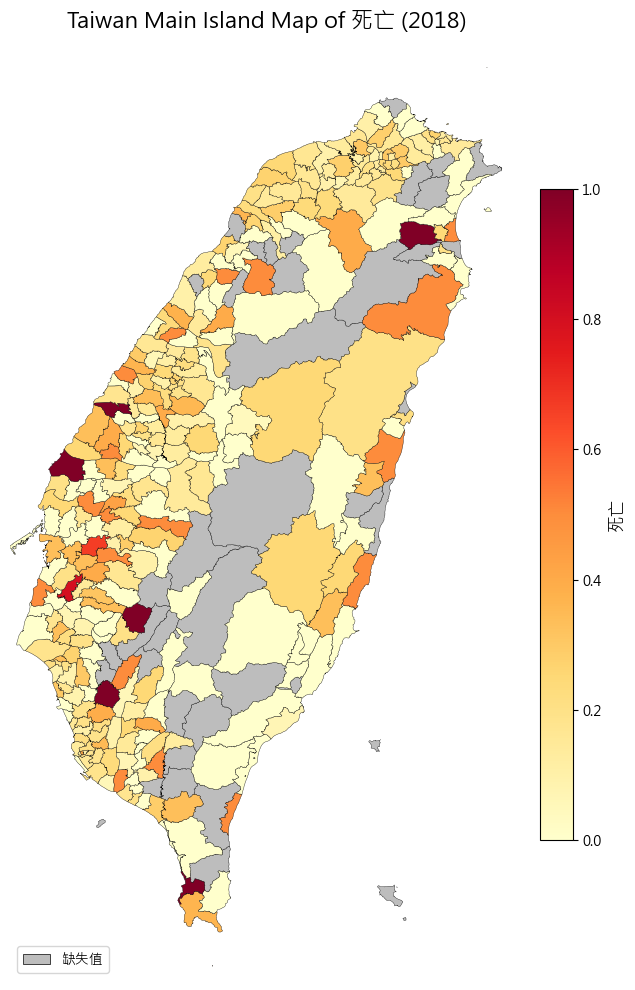

已輸出：
C:/Users/User/Desktop/LC analysis/y_true_map\taiwan_mainland_bbox_y_true_2018.png
C:/Users/User/Desktop/LC analysis/y_true_map\taiwan_mainland_bbox_y_true_2018.pdf


In [13]:
import os
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# =========================================================
# 0) 基本設定
# =========================================================

data_path = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料變換可數型.xlsx"
shp_path  = r"C:/Users/User/Desktop/TOWN_MOI/TOWN_MOI_1140318.shp"

sheet_name = "Sheet1"
value_col = "死亡"
town_col = "鄉鎮"
target_year = 2018  # 若不分年份可改成 None

out_dir = r"C:/Users/User/Desktop/LC analysis/y_true_map"
os.makedirs(out_dir, exist_ok=True)

# 台灣本島大致經緯度範圍（可自行微調）
LON_MIN, LON_MAX = 120.0, 122.1
LAT_MIN, LAT_MAX = 21.7, 25.5

# =========================================================
# 1) 字型設定
# =========================================================
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False

# =========================================================
# 2) 名稱標準化
# =========================================================
def normalize_town_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    x = x.replace("臺", "台")
    x = re.sub(r"\s+", "", x)
    x = x.strip()
    return x

# =========================================================
# 3) 讀取資料
# =========================================================
df = pd.read_excel(data_path, sheet_name=sheet_name)
df.columns = df.columns.astype(str).str.strip()

required_cols = [town_col, value_col]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"資料表缺少必要欄位：{missing_cols}")

if "年份" in df.columns:
    df["年份"] = pd.to_datetime(df["年份"], errors="coerce")
    if target_year is not None:
        df = df[df["年份"].dt.year == target_year].copy()

df["town_key"] = df[town_col].apply(normalize_town_name)

df_map = (
    df.groupby("town_key", as_index=False)
      .agg(
          y_true=(value_col, "mean"),
          n_records=(value_col, "size")
      )
)

# =========================================================
# 4) 讀取 shapefile
# =========================================================
def read_shp_safely(shp_path):
    encodings = ["utf-8", "big5", "cp950"]
    last_error = None
    for enc in encodings:
        try:
            gdf = gpd.read_file(shp_path, encoding=enc)
            print(f"成功讀取 shapefile，encoding = {enc}")
            return gdf
        except Exception as e:
            last_error = e
    raise RuntimeError(f"shapefile 讀取失敗，最後錯誤訊息：{last_error}")

gdf = read_shp_safely(shp_path)

print("原始 CRS：", gdf.crs)

if ("COUNTYNAME" not in gdf.columns) or ("TOWNNAME" not in gdf.columns):
    raise ValueError("shapefile 中找不到 COUNTYNAME 或 TOWNNAME")

# =========================================================
# 5) 先轉成經緯度 EPSG:4326
# =========================================================
gdf = gdf.to_crs(epsg=4326)

print("轉換後 CRS：", gdf.crs)
print("total bounds:", gdf.total_bounds)  
# 依序是 [minx, miny, maxx, maxy] = [min lon, min lat, max lon, max lat]

# =========================================================
# 6) 建立行政區 key
# =========================================================
gdf["county_norm"] = gdf["COUNTYNAME"].apply(normalize_town_name)
gdf["town_norm"] = gdf["TOWNNAME"].apply(normalize_town_name)
gdf["town_key"] = gdf["county_norm"] + gdf["town_norm"]

# =========================================================
# 7) 合併 y_true
# =========================================================
map_gdf = gdf.merge(df_map, on="town_key", how="left")

print("全部行政區數：", len(map_gdf))
print("成功對應 y_true 數：", map_gdf["y_true"].notna().sum())

# =========================================================
# 8) 直接用經緯度框出台灣本島
# =========================================================
bbox = box(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox], crs="EPSG:4326")

# 真正裁切
mainland_gdf = gpd.clip(map_gdf, bbox_gdf)

print("裁切後行政區數：", len(mainland_gdf))
print("裁切後有 y_true 的行政區數：", mainland_gdf["y_true"].notna().sum())

# =========================================================
# 9) 畫圖
# =========================================================

# 固定所有圖片使用相同色域
COLOR_MIN = 0.0
COLOR_MAX = 1.0

# 建立固定的色階標準化方式
color_norm = Normalize(
    vmin=COLOR_MIN,
    vmax=COLOR_MAX,
    clip=True
)

color_map = plt.get_cmap("YlOrRd")

fig, ax = plt.subplots(figsize=(8, 10))

# ---------------------------------------------------------
# 9.1 缺失值行政區
# ---------------------------------------------------------
missing_gdf = mainland_gdf[
    mainland_gdf["y_true"].isna()
].copy()

if not missing_gdf.empty:
    missing_gdf.plot(
        ax=ax,
        color="#BDBDBD",
        edgecolor="black",
        linewidth=0.25
    )

# ---------------------------------------------------------
# 9.2 有觀測值行政區
# ---------------------------------------------------------
valid_gdf = mainland_gdf[
    mainland_gdf["y_true"].notna()
].copy()

if not valid_gdf.empty:
    valid_gdf.plot(
        column="y_true",
        ax=ax,
        cmap=color_map,
        norm=color_norm,
        edgecolor="black",
        linewidth=0.25
    )

# ---------------------------------------------------------
# 9.3 建立固定範圍 0 至 1 的 colorbar
# ---------------------------------------------------------
scalar_mappable = ScalarMappable(
    norm=color_norm,
    cmap=color_map
)
scalar_mappable.set_array([])

colorbar = fig.colorbar(
    scalar_mappable,
    ax=ax,
    shrink=0.70,
    pad=0.02
)

colorbar.set_label(
    "死亡",
    fontsize=12
)

colorbar.set_ticks(
    np.linspace(COLOR_MIN, COLOR_MAX, 6)
)

colorbar.set_ticklabels([
    f"{x:.1f}"
    for x in np.linspace(COLOR_MIN, COLOR_MAX, 6)
])

# ---------------------------------------------------------
# 9.4 缺失值圖例
# ---------------------------------------------------------
missing_legend = Patch(
    facecolor="#BDBDBD",
    edgecolor="black",
    linewidth=0.5,
    label="缺失值"
)

ax.legend(
    handles=[missing_legend],
    loc="lower left",
    frameon=True,
    fontsize=10
)

# ---------------------------------------------------------
# 9.5 地圖範圍與標題
# ---------------------------------------------------------
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_aspect("equal")

title_year = f" ({target_year})" if target_year is not None else ""

ax.set_title(
    f"Taiwan Main Island Map of 死亡{title_year}",
    fontsize=16,
    pad=15
)

ax.set_axis_off()

plt.tight_layout()

# ---------------------------------------------------------
# 9.6 輸出圖片
# ---------------------------------------------------------
year_text = str(target_year) if target_year is not None else "all_years"

png_path = os.path.join(
    out_dir,
    f"taiwan_mainland_bbox_y_true_{year_text}.png"
)

pdf_path = os.path.join(
    out_dir,
    f"taiwan_mainland_bbox_y_true_{year_text}.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

print("已輸出：")
print(png_path)
print(pdf_path)

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# =========================================================
# 0) 讀取資料
# =========================================================
file_path = r"C:/Users/User/Desktop/inflated_normal_local_sigma_results.xlsx"
sheet_name = "row_level"

df = pd.read_excel(file_path, sheet_name=sheet_name)
df.columns = df.columns.astype(str).str.strip()

required_cols = ["鄉鎮", "y_true", "F_mean", "p_mean", "sigma_mean"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"缺少必要欄位：{missing_cols}")

if "年份" in df.columns:
    df["年份"] = pd.to_datetime(df["年份"], errors="coerce")

INFLATED_C = -6.907255070523717

In [17]:
def search_town(keyword):
    out = df[df["鄉鎮"].astype(str).str.contains(keyword, na=False)].copy()
    show_cols = ["年份", "鄉鎮", "y_true", "F_mean", "p_mean", "sigma_mean"]
    show_cols = [c for c in show_cols if c in out.columns]
    return out[show_cols]

In [18]:
def plot_mixture_weight_view(
    town_name,
    year=None,
    x_mode="full",
    save_fig=False,
    out_dir="pdf_plots"
):
    """
    視覺化混合模型：
    - 膨脹柱高度 = p_mean
    - 常態曲線最高點 = 1 - p_mean
    - y 軸固定在 [0, 1]

    這不是嚴格意義下的真實 PDF 高度，
    而是更適合展示 mixture 權重結構的圖。
    """

    temp = df[df["鄉鎮"].astype(str) == town_name].copy()

    if year is not None and "年份" in temp.columns:
        temp = temp[temp["年份"].dt.year == year].copy()

    if len(temp) == 0:
        raise ValueError(f"找不到資料：{town_name}, year={year}")

    if len(temp) > 1:
        print("找到多筆資料，先畫第一筆；若要指定年份請加 year=...")
    
    row = temp.iloc[0]

    y_true = float(row["y_true"])
    F_mean = float(row["F_mean"])
    p_mean = float(row["p_mean"])
    sigma_mean = float(row["sigma_mean"])

    if sigma_mean <= 0:
        raise ValueError(f"{town_name} 的 sigma_mean <= 0，無法畫圖。")

    # -----------------------------------------------------
    # x 範圍
    # -----------------------------------------------------
    if x_mode == "focus":
        x_min = min(F_mean - 4 * sigma_mean, y_true - 1.0 * sigma_mean)
        x_max = max(F_mean + 4 * sigma_mean, y_true + 1.0 * sigma_mean)
    elif x_mode == "full":
        x_min = min(INFLATED_C, F_mean - 4 * sigma_mean, y_true) - 0.5
        x_max = max(INFLATED_C, F_mean + 4 * sigma_mean, y_true) + 0.5
    else:
        raise ValueError("x_mode 只能是 'focus' 或 'full'")

    x = np.linspace(x_min, x_max, 1200)

    # -----------------------------------------------------
    # 常態形狀（只保留形狀），再重新縮放成最高點 = 1 - p_mean
    # -----------------------------------------------------
    base_pdf = norm.pdf(x, loc=F_mean, scale=sigma_mean)
    base_pdf_max = base_pdf.max()

    # 重新縮放後，曲線最高點就是 (1-p_mean)
    scaled_curve = (1 - p_mean) * (base_pdf / base_pdf_max)

    # y_true 在曲線上的高度（方便畫紅線到對應位置）
    y_true_curve_height = (1 - p_mean) * (
        norm.pdf(y_true, loc=F_mean, scale=sigma_mean) / base_pdf_max
    )

    # -----------------------------------------------------
    # 開始畫圖
    # -----------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5.5))

    # 常態部分
    ax.plot(x, scaled_curve, linewidth=2, label="Non-inflated component (scaled)")
    ax.fill_between(x, scaled_curve, alpha=0.20)

    # inflated point 柱
    ax.vlines(
        INFLATED_C,
        ymin=0,
        ymax=p_mean,
        linewidth=6,
        alpha=0.75,
        label=f"Inflated point mass = {p_mean:.4f}"
    )

    # y_true 紅線
    ax.vlines(
        y_true,
        ymin=0,
        ymax=y_true_curve_height,
        color="red",
        linewidth=2.5,
        linestyle="-",
        label=f"y_true = {y_true:.4f}"
    )

    # y_true 的紅點（落在曲線上的哪一點）
    ax.scatter(
        [y_true],
        [y_true_curve_height],
        color="red",
        s=50,
        zorder=5
    )

    # F_mean 線
    ax.axvline(
        F_mean,
        linewidth=2,
        linestyle="--",
        label=f"F_mean = {F_mean:.4f}"
    )

    # inflated point 參考線
    ax.axvline(
        INFLATED_C,
        linewidth=1.5,
        linestyle=":",
        alpha=0.7
    )

    # 文字說明
    ax.text(
        0.02,
        0.95,
        f"p_mean = {p_mean:.4f}\n"
        f"1-p_mean = {1-p_mean:.4f}\n"
        f"F_mean = {F_mean:.4f}\n"
        f"sigma_mean = {sigma_mean:.4f}\n"
        f"y_true = {y_true:.4f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    # -----------------------------------------------------
    # y軸固定 0 到 1
    # -----------------------------------------------------
    ax.set_ylim(0, 1)

    title_year = ""
    if "年份" in row.index and pd.notna(row["年份"]):
        title_year = f"｜{row['年份'].year}"

    ax.set_title(f"Mixture Weight View: {town_name}{title_year}")
    ax.set_xlabel("死亡_cll scale")
    ax.set_ylabel("Scaled mixture height (0 to 1)")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()

    # 儲存
    if save_fig:
        os.makedirs(out_dir, exist_ok=True)
        safe_name = str(town_name).replace("/", "_").replace("\\", "_")
        if year is not None:
            safe_name = f"{safe_name}_{year}"

        png_path = os.path.join(out_dir, f"{safe_name}_mixture_weight_view.png")
        pdf_path = os.path.join(out_dir, f"{safe_name}_mixture_weight_view.pdf")

        plt.savefig(png_path, dpi=300, bbox_inches="tight")
        plt.savefig(pdf_path, bbox_inches="tight")

        print(f"已儲存：{png_path}")
        print(f"已儲存：{pdf_path}")

    plt.show()

    return {
        "鄉鎮": town_name,
        "year": year,
        "y_true": y_true,
        "F_mean": F_mean,
        "p_mean": p_mean,
        "sigma_mean": sigma_mean,
        "y_true_curve_height": y_true_curve_height
    }

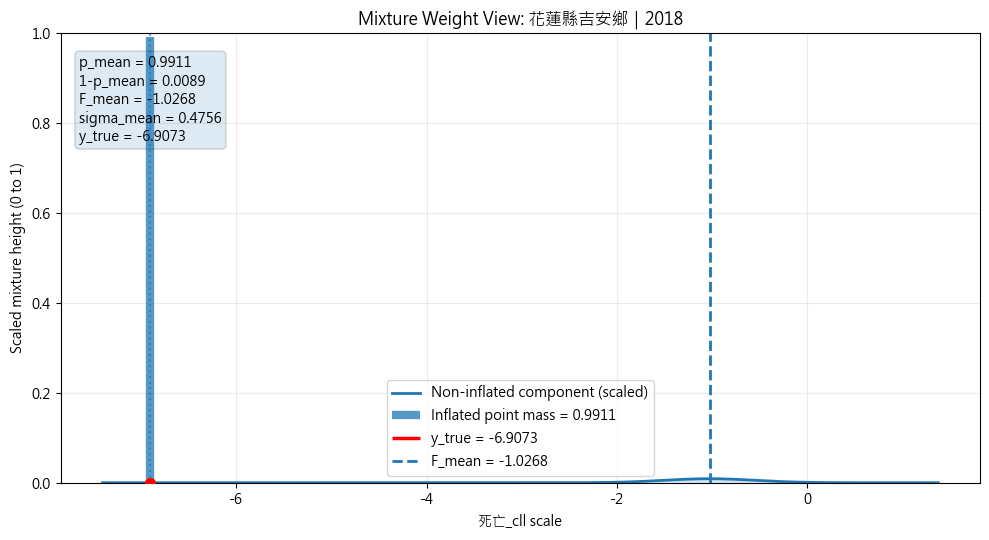

{'鄉鎮': '花蓮縣吉安鄉',
 'year': None,
 'y_true': -6.907255070523717,
 'F_mean': -1.026760101318359,
 'p_mean': 0.9910697340965271,
 'sigma_mean': 0.4755974411964417,
 'y_true_curve_height': np.float64(5.6694585021244154e-36)}

In [58]:
plot_mixture_weight_view(
    town_name="花蓮縣吉安鄉",
    x_mode="full",
    save_fig=False
)